# Data Preparation and Shared Dataset Analysis

## Executive summary

This notebook prepares and validates the shared dataset contract used by all four tasks. It covers
raw hashing, image and metadata matching, duplicate control, the sole split, protected labels,
train-only dataset analysis, shared transforms, normalization, and retrieval data boundaries. EDA is
one section inside this wider data-preparation workflow; this notebook does not train or select the retrieval data boundary. Task notebooks own model training and final metric choices.

**Counting rule.** A *product ID* is one labelled item and one final metric unit. An *image input* is
one resolution file passed through the model. The paired pipeline therefore contains 53,984 training,
11,562 validation, and 11,556 holdout image inputs, representing 26,992, 5,781, and 5,778 unique
products respectively. Target distributions count products once; model loading processes both images.

| Area | Main evidence | Decision for modelling |
|---|---|---|
| Data usability | 38,612 image-backed products; five metadata rows have no usable image | Exclude only objective file failures and keep an audit trail |
| Comparison integrity | 38,551 active product rows become 27,009 family units; 61 quarantine products; zero active family crossings | Use `data/processed/splits.csv`, keep families whole, and report both rows and units |
| Target difficulty | `articleType` has 124 official outputs; 18/100 supported classes have one validation family and 26/100 have fewer than three | Task owners choose class-aware primary and supporting metrics, then report family support and honest uncertainty |
| Image representation | 96x128 matches the common 60x80 aspect ratio with no padding and 25% fewer pixels than 128x128 | Use RGB, aspect-preserving transforms, then prove the choice with a controlled model ablation |
| Resolution variants | 38,551 active products provide 77,102 image inputs across train, validation, and holdout | Use both images in the main pipeline; keep one weighted training unit and one final score per product |
| Visual-search evaluation | Validation queries and a train-only gallery have zero overlap; relevance is only a metadata proxy | Report nDCG@5, grade-2 Recall@5, coverage, latency, and the proxy limit |


## 1. Scope and execution

**Scope.** This notebook prepares the common data contract, then uses focused EDA to check whether it is
safe and useful. It covers provenance, quality, leakage control, targets, images, shared transforms, and
the retrieval data boundary. Task notebooks own model training and final metric choices.

**Lifecycle.** Provenance and contracts → data quality and leakage controls → target distributions →
target relationships and risk → image features and preprocessing → evaluation design → modelling
recommendations and reproducibility.

**Execution.** Start a fresh kernel and choose **Run All** once. The notebook validates the local raw
files, reuses the delivered protected-safe cache, recreates every preparation figure and evidence table, and
writes the code-free report to `results/notebooks/01_data_preparation.html`.

**Reading pattern.** Each analysis block introduces its purpose, presents focused evidence, explains
the finding, and states the modelling consequence. Code remains in the notebook for auditability but
is collapsed by default.

**Code step — Runtime configuration.**

Imports the required packages and fixes project paths, seeds, image sizes, cache mode, and required raw files. It prepares shared settings but does not analyse labels.

In [1]:
from __future__ import annotations

import base64
import hashlib
import html
import json
import os
import platform
import subprocess
import sys
import time
from pathlib import Path
from statistics import median
from typing import Any

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from PIL import Image, ImageOps

from fashion.config import ROOT as CONFIGURED_PROJECT_ROOT
from fashion.config import TARGET_COLUMNS
from fashion.data.dataset import load_label_maps, load_splits
from fashion.data.hashing import compute_sha256
from fashion.data.images import resolve_image_size, transform_image
from fashion.data.splits import validate_splits
from fashion.data.statistics import train_ids_digest
from fashion.retrieval.protocol import (
    build_development_retrieval_sets,
    build_development_retrieval_variant_sets,
)

PROJECT_ROOT = Path(CONFIGURED_PROJECT_ROOT).resolve()
PROCESSED = PROJECT_ROOT / "data/processed"
AUDIT = PROCESSED / "audit"
EVIDENCE = PROJECT_ROOT / "results/evidence/data_preparation"
FIGURES = PROJECT_ROOT / "results/figures/data_preparation"
REPORTS = PROJECT_ROOT / "results/notebooks"
NOTEBOOK_PATH = Path(
    os.environ.get(
        "FASHION_DATA_PREPARATION_NOTEBOOK_PATH",
        PROJECT_ROOT / "notebooks/01_data_preparation.ipynb",
    )
).resolve()

SEED = 2753
IMAGE_SIZE = (128, 96)  # height, width: rendered as 96 x 128
LEGACY_IMAGE_SIZE = (128, 128)
WORKERS_TEXT = os.environ.get("FASHION_DATA_PREPARATION_WORKERS", "").strip()
WORKERS = int(WORKERS_TEXT) if WORKERS_TEXT else None
BENCHMARK_SAMPLE_SIZE = int(os.environ.get("FASHION_DATA_PREPARATION_BENCHMARK_SIZE", "512"))
BENCHMARK_REPETITIONS = int(os.environ.get("FASHION_DATA_PREPARATION_BENCHMARK_REPETITIONS", "3"))
QUALITY_SAMPLE_SIZE = int(os.environ.get("FASHION_DATA_PREPARATION_QUALITY_SAMPLE_SIZE", "2048"))

RAW_TRAIN_CSV = PROJECT_ROOT / "data/raw/teacher/train/styles_train.csv"
RAW_PREDICTION_CSV = PROJECT_ROOT / "data/raw/teacher/test/styles_prediction.csv"
SPLITS_PATH = PROCESSED / "splits.csv"
PREDICTION_MANIFEST_PATH = PROCESSED / "prediction_manifest.csv"
ISSUES_PATH = AUDIT / "issues.csv"
FAMILY_SUMMARY_PATH = AUDIT / "product_family_summary.json"
HIGH_RES_AUDIT = PROCESSED / "high_resolution"
HIGH_RES_CATALOGUE_PATH = HIGH_RES_AUDIT / "image_catalogue.csv.gz"
HIGH_RES_SUMMARY_PATH = HIGH_RES_AUDIT / "catalogue.json"
ALIGNMENT_PAIRS_PATH = HIGH_RES_AUDIT / "all_alignment_pairs.csv.gz"
ALIGNMENT_SUMMARY_PATH = HIGH_RES_AUDIT / "alignment_summary.json"
VARIANT_MANIFEST_PATH = PROCESSED / "training_image_variants.csv.gz"
VARIANT_SUMMARY_PATH = PROCESSED / "training_image_variants_summary.json"
TAXONOMY_PATH = PROCESSED / "taxonomy.json"
PAIRED_NORMALIZATION_PATH = PROCESSED / "paired_normalization.json"
ORIGINAL_ONLY_NORMALIZATION_PATH = PROCESSED / "normalization_original_only.json"
MODE_TEXT = os.environ.get("FASHION_DATA_PREPARATION_MODE", "").strip().lower()
LEGACY_REBUILD = os.environ.get("FASHION_DATA_PREPARATION_REBUILD")
if MODE_TEXT:
    PREPARATION_MODE = MODE_TEXT
elif LEGACY_REBUILD is not None:
    PREPARATION_MODE = "full" if LEGACY_REBUILD.strip() != "0" else "cached"
else:
    PREPARATION_MODE = "cached"
if PREPARATION_MODE not in {"cached", "full"}:
    raise ValueError("FASHION_DATA_PREPARATION_MODE must be 'cached' or 'full'")

for folder in (EVIDENCE, FIGURES, REPORTS):
    folder.mkdir(parents=True, exist_ok=True)
for required in (RAW_TRAIN_CSV, RAW_PREDICTION_CSV):
    if not required.is_file():
        raise FileNotFoundError(f"Required teacher file is missing: {required}")

**Code step — Display defaults.**

Sets deterministic plotting defaults and notebook table styles. It changes presentation only and does not change the data.

In [2]:
np.random.seed(SEED)
pd.set_option("display.max_colwidth", 100)
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#FAFAF8",
        "axes.edgecolor": "#B8B8B8",
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": "#E2E2DE",
        "grid.linestyle": "--",
        "grid.alpha": 0.75,
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 12,
        "figure.titlesize": 14,
    }
)
PALETTE = ("#245B78", "#D97732", "#4C956C", "#8C6BB1", "#C44E52", "#6B7280")

display(
    HTML(
        """
        <style>
        .jp-OutputArea-output, .output_area {max-width: 100%; overflow-x: auto;}
        .jp-OutputArea-output table, .output_area table {
          width: 100% !important; table-layout: auto; font-size: 12px;
        }
        .jp-OutputArea-output th, .jp-OutputArea-output td,
        .output_area th, .output_area td {
          white-space: normal !important;
          overflow-wrap: break-word;
          word-break: normal;
          vertical-align: top;
        }
        figure.data-preparation-figure {margin: 0.8rem auto 1.5rem; max-width: 100%;}
        figure.data-preparation-figure img {display: block; width: 100%; height: auto; margin: auto;}
        figure.data-preparation-figure figcaption {color: #374151; font-size: 0.92rem; margin-top: 0.45rem;}
        .jp-OutputArea-output th.row_heading,
        .output_area th.row_heading {
          white-space: nowrap !important;
          overflow-wrap: normal !important;
          min-width: 2rem;
        }
        @media print {
          .jp-OutputArea-output, .output_area {overflow: visible !important;}
        }
        </style>
        """
    )
)

### Implementation setup

The collapsed setup cells contain imports, configuration, display functions, and plotting functions.
They remain available for audit without interrupting the report narrative.

**Code step — Shared output helpers.**

Defines the small functions used to save tables, hash evidence, render figures, and open images safely. Later analysis cells call these functions so the saving rules stay consistent.

In [3]:
# Shared table, file, and display helpers


def bool_mask(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    return series.astype(str).str.strip().str.lower().isin({"true", "1", "yes"})


def atomic_write_text(path: Path, payload: str, *, attempts: int = 6) -> Path:
    temporary = path.with_name(f".{path.name}.{os.getpid()}.tmp")
    try:
        for attempt in range(attempts):
            try:
                temporary.write_text(payload, encoding="utf-8", newline="\n")
                temporary.replace(path)
                return path
            except OSError:
                if attempt + 1 == attempts:
                    raise
                time.sleep(0.05 * (2**attempt))
    finally:
        temporary.unlink(missing_ok=True)


def save_csv(frame: pd.DataFrame, name: str) -> Path:
    path = EVIDENCE / name
    payload = frame.to_csv(index=False, lineterminator="\n", float_format="%.8f")
    return atomic_write_text(path, payload)


def save_json(record: dict[str, Any], name: str) -> Path:
    path = EVIDENCE / name
    payload = json.dumps(record, indent=2, sort_keys=True) + "\n"
    return atomic_write_text(path, payload)


def show_table(frame: pd.DataFrame, caption: str) -> None:
    styled = (
        frame.style.format(precision=3, thousands=",")
        .set_caption(caption)
        .set_table_styles(
            [
                {"selector": "caption", "props": "font-weight:600;text-align:left;"},
                {"selector": "th", "props": "background:#E8EEF2;text-align:left;"},
                {"selector": "td", "props": "text-align:left;vertical-align:top;"},
            ]
        )
    )
    styled.set_uuid("data_prep_" + hashlib.sha256(caption.encode()).hexdigest()[:10])
    display(styled)


def save_figure(fig: plt.Figure, name: str) -> Path:
    path = FIGURES / name
    fig.savefig(
        path,
        dpi=220,
        bbox_inches="tight",
        facecolor="white",
        metadata={"Software": "Fashion Intelligence Data Preparation"},
    )
    plt.close(fig)
    return path


def show_figure(path: Path, description: str) -> None:
    encoded = base64.b64encode(path.read_bytes()).decode("ascii")
    safe = html.escape(description, quote=True)
    display(
        HTML(
            f'<figure class="data-preparation-figure"><img src="data:image/png;base64,{encoded}" '
            f'alt="{safe}"><figcaption>{safe}</figcaption></figure>'
        )
    )


def open_rgb(relative_path: str) -> Image.Image:
    with Image.open(PROJECT_ROOT / relative_path) as source:
        return ImageOps.exif_transpose(source).convert("RGB").copy()


def show_image(axis: plt.Axes, image: Image.Image | np.ndarray, title: str) -> None:
    axis.imshow(image)
    axis.set_title(title, fontsize=9)
    axis.set_xticks([])
    axis.set_yticks([])


def file_record(path: Path) -> dict[str, Any]:
    path = path.resolve()
    try:
        shown_path = path.relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        shown_path = path.as_posix()
    return {
        "path": shown_path,
        "size_bytes": path.stat().st_size,
        "sha256": compute_sha256(path),
    }


def dataframe_digest(frame: pd.DataFrame, columns: list[str]) -> str:
    payload = frame[columns].fillna("").astype(str).to_csv(index=False, lineterminator="\n")
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def stable_artifact_digest(path: Path) -> str:
    if path.suffix != ".json":
        return compute_sha256(path)
    value = json.loads(path.read_text(encoding="utf-8"))

    def strip_volatile(item: Any) -> Any:
        if isinstance(item, dict):
            return {
                key: strip_volatile(child)
                for key, child in item.items()
                if key != "runtime_seconds"
            }
        if isinstance(item, list):
            return [strip_volatile(child) for child in item]
        return item

    payload = json.dumps(strip_volatile(value), sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def notebook_code_digest(path: Path) -> str:
    notebook = json.loads(path.read_text(encoding="utf-8"))
    cells = [
        {"cell_type": cell["cell_type"], "source": cell.get("source", [])}
        for cell in notebook["cells"]
    ]
    payload = json.dumps(cells, ensure_ascii=False, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()

## 2. Data provenance and inventory

Reliable data preparation begins with traceable inputs and a repeatable loading contract. This stage validates
the prepared artefacts before any label distribution or image statistic is interpreted.

### 2.1 Prepared-data contract

The fast execution path checks every image name and size, hashes a fixed image sample, and fully
hashes the lean prepared pack. Set `FASHION_DATA_PREPARATION_MODE=full` only after raw inputs change; that mode
performs the slow forensic rebuild in a separate process.

**Code step — Prepared-data validation.**

Runs the fast cache validation by default, checks every required prepared artefact, records the runtime, and displays the result. Full rebuild mode remains an explicit maintenance option.

In [4]:
started = time.perf_counter()
preparation_environment = os.environ.copy()
preparation_environment["FASHION_PROJECT_ROOT"] = str(PROJECT_ROOT)
if PREPARATION_MODE == "full":
    preparation_code = (
        "from fashion.data.pipeline import prepare_data; "
        f"prepare_data(workers={WORKERS!r}, include_high_resolution_variants=True)"
    )
else:
    preparation_code = (
        "import json; "
        "from fashion.data.pipeline import validate_prepared_data_cache; "
        "print(json.dumps(validate_prepared_data_cache("
        "include_high_resolution_variants=True), sort_keys=True))"
    )
preparation = subprocess.run(
    [sys.executable, "-c", preparation_code],
    cwd=PROJECT_ROOT,
    env=preparation_environment,
    check=False,
    capture_output=True,
    text=True,
)
if preparation.returncode:
    detail = preparation.stderr.strip() or preparation.stdout.strip() or "no diagnostic text"
    raise RuntimeError(
        f"Prepared-data {PREPARATION_MODE} mode failed (exit {preparation.returncode}):\n{detail}"
    )
if preparation.stderr.strip():
    raise RuntimeError(
        f"Prepared-data {PREPARATION_MODE} mode emitted a warning:\n" + preparation.stderr
    )
if PREPARATION_MODE == "cached":
    cache_validation = json.loads(preparation.stdout.strip().splitlines()[-1])
else:
    cache_validation = {"status": "full forensic rebuild completed"}
preparation_seconds = time.perf_counter() - started

required_processed = [
    SPLITS_PATH,
    PREDICTION_MANIFEST_PATH,
    PROCESSED / "label_maps.json",
    TAXONOMY_PATH,
    PAIRED_NORMALIZATION_PATH,
    ORIGINAL_ONLY_NORMALIZATION_PATH,
    AUDIT / "image_audit.csv.gz",
    ISSUES_PATH,
    AUDIT / "near_duplicate_candidates.csv.gz",
    FAMILY_SUMMARY_PATH,
    HIGH_RES_CATALOGUE_PATH,
    HIGH_RES_SUMMARY_PATH,
    ALIGNMENT_PAIRS_PATH,
    ALIGNMENT_SUMMARY_PATH,
    VARIANT_MANIFEST_PATH,
    VARIANT_SUMMARY_PATH,
    PROCESSED / "preparation_cache.json",
]
missing = [path for path in required_processed if not path.is_file()]
if missing:
    raise FileNotFoundError(f"The canonical rebuild missed files: {missing}")
display(
    HTML(
        f"<p><strong>Prepared-data {PREPARATION_MODE} mode complete.</strong> "
        f"Checked {len(required_processed)} required files in "
        f"{preparation_seconds:.1f} seconds. Validation or rebuilding ran outside "
        "the data-preparation kernel, so "
        "protected target values were not materialised in notebook state. "
        "Human decisions are not preparation inputs.</p>"
    )
)

> **Finding.** Cached mode validates all 17 direct prepared inputs and keeps protected target
> values outside the notebook process. Human decisions cannot stop preparation, tests, or Run All.
>
> **Modelling consequence.** The prepared pack is the reproducible fast path. A full rebuild is a
> maintenance action after data changes, not part of routine report execution.

### 2.2 Dataset inventory

The inventory separates metadata rows, unique product IDs, and image files before reporting any
model-input count. Raw teacher CSVs are opened only for their header and `id` column. All target analysis comes from the
protected loader and therefore sees train and validation labels only.

**Code step — Source loading and raw inventory.**

Loads only the permitted structural fields, checks the fixed prediction schema, and builds the raw row and image inventory. Teacher target columns are not loaded here.

In [5]:
raw_train_header = pd.read_csv(RAW_TRAIN_CSV, nrows=0, keep_default_na=False)
raw_train_ids = pd.read_csv(RAW_TRAIN_CSV, usecols=["id"], keep_default_na=False)
raw_prediction_header = pd.read_csv(RAW_PREDICTION_CSV, nrows=0, keep_default_na=False)
raw_prediction_ids = pd.read_csv(RAW_PREDICTION_CSV, usecols=["id"], keep_default_na=False)
prediction_manifest = pd.read_csv(PREDICTION_MANIFEST_PATH, keep_default_na=False)
image_audit = pd.read_csv(AUDIT / "image_audit.csv.gz", keep_default_na=False)
issues = pd.read_csv(ISSUES_PATH, usecols=["issue_code"], keep_default_na=False)
issues = issues[issues["issue_code"].isin({"missing_image", "corrupt_image"})].copy()
splits = load_splits(SPLITS_PATH)
variant_manifest = pd.read_csv(VARIANT_MANIFEST_PATH, keep_default_na=False)
variant_proof = json.loads(VARIANT_SUMMARY_PATH.read_text(encoding="utf-8"))
highres_catalogue_summary = json.loads(HIGH_RES_SUMMARY_PATH.read_text(encoding="utf-8"))
alignment_pairs = pd.read_csv(ALIGNMENT_PAIRS_PATH, keep_default_na=False)
alignment_proof = json.loads(ALIGNMENT_SUMMARY_PATH.read_text(encoding="utf-8"))

fixed_prediction_schema = ["id", "gender", "articleType", "season", "usage"]
if list(raw_prediction_header.columns) != fixed_prediction_schema:
    raise ValueError("The official prediction CSV schema changed")
if raw_train_ids["id"].duplicated().any() or raw_prediction_ids["id"].duplicated().any():
    raise ValueError("Raw structural inventory contains duplicate IDs")
if set(TARGET_COLUMNS).intersection(prediction_manifest.columns):
    raise ValueError("Prediction targets leaked into the prediction manifest")

candidate_images = image_audit[image_audit["error"].ne("non_image_extension")]
raw_inventory = pd.DataFrame(
    [
        {
            "source": "teacher training metadata",
            "rows": len(raw_train_ids),
            "unique_ids": raw_train_ids["id"].nunique(),
            "columns": len(raw_train_header.columns),
            "read_scope": "header and ID only; target columns never loaded",
        },
        {
            "source": "official prediction metadata",
            "rows": len(raw_prediction_ids),
            "unique_ids": raw_prediction_ids["id"].nunique(),
            "columns": len(raw_prediction_header.columns),
            "read_scope": "fixed header and ID only; never labelled data",
        },
        {
            "source": "candidate training image files",
            "rows": int(candidate_images["role"].eq("train").sum()),
            "unique_ids": int(
                candidate_images.loc[candidate_images["role"].eq("train"), "id"].nunique()
            ),
            "columns": "n/a",
            "read_scope": "label-free structural image audit",
        },
        {
            "source": "candidate prediction image files",
            "rows": int(candidate_images["role"].eq("prediction").sum()),
            "unique_ids": int(
                candidate_images.loc[candidate_images["role"].eq("prediction"), "id"].nunique()
            ),
            "columns": "n/a",
            "read_scope": "label-free duplicate audit only",
        },
    ]
)

**Code step — Processed contract inventory.**

Hashes the protected-safe processed artefacts, saves the complete inventory, and displays the four files later modelling code must use.

In [6]:
safe_records = [
    {
        "file": "data/processed/prediction_manifest.csv",
        "rows": len(prediction_manifest),
        "digest_scope": "label-free prediction manifest",
        "sha256": dataframe_digest(
            prediction_manifest.sort_values("id"), list(prediction_manifest.columns)
        ),
    },
    {
        "file": "data/processed/splits.csv",
        "rows": len(splits),
        "digest_scope": "normal loader; protected targets redacted",
        "sha256": dataframe_digest(splits.sort_values("id"), list(splits.columns)),
    },
    {
        "file": "data/processed/high_resolution/image_catalogue.csv.gz",
        "rows": int(highres_catalogue_summary["images"]["file_count"]),
        "digest_scope": "image-only catalogue",
        "sha256": compute_sha256(HIGH_RES_CATALOGUE_PATH),
    },
    {
        "file": "data/processed/training_image_variants.csv.gz",
        "rows": len(variant_manifest),
        "digest_scope": "target-free product/variant manifest",
        "sha256": compute_sha256(VARIANT_MANIFEST_PATH),
    },
]
for path, scope in (
    (PROCESSED / "label_maps.json", "train-fitted label map"),
    (TAXONOMY_PATH, "train-fitted deployment and metric taxonomy"),
    (PAIRED_NORMALIZATION_PATH, "main doubled-policy train statistics"),
    (ORIGINAL_ONLY_NORMALIZATION_PATH, "original-only comparison baseline"),
    (AUDIT / "image_audit.csv.gz", "label-free image audit and image-path source"),
    (ISSUES_PATH, "objective missing/corrupt image counts"),
    (AUDIT / "near_duplicate_candidates.csv.gz", "automatic visual evidence"),
    (FAMILY_SUMMARY_PATH, "product-family policy summary"),
    (HIGH_RES_SUMMARY_PATH, "high-resolution catalogue summary"),
    (VARIANT_SUMMARY_PATH, "target-free paired-variant proof"),
    (ALIGNMENT_PAIRS_PATH, "label-free all-pair resolution alignment audit"),
    (ALIGNMENT_SUMMARY_PATH, "compact label-free alignment summary"),
    (
        PROCESSED / "preparation_cache.json",
        "cheap source inventory and critical-artifact fingerprints",
    ),
):
    safe_records.append(
        {
            "file": path.relative_to(PROJECT_ROOT).as_posix(),
            "rows": "n/a",
            "digest_scope": scope,
            "sha256": stable_artifact_digest(path),
        }
    )
processed_inventory = pd.DataFrame(safe_records).drop_duplicates("file").sort_values("file")
save_csv(raw_inventory, "raw_inventory.csv")
save_csv(processed_inventory, "processed_inventory.csv")
show_table(raw_inventory, "Raw inventory and permitted read scope")
reader_contract_files = {
    "data/processed/splits.csv",
    "data/processed/training_image_variants.csv.gz",
    "data/processed/taxonomy.json",
    "data/processed/preparation_cache.json",
}
reader_contract = processed_inventory.loc[
    processed_inventory["file"].isin(reader_contract_files),
    ["file", "rows", "digest_scope"],
].copy()
show_table(reader_contract, "Four files that define the modelling contract")

,source,rows,unique_ids,columns,read_scope
0,teacher training metadata,"38,617","38,617",12,header and ID only; target columns never loaded
1,official prediction metadata,"5,829","5,829",5,fixed header and ID only; never labelled data
2,candidate training image files,"38,612","38,612",n/a,label-free structural image audit
3,candidate prediction image files,"5,829","5,829",n/a,label-free duplicate audit only


,file,rows,digest_scope
16,data/processed/preparation_cache.json,n/a,cheap source inventory and critical-artifact fingerprints
1,data/processed/splits.csv,"38,612",normal loader; protected targets redacted
5,data/processed/taxonomy.json,n/a,train-fitted deployment and metric taxonomy
3,data/processed/training_image_variants.csv.gz,"77,102",target-free product/variant manifest


> **Finding.** The teacher metadata contains 38,617 labelled product IDs, and 38,612 have a
> usable original-resolution image. The five missing products cannot enter the paired model dataset. The 5,829 official
> prediction IDs remain label-free and separate. The displayed four-file contract is the portion a
> later model consumes; the full technical inventory is saved as evidence.
>
> **Modelling consequence.** Training uses only image-backed IDs from the shared split. The official
> prediction set stays outside target analysis, validation, normalization, and retrieval tuning.

### 2.3 Raw hashing and metadata-image reconciliation

Hashing is not a late provenance step. In a full rebuild, the pipeline reads the raw file bytes and
computes SHA-256 before it trusts image content, builds duplicate families, or creates the shared
split. Decode validation follows the byte hash. Perceptual dHash and aHash are computed only for
decodable images because they describe visual content rather than file identity.

The three hash roles stay separate:

1. **Raw SHA-256** identifies exact file-byte matches and supports CSV-to-image reconciliation.
2. **Perceptual hashes** find visually close decoded images for duplicate review and family grouping.
3. **Artifact SHA-256** fingerprints generated manifests, evidence, and notebook provenance at the
   end of the workflow.

This section exposes the first role and proves that metadata IDs and decoded image IDs agree before
the split or any training-only statistic is interpreted.

**Code step — Raw hash coverage and ID reconciliation.**

Summarises SHA-256 coverage, exact-byte duplicate groups, and metadata-to-image matches for the labelled and official prediction roles. It also records the real pipeline stage order.

In [7]:
# Raw byte hashing is the first content identity check in fashion.data.pipeline.prepare_data.
pipeline_stage_order = pd.DataFrame(
    [
        {"order": 1, "stage": "Raw inventory and SHA-256", "boundary": "all candidate files"},
        {"order": 2, "stage": "Decode and structural validation", "boundary": "image bytes only"},
        {"order": 3, "stage": "Metadata-image reconciliation", "boundary": "IDs and paths"},
        {"order": 4, "stage": "Perceptual dHash and aHash", "boundary": "decodable images only"},
        {"order": 5, "stage": "Duplicate families and quarantine", "boundary": "before splitting"},
        {"order": 6, "stage": "Canonical family-safe split", "boundary": "product IDs"},
        {"order": 7, "stage": "Train-only statistics", "boundary": "train partition only"},
        {"order": 8, "stage": "Variants, cache, and provenance", "boundary": "frozen contracts"},
    ]
)

hashed_images = candidate_images[
    candidate_images["sha256"].astype(str).str.fullmatch(r"[0-9a-f]{64}")
].copy()
decoded_images = candidate_images[bool_mask(candidate_images["decode_ok"])].copy()
if len(hashed_images) != len(decoded_images):
    raise ValueError("Every decodable raw image must have one SHA-256 fingerprint")

hash_counts = hashed_images.groupby(["role", "sha256"], sort=True).size()
cross_role_hashes = (
    hashed_images.groupby("sha256", sort=True)["role"].nunique().gt(1)
)
hashing_rows = []
for role in ("train", "prediction"):
    role_candidates = candidate_images[candidate_images["role"].eq(role)]
    role_decoded = decoded_images[decoded_images["role"].eq(role)]
    role_counts = hash_counts.loc[role] if role in hash_counts.index.get_level_values(0) else pd.Series(dtype=int)
    hashing_rows.append(
        {
            "role": role,
            "candidate_files": len(role_candidates),
            "decoded_files": len(role_decoded),
            "raw_sha256_values": role_decoded["sha256"].nunique(),
            "exact_duplicate_groups": int(role_counts.gt(1).sum()),
            "files_in_exact_duplicate_groups": int(role_counts[role_counts.gt(1)].sum()),
            "cross_role_exact_hash_groups_global": int(cross_role_hashes.sum()),
        }
    )
raw_hashing_summary = pd.DataFrame(hashing_rows)

reconciliation_rows = []
for role, metadata in (("train", raw_train_ids), ("prediction", raw_prediction_ids)):
    metadata_ids = set(pd.to_numeric(metadata["id"], errors="raise").astype(int))
    role_images = candidate_images[candidate_images["role"].eq(role)].copy()
    role_images["numeric_id"] = pd.to_numeric(role_images["id"], errors="coerce").astype("Int64")
    candidate_ids = set(role_images["numeric_id"].dropna().astype(int))
    decoded_ids = set(
        role_images.loc[bool_mask(role_images["decode_ok"]), "numeric_id"].dropna().astype(int)
    )
    missing_ids = sorted(metadata_ids - decoded_ids)
    extra_ids = sorted(decoded_ids - metadata_ids)
    repeated_image_ids = int(role_images["numeric_id"].dropna().duplicated().sum())
    reconciliation_rows.append(
        {
            "role": role,
            "metadata_ids": len(metadata_ids),
            "candidate_image_ids": len(candidate_ids),
            "decoded_image_ids": len(decoded_ids),
            "metadata_without_decoded_image": len(missing_ids),
            "decoded_image_without_metadata": len(extra_ids),
            "repeated_image_ids": repeated_image_ids,
            "missing_id_sample": "; ".join(map(str, missing_ids[:10])) or "None",
            "extra_id_sample": "; ".join(map(str, extra_ids[:10])) or "None",
        }
    )
image_reconciliation = pd.DataFrame(reconciliation_rows)
if image_reconciliation["decoded_image_without_metadata"].sum():
    raise ValueError("A decoded raw image has no matching metadata ID")
if image_reconciliation["repeated_image_ids"].sum():
    raise ValueError("A raw role contains more than one candidate image for an ID")

save_csv(pipeline_stage_order, "preparation_stage_order.csv")
save_csv(raw_hashing_summary, "raw_hashing_summary.csv")
save_csv(image_reconciliation, "image_reconciliation.csv")
show_table(pipeline_stage_order, "Full preparation order: hashing is first")
show_table(raw_hashing_summary, "Raw SHA-256 coverage and exact-byte duplicate evidence")
show_table(image_reconciliation, "Metadata IDs matched to decoded image IDs")

,order,stage,boundary
0,1,Raw inventory and SHA-256,all candidate files
1,2,Decode and structural validation,image bytes only
2,3,Metadata-image reconciliation,IDs and paths
3,4,Perceptual dHash and aHash,decodable images only
4,5,Duplicate families and quarantine,before splitting
5,6,Canonical family-safe split,product IDs
6,7,Train-only statistics,train partition only
7,8,"Variants, cache, and provenance",frozen contracts


,role,candidate_files,decoded_files,raw_sha256_values,exact_duplicate_groups,files_in_exact_duplicate_groups,cross_role_exact_hash_groups_global
0,train,"38,612","38,612","37,849",636,"1,399",11
1,prediction,"5,829","5,829","5,824",5,10,11


,role,metadata_ids,candidate_image_ids,decoded_image_ids,metadata_without_decoded_image,decoded_image_without_metadata,repeated_image_ids,missing_id_sample,extra_id_sample
0,train,"38,617","38,612","38,612",5,0,0,12347; 39401; 39403; 39410; 39425,None
1,prediction,"5,829","5,829","5,829",0,0,0,None,None


> **Finding.** Every decodable raw image has a 64-character SHA-256 value before visual
> duplicate analysis begins. The labelled metadata has five IDs without a usable decoded image;
> the official prediction metadata and image IDs match completely. No decoded image ID exists
> outside its matching metadata role. Exact-byte duplicates are retained as audit evidence and
> handled as product-family constraints before the canonical split.
>
> **Modelling consequence.** Missing or corrupt files are excluded by an objective file rule, not by
> label or model performance. Later notebooks read the reconciled manifest and the single shared
> split; they do not rediscover files, create another split, or treat perceptual similarity as an
> exact-byte hash.

## 3. Data integrity and leakage controls

Leakage controls are fixed before descriptive analysis. Product IDs define the split, while the
paired manifest expands every active product into two model inputs. This prevents evaluation
information, duplicate products, or repeated image variants from inflating later comparisons.

### 3.1 Split integrity

This check validates the canonical partitions, proves that protected targets remain blank, and
confirms that normalization statistics use training products only.

**Code step — Split and normalization checks.**

Validates the canonical product split, proves that protected labels remain blank, and derives the actual paired image-input counts. It also confirms that normalization uses the exact training products.

In [8]:
validate_splits(splits)
protected = splits["partition"].isin({"holdout", "quarantine"})
for target in TARGET_COLUMNS:
    for column in (target, f"{target}_deployed", f"{target}_supported"):
        if column in splits and not splits.loc[protected, column].eq("").all():
            raise ValueError(f"Protected values are visible in {column}")
    for column in (
        f"has_{target}_label",
        f"has_{target}_deployed_label",
        f"has_{target}_supported_label",
    ):
        if column in splits and bool_mask(splits.loc[protected, column]).any():
            raise ValueError(f"Protected validity flags are open in {column}")

train = splits[splits["partition"].eq("train")].copy().sort_values("id")
validation = splits[splits["partition"].eq("val")].copy().sort_values("id")
if train.empty or validation.empty:
    raise ValueError("The canonical split needs train and validation products")
if set(splits["id"].astype(int)) & set(prediction_manifest["id"].astype(int)):
    raise ValueError("Official prediction IDs entered labelled partitions")

train_ids = train["id"].astype(int).tolist()
paired_normalization = json.loads(PAIRED_NORMALIZATION_PATH.read_text(encoding="utf-8"))
original_only_normalization = json.loads(
    ORIGINAL_ONLY_NORMALIZATION_PATH.read_text(encoding="utf-8")
)
if paired_normalization.get("policy") != "pair_weighted_original_and_high_resolution":
    raise ValueError("The main normalization does not use the doubled policy")
if paired_normalization.get("source_partition") != "train":
    raise ValueError("Paired normalization is not training-only")
if paired_normalization.get("product_count") != len(train_ids):
    raise ValueError("Paired normalization product count is stale")
if paired_normalization.get("variant_count") != 2 * len(train_ids):
    raise ValueError("Paired normalization does not cover two inputs per train product")
if paired_normalization.get("train_ids_digest") != train_ids_digest(train_ids):
    raise ValueError("Paired normalization training-ID digest is stale")
if paired_normalization.get("variant_manifest_sha256") != compute_sha256(VARIANT_MANIFEST_PATH):
    raise ValueError("Paired normalization was fitted from a different variant manifest")
if original_only_normalization.get("policy") != "original_resolution_only_baseline":
    raise ValueError("The low-resolution statistic is not labelled as a baseline")
if original_only_normalization.get("num_images") != len(train_ids):
    raise ValueError("Original-only normalization image-input count is stale")
if original_only_normalization.get("train_ids_digest") != train_ids_digest(train_ids):
    raise ValueError("Original-only normalization training-ID digest is stale")

normalization_summary = pd.DataFrame(
    [
        {
            "policy": "main paired",
            "source_partition": "train",
            "product_ids": paired_normalization["product_count"],
            "image_inputs": paired_normalization["variant_count"],
            "mean_rgb": " / ".join(f"{value:.6f}" for value in paired_normalization["mean"]),
            "std_rgb": " / ".join(f"{value:.6f}" for value in paired_normalization["std"]),
            "weighting": "two images; pair weights sum to one",
        },
        {
            "policy": "original-only baseline",
            "source_partition": "train",
            "product_ids": original_only_normalization["num_images"],
            "image_inputs": original_only_normalization["num_images"],
            "mean_rgb": " / ".join(f"{value:.6f}" for value in original_only_normalization["mean"]),
            "std_rgb": " / ".join(f"{value:.6f}" for value in original_only_normalization["std"]),
            "weighting": "one image per product",
        },
    ]
)
save_csv(normalization_summary, "normalization_summary.csv")

partition_counts = splits["partition"].value_counts()
partition_rules = {
    "train": ("targets available", "two image samples; pair weights sum to one"),
    "val": ("development only", "two forward passes; one product-level score"),
    "holdout": ("sealed", "two forward passes; one product-level score"),
    "quarantine": ("sealed", "excluded from model input"),
}
partition_records = []
for partition in ("train", "val", "holdout", "quarantine"):
    product_ids = int(partition_counts.get(partition, 0))
    variant_rows = variant_manifest[variant_manifest["partition"].eq(partition)]
    image_inputs = len(variant_rows)
    if partition != "quarantine":
        if variant_rows["id"].nunique() != product_ids or image_inputs != 2 * product_ids:
            raise ValueError(f"Paired input count is inconsistent for {partition}")
        pairs = variant_rows.groupby("id")["variant"].agg(set)
        if not pairs.eq({"original", "high_resolution"}).all():
            raise ValueError(f"A {partition} product is missing an image input")
    elif image_inputs:
        raise ValueError("Quarantine products entered the model-input manifest")
    target_access, counting_rule = partition_rules[partition]
    partition_records.append(
        {
            "partition": partition,
            "product_ids": product_ids,
            "family_units": int(
                splits.loc[splits["partition"].eq(partition), "product_family_group"].nunique()
            ),
            "image_inputs": image_inputs,
            "target_access": target_access,
            "counting_rule": counting_rule,
        }
    )
partition_summary = pd.DataFrame(partition_records)
partition_input_counts = partition_summary.set_index("partition")
save_csv(partition_summary, "partition_summary.csv")
show_table(partition_summary, "Image inputs, product rows, and family units")
show_table(normalization_summary, "Train-only RGB normalization mean and standard deviation")

,partition,product_ids,family_units,image_inputs,target_access,counting_rule
0,train,"26,992","18,783","53,984",targets available,two image samples; pair weights sum to one
1,val,"5,781","4,116","11,562",development only,two forward passes; one product-level score
2,holdout,"5,778","4,110","11,556",sealed,two forward passes; one product-level score
3,quarantine,61,61,0,sealed,excluded from model input


,policy,source_partition,product_ids,image_inputs,mean_rgb,std_rgb,weighting
0,main paired,train,"26,992","53,984",0.850714 / 0.833706 / 0.828260,0.271851 / 0.283558 / 0.287189,two images; pair weights sum to one
1,original-only baseline,train,"26,992","26,992",0.849930 / 0.833085 / 0.827470,0.270126 / 0.281899 / 0.285457,one image per product


> **Finding.** The main pipeline contains 53,984 training image inputs from 26,992 products,
> 11,562 validation image inputs from 5,781 products, and 11,556 sealed holdout image inputs from
> 5,778 products. Every active product contributes one original and one high-resolution image. The
> 61 quarantined products contribute zero model inputs, and protected target fields remain blank.
>
> **Modelling consequence.** Training iterates over both images, with each pair carrying one total
> unit of weight. Validation and holdout also process both images, then combine them into one
> product-level prediction before metrics are calculated. Product counts describe reporting units;
> image-input counts describe the actual loader size.

### 3.2 Label-image sanity check

Metadata can be syntactically valid while describing the wrong product. A deterministic contact
sheet therefore places the original training image beside all four task labels. The sample spans
common, middle-frequency, and rare `articleType` classes, then fills any remaining slots with rare
multi-target combinations.

This is a visual audit, not a label-cleaning rule. A surprising image is evidence for later error
analysis. It does not authorise an automatic label edit or removal.

**Code step — Train-only label-image contact sheet.**

Selects up to twelve deterministic training products across the article-type frequency range, saves their four labels, and renders the images with compact label captions.


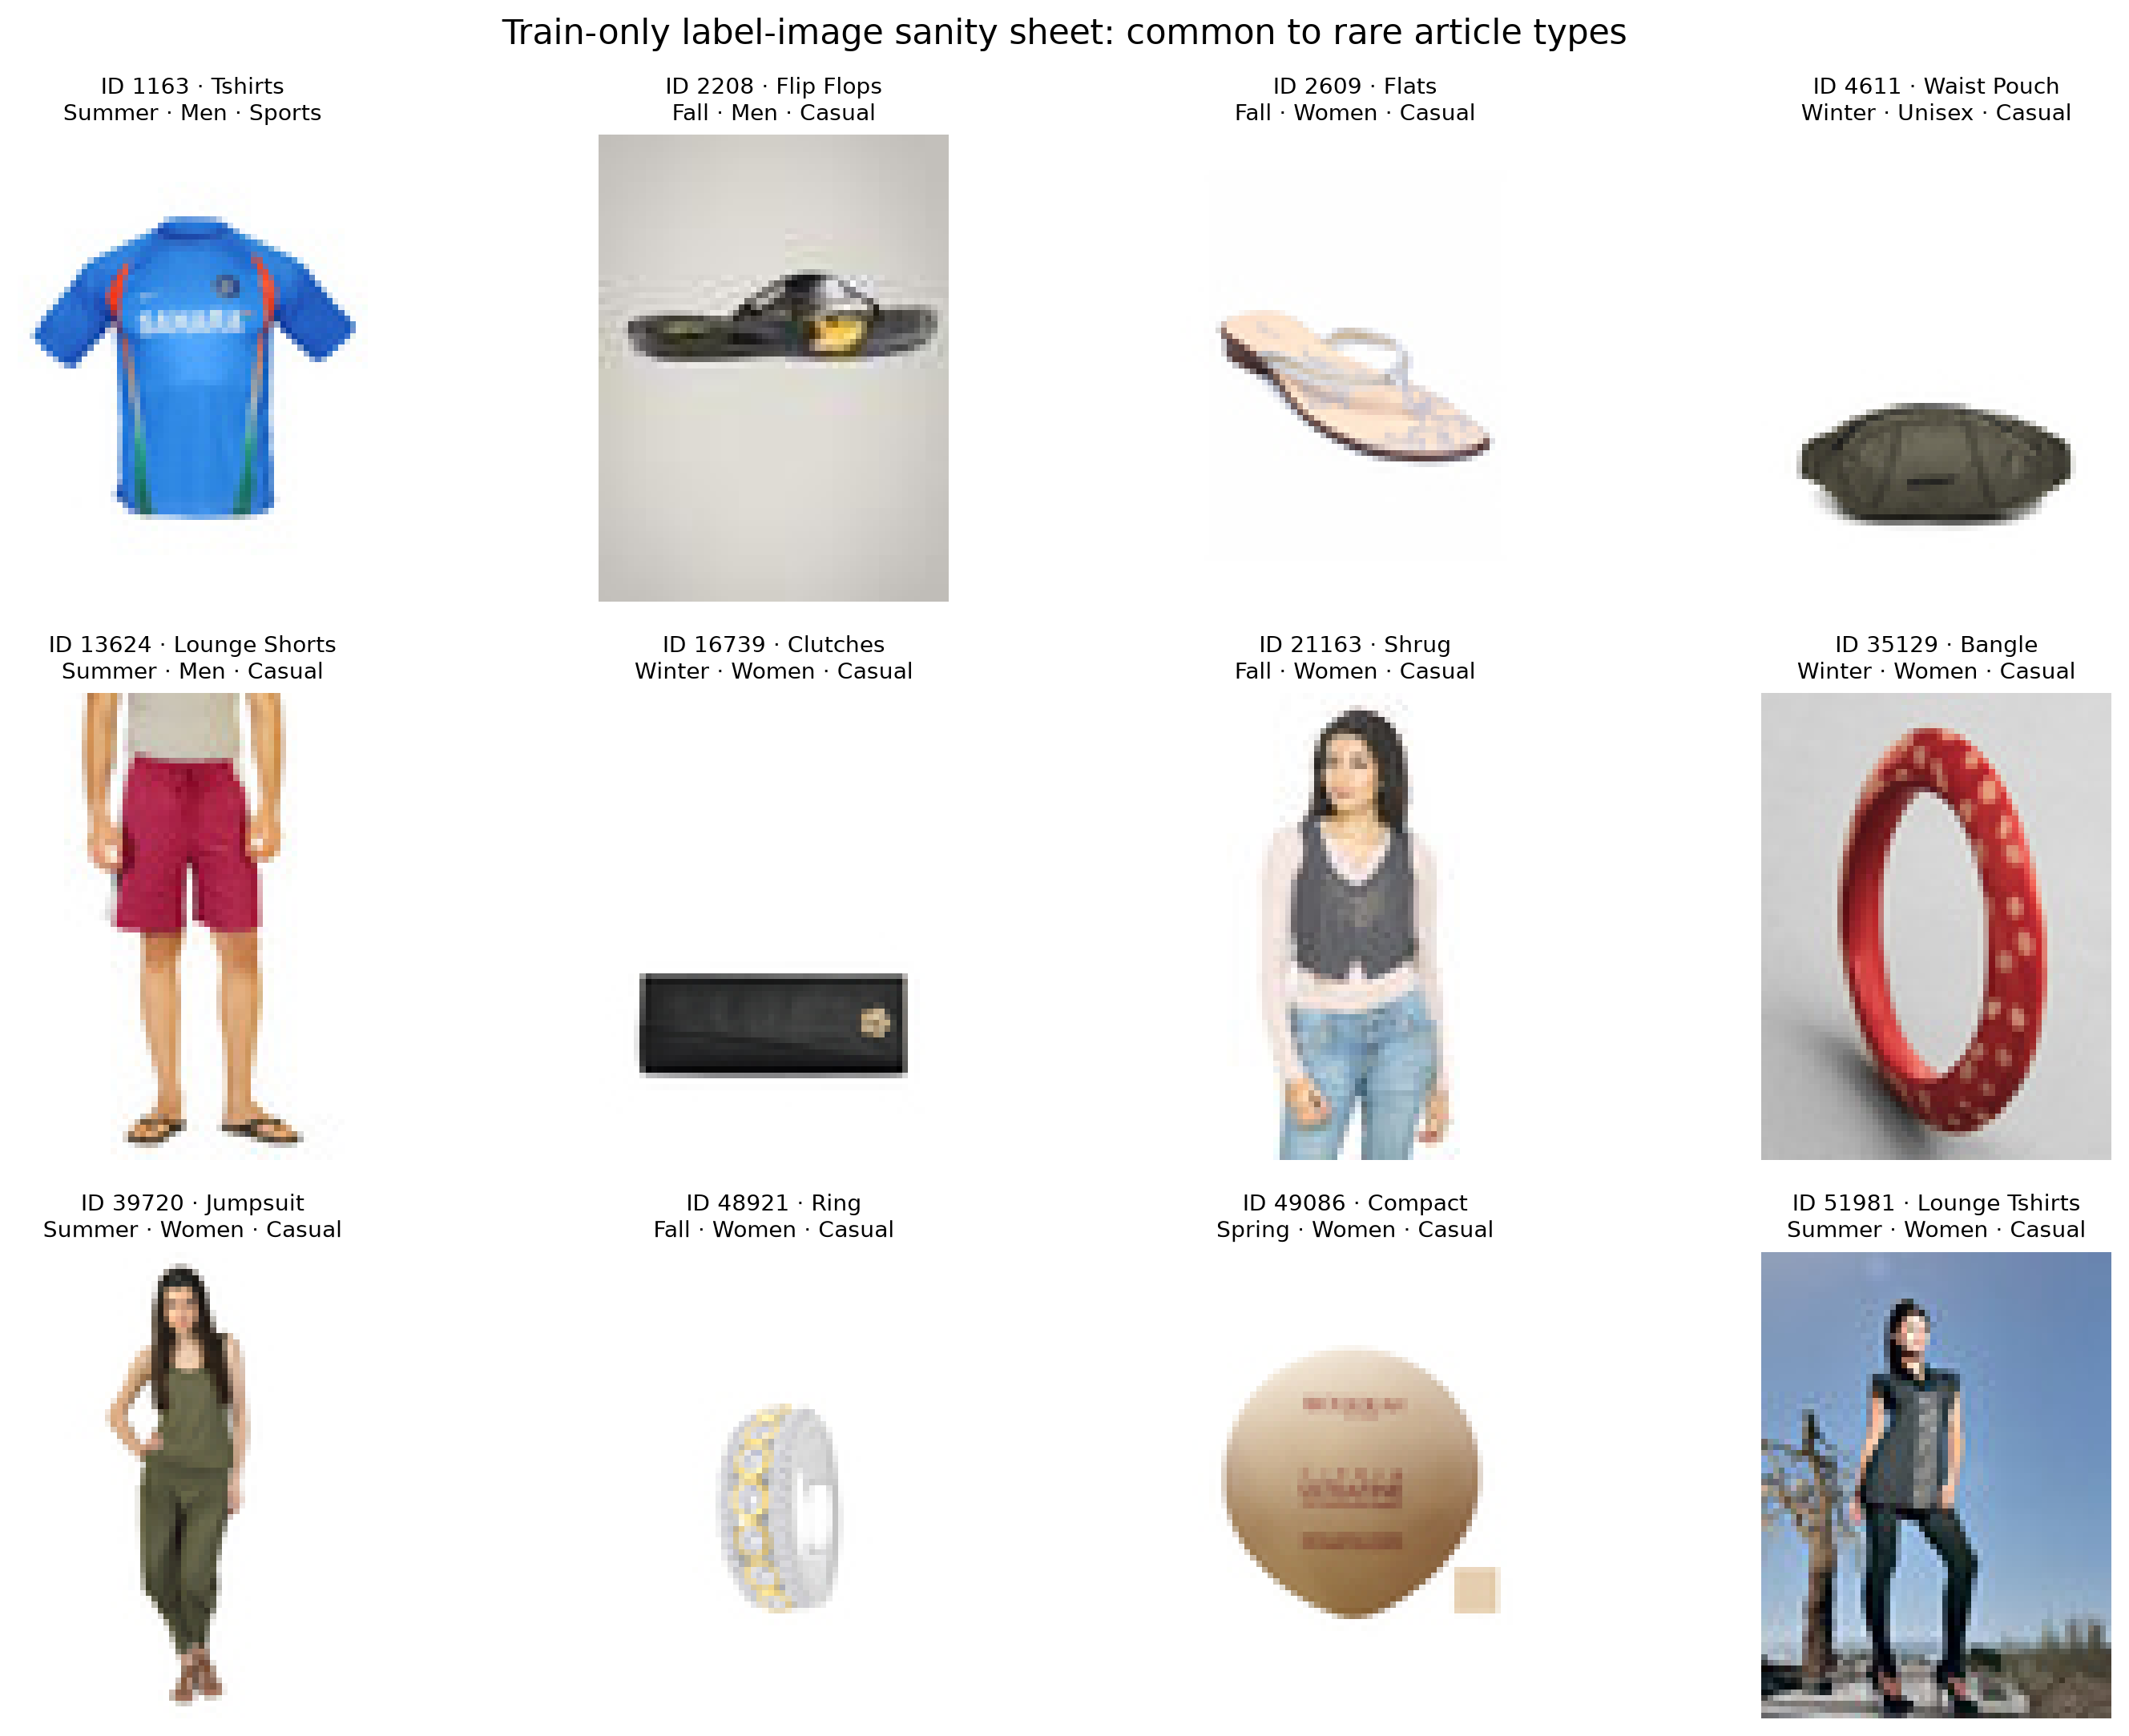

In [9]:
# Deterministic semantic sanity sample; labels remain unchanged.
label_columns = {target: f"{target}_deployed" for target in TARGET_COLUMNS}
complete_labels = pd.Series(True, index=train.index)
for target in TARGET_COLUMNS:
    complete_labels &= bool_mask(train[f"has_{target}_deployed_label"])
semantic_candidates = train.loc[
    complete_labels,
    ["id", "path", *label_columns.values()],
].copy()
if semantic_candidates.empty:
    raise ValueError("The training split has no products with all four labels")

article_counts = semantic_candidates["articleType_deployed"].value_counts()
ranked_articles = article_counts.sort_values(ascending=False, kind="stable").index.tolist()
article_positions = np.unique(
    np.linspace(0, len(ranked_articles) - 1, min(12, len(ranked_articles)), dtype=int)
)
selected_indices = []
sample_reasons = {}
for position in article_positions:
    article = ranked_articles[int(position)]
    rows = semantic_candidates[
        semantic_candidates["articleType_deployed"].eq(article)
    ].sort_values("id")
    if not rows.empty:
        chosen_index = rows.index[0]
        selected_indices.append(chosen_index)
        sample_reasons[chosen_index] = (
            f"articleType frequency rank {int(position) + 1} of {len(ranked_articles)}"
        )

if len(selected_indices) < min(12, len(semantic_candidates)):
    rarity = pd.Series(0.0, index=semantic_candidates.index)
    for column in label_columns.values():
        counts = semantic_candidates[column].value_counts()
        rarity += semantic_candidates[column].map(lambda value: 1.0 / counts[value])
    fill = (
        semantic_candidates.assign(_rarity=rarity)
        .drop(index=selected_indices)
        .sort_values(["_rarity", "id"], ascending=[False, True])
    )
    for chosen_index in fill.index:
        selected_indices.append(chosen_index)
        sample_reasons[chosen_index] = "rare multi-target combination fill"
        if len(selected_indices) == min(12, len(semantic_candidates)):
            break

label_image_sanity = semantic_candidates.loc[selected_indices].copy()
label_image_sanity["source_partition"] = "train"
label_image_sanity["sample_reason"] = [sample_reasons[index] for index in selected_indices]
label_image_sanity.rename(
    columns={f"{target}_deployed": target for target in TARGET_COLUMNS},
    inplace=True,
)
label_image_sanity.sort_values("id", inplace=True, ignore_index=True)
save_csv(label_image_sanity, "label_image_sanity.csv")

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for axis in axes.flat:
    axis.axis("off")
for axis, row in zip(axes.flat, label_image_sanity.itertuples(index=False)):
    title = (
        f"ID {int(row.id)} · {row.articleType}\n"
        f"{row.season} · {row.gender} · {row.usage}"
    )
    show_image(axis, open_rgb(row.path), title)
fig.suptitle("Train-only label-image sanity sheet: common to rare article types")
fig.tight_layout()
label_image_figure = save_figure(fig, "label_image_sanity.png")
show_figure(
    label_image_figure,
    (
        "Figure 3. Deterministic training images shown with all four catalogue labels. "
        "This contact sheet supports visual sanity checking and does not change a label."
    ),
)

> **Finding.** The contact sheet makes the semantic contract visible: one product image is
> checked against all four catalogue tags, including examples from the article-type tail. The saved
> sample is deterministic and train-only. Visual plausibility does not prove every tag is correct,
> especially for season, gender, and usage labels that may not be directly visible.
>
> **Modelling consequence.** Teammates use the sheet to form task-specific failure hypotheses and
> inspect model mistakes later. Any proposed relabelling or exclusion requires a separate documented
> rule and team decision; this notebook performs no automatic semantic correction.

### 3.3 Duplicate and entity controls

This stage checks exact hashes, accepted near-duplicate links, normalized product names, and
product-family groups across partitions. The visual examples also expose the limits of automatic
matching rules.

**Code step — Leakage-boundary plotting functions.**

Defines the two visual summaries used for accepted and rejected image pairs and normalized-name examples. The functions only prepare figures; the next steps perform the leakage checks.

In [10]:
# Automatic duplicate boundary and family-policy figures


def pair_canvas(first: Image.Image, second: Image.Image) -> Image.Image:
    canvas = Image.new(
        "RGB", (first.width + second.width + 6, max(first.height, second.height)), "white"
    )
    canvas.paste(first, (0, (canvas.height - first.height) // 2))
    canvas.paste(second, (first.width + 6, (canvas.height - second.height) // 2))
    return canvas


def plot_duplicate_boundary(train_frame: pd.DataFrame, candidates: pd.DataFrame) -> Path:
    train_ids = set(train_frame["id"].astype(int))
    lookup = train_frame.set_index("id")["path"].astype(str).to_dict()
    labelled = candidates[
        candidates["role_1"].eq("labelled")
        & candidates["role_2"].eq("labelled")
        & candidates["id_1"].astype(int).isin(train_ids)
        & candidates["id_2"].astype(int).isin(train_ids)
        & ~bool_mask(candidates["is_exact_sha256"])
    ].copy()
    labelled["pair_low"] = labelled[["id_1", "id_2"]].min(axis=1).astype(int)
    labelled["pair_high"] = labelled[["id_1", "id_2"]].max(axis=1).astype(int)
    labelled.drop_duplicates(["pair_low", "pair_high"], inplace=True)
    labelled["boundary_ratio"] = pd.concat(
        [
            labelled["dhash_distance"].astype(float) / 2,
            labelled["ahash_distance"].astype(float) / 1,
            labelled["mse"].astype(float) / 0.0005,
            labelled["mae"].astype(float) / 0.01,
            labelled["crop_mse"].astype(float) / 0.005,
            labelled["crop_mae"].astype(float) / 0.05,
            0.8 / labelled["foreground_ratio"].astype(float).clip(lower=1e-12),
        ],
        axis=1,
    ).max(axis=1)
    accepted = labelled[bool_mask(labelled["accepted_near_duplicate"])].sort_values(
        ["boundary_ratio", "pair_low", "pair_high"], ascending=[False, True, True]
    )
    rejected = labelled[~bool_mask(labelled["accepted_near_duplicate"])].sort_values(
        ["boundary_ratio", "pair_low", "pair_high"], ascending=[True, True, True]
    )
    fig, axes = plt.subplots(2, 4, figsize=(13, 7))
    for axis in axes.flat:
        axis.axis("off")
    for axis, row, label in [
        *[
            (axis, row, "Inside rule near boundary")
            for axis, row in zip(axes[0], accepted.head(4).itertuples(index=False))
        ],
        *[
            (axis, row, "Just outside rule")
            for axis, row in zip(axes[1], rejected.head(4).itertuples(index=False))
        ],
    ]:
        axis.axis("on")
        image = pair_canvas(open_rgb(lookup[int(row.id_1)]), open_rgb(lookup[int(row.id_2)]))
        show_image(
            axis,
            image,
            (
                f"{label}\nIDs {row.id_1}/{row.id_2}\n"
                f"rule ratio {row.boundary_ratio:.2f} · dHash {row.dhash_distance}"
            ),
        )
    if accepted.empty:
        axes[0, 0].text(0.5, 0.5, "No train-only rule match in this fixture", ha="center")
    if rejected.empty:
        axes[1, 0].text(0.5, 0.5, "No train-only rule rejection in this fixture", ha="center")
    fig.suptitle("Unique image pairs nearest the frozen automatic-rule boundary")
    fig.tight_layout()
    return save_figure(fig, "near_duplicate_boundary.png")


def plot_family_policy(sizes: pd.DataFrame, bases: pd.DataFrame, sensitivity: pd.DataFrame) -> Path:
    fig, axes = plt.subplots(
        1, 3, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1, 1.2, 1]}
    )
    size_plot = (
        sizes.assign(size_bin=sizes["family_size"].clip(upper=10))
        .groupby("size_bin", as_index=False)["family_units"].sum()
    )
    axes[0].bar(size_plot["size_bin"].astype(str), size_plot["family_units"], color=PALETTE[0])
    axes[0].set_yscale("log")
    axes[0].set_title("Family-size distribution")
    axes[0].set_xlabel("Product rows per family; 10 means 10+")
    axes[0].set_ylabel("Family units, log scale")
    basis_names = {
        "singleton": "Singleton",
        "normalized_product_name": "Name only",
        "exact_sha256+normalized_product_name+accepted_near_duplicate": (
            "SHA + name + visual"
        ),
        "normalized_product_name+accepted_near_duplicate": "Name + visual",
        "exact_sha256+accepted_near_duplicate": "SHA + visual",
        "accepted_near_duplicate": "Visual only",
    }
    basis = bases.sort_values("product_rows").tail(8).copy()
    basis["display_basis"] = basis["block_basis"].map(basis_names).fillna("Other")
    axes[1].barh(basis["display_basis"], basis["product_rows"], color=PALETTE[1])
    axes[1].set_title("Rows controlled by block basis")
    axes[1].set_xlabel("Active product rows")
    for target, group in sensitivity.groupby("target", sort=False):
        axes[2].plot(group["minimum_train_families"], group["supported_classes"], marker="o", label=target)
    axes[2].set_xticks([2, 3, 4, 5])
    axes[2].set_yscale("log", base=2)
    axes[2].set_yticks([4, 8, 16, 32, 64, 128])
    axes[2].set_yticklabels(["4", "8", "16", "32", "64", "128"])
    axes[2].set_ylim(3.5, 128)
    axes[2].set_title("Support-threshold sensitivity")
    axes[2].set_xlabel("Minimum independent train families")
    axes[2].set_ylabel("Primary metric classes")
    axes[2].legend(frameon=False, fontsize=8)
    fig.suptitle("Family blocking prevents leakage but reduces independent evidence")
    fig.tight_layout()
    return save_figure(fig, "family_policy.png")

**Code step — Automatic leakage checks.**

Loads duplicate evidence, proves zero active crossings, and quantifies the family policy. No human file is read.

In [11]:
near_candidates = pd.read_csv(AUDIT / "near_duplicate_candidates.csv.gz", keep_default_na=False)
family_summary = json.loads(FAMILY_SUMMARY_PATH.read_text(encoding="utf-8"))

active = splits[~splits["partition"].eq("quarantine")]
crossing_checks = {
    "exact_sha256_groups": int((splits.groupby("sha256")["partition"].nunique() > 1).sum()),
    "product_family_groups": int(
        (active.groupby("product_family_group")["partition"].nunique() > 1).sum()
    ),
    "normalized_name_keys": int(
        (
            active[active["product_name_key"].astype(str).ne("")]
            .groupby("product_name_key")["partition"]
            .nunique()
            > 1
        ).sum()
    ),
}
if any(crossing_checks.values()):
    raise ValueError(f"A duplicate or family group crosses the canonical split: {crossing_checks}")

partitions = splits.set_index("id")["partition"].astype(str).to_dict()
labelled_edges = near_candidates[
    near_candidates["role_1"].eq("labelled")
    & near_candidates["role_2"].eq("labelled")
    & bool_mask(near_candidates["accepted_near_duplicate"])
].copy()
labelled_edges["partition_1"] = labelled_edges["id_1"].astype(int).map(partitions)
labelled_edges["partition_2"] = labelled_edges["id_2"].astype(int).map(partitions)
visual_crossings = labelled_edges[
    labelled_edges["partition_1"].ne("quarantine")
    & labelled_edges["partition_2"].ne("quarantine")
    & labelled_edges["partition_1"].ne(labelled_edges["partition_2"])
]
if not visual_crossings.empty:
    raise ValueError("An accepted visual edge crosses active model partitions")

family_groups = (
    active.groupby("product_family_group", sort=True)
    .agg(product_rows=("id", "size"), block_basis=("family_group_basis", "first"))
    .reset_index()
)
family_size_distribution = (
    family_groups["product_rows"].value_counts().sort_index()
    .rename_axis("family_size").reset_index(name="family_units")
)
family_basis_summary = (
    family_groups.groupby("block_basis", as_index=False)
    .agg(family_units=("product_family_group", "size"), product_rows=("product_rows", "sum"),
         multirow_families=("product_rows", lambda values: int(values.gt(1).sum())),
         largest_family=("product_rows", "max"))
)
sensitivity_rows = []
for target in TARGET_COLUMNS:
    valid = train[bool_mask(train[f"has_{target}_deployed_label"])]
    support = valid.groupby(f"{target}_deployed")["product_family_group"].nunique()
    for threshold in (2, 3, 4, 5):
        sensitivity_rows.append({"target": target, "minimum_train_families": threshold,
            "official_classes": len(support), "supported_classes": int(support.ge(threshold).sum()),
            "limited_classes": int(support.lt(threshold).sum())})
support_threshold_sensitivity = pd.DataFrame(sensitivity_rows)
active_rows = len(active)
family_units = int(family_groups["product_family_group"].nunique())
reduced_units = active_rows - family_units
family_policy_summary = pd.DataFrame([
    {"measure": "active product rows", "value": active_rows, "meaning": "loader/reporting rows", "modelling_action": "do not treat rows as independent"},
    {"measure": "independent family units", "value": family_units, "meaning": "split/uncertainty units", "modelling_action": "bootstrap by family"},
    {"measure": "units removed by blocking", "value": reduced_units, "meaning": f"{reduced_units / active_rows:.1%} fewer units", "modelling_action": "accept cost to stop leakage"},
    {"measure": "multi-row families", "value": int(family_groups["product_rows"].gt(1).sum()), "meaning": "kept whole", "modelling_action": "never split their rows"},
    {"measure": "largest family", "value": int(family_groups["product_rows"].max()), "meaning": "largest over-block risk", "modelling_action": "report support sensitivity"},
])
expected_family = {"active_product_rows": active_rows, "active_family_groups": family_units,
    "family_units_fewer_than_product_rows": reduced_units,
    "active_multirow_family_groups": int(family_groups["product_rows"].gt(1).sum()),
    "largest_active_family_group": int(family_groups["product_rows"].max())}
if any(int(family_summary.get(key, -1)) != value for key, value in expected_family.items()):
    raise ValueError("The product-family summary is stale")

**Code step — Family-policy evidence.**

Saves the family-size, block-basis, and 2/3/4/5 support-threshold evidence.

In [12]:
save_csv(family_policy_summary, "family_policy_summary.csv")
save_csv(family_basis_summary, "family_basis_summary.csv")
save_csv(family_size_distribution, "family_size_distribution.csv")
save_csv(support_threshold_sensitivity, "support_threshold_sensitivity.csv")
family_policy_figure = plot_family_policy(
    family_size_distribution, family_basis_summary, support_threshold_sensitivity
)
show_table(family_policy_summary, "Family blocking cost and modelling trade-offs")
show_table(support_threshold_sensitivity, "2/3/4/5 train-family support sensitivity")

,measure,value,meaning,modelling_action
0,active product rows,"38,551",loader/reporting rows,do not treat rows as independent
1,independent family units,"27,009",split/uncertainty units,bootstrap by family
2,units removed by blocking,"11,542",29.9% fewer units,accept cost to stop leakage
3,multi-row families,"4,567",kept whole,never split their rows
4,largest family,80,largest over-block risk,report support sensitivity


,target,minimum_train_families,official_classes,supported_classes,limited_classes
0,articleType,2,124,105,19
1,articleType,3,124,100,24
2,articleType,4,124,98,26
3,articleType,5,124,94,30
4,season,2,4,4,0
5,season,3,4,4,0
6,season,4,4,4,0
7,season,5,4,4,0
8,gender,2,5,5,0
9,gender,3,5,5,0


**Code step — Duplicate evidence summary.**

Saves the leakage and family-control tables, then displays the focused tables and Figures 1 and 2 used by the report.

,check,value,required
0,exact SHA groups crossing partitions,0,0
1,active family groups crossing partitions,0,0
2,active name keys crossing partitions,0,0
3,accepted visual edges crossing partitions,0,0
4,quarantined labelled rows,61,report
5,official prediction IDs in labelled split,0,0



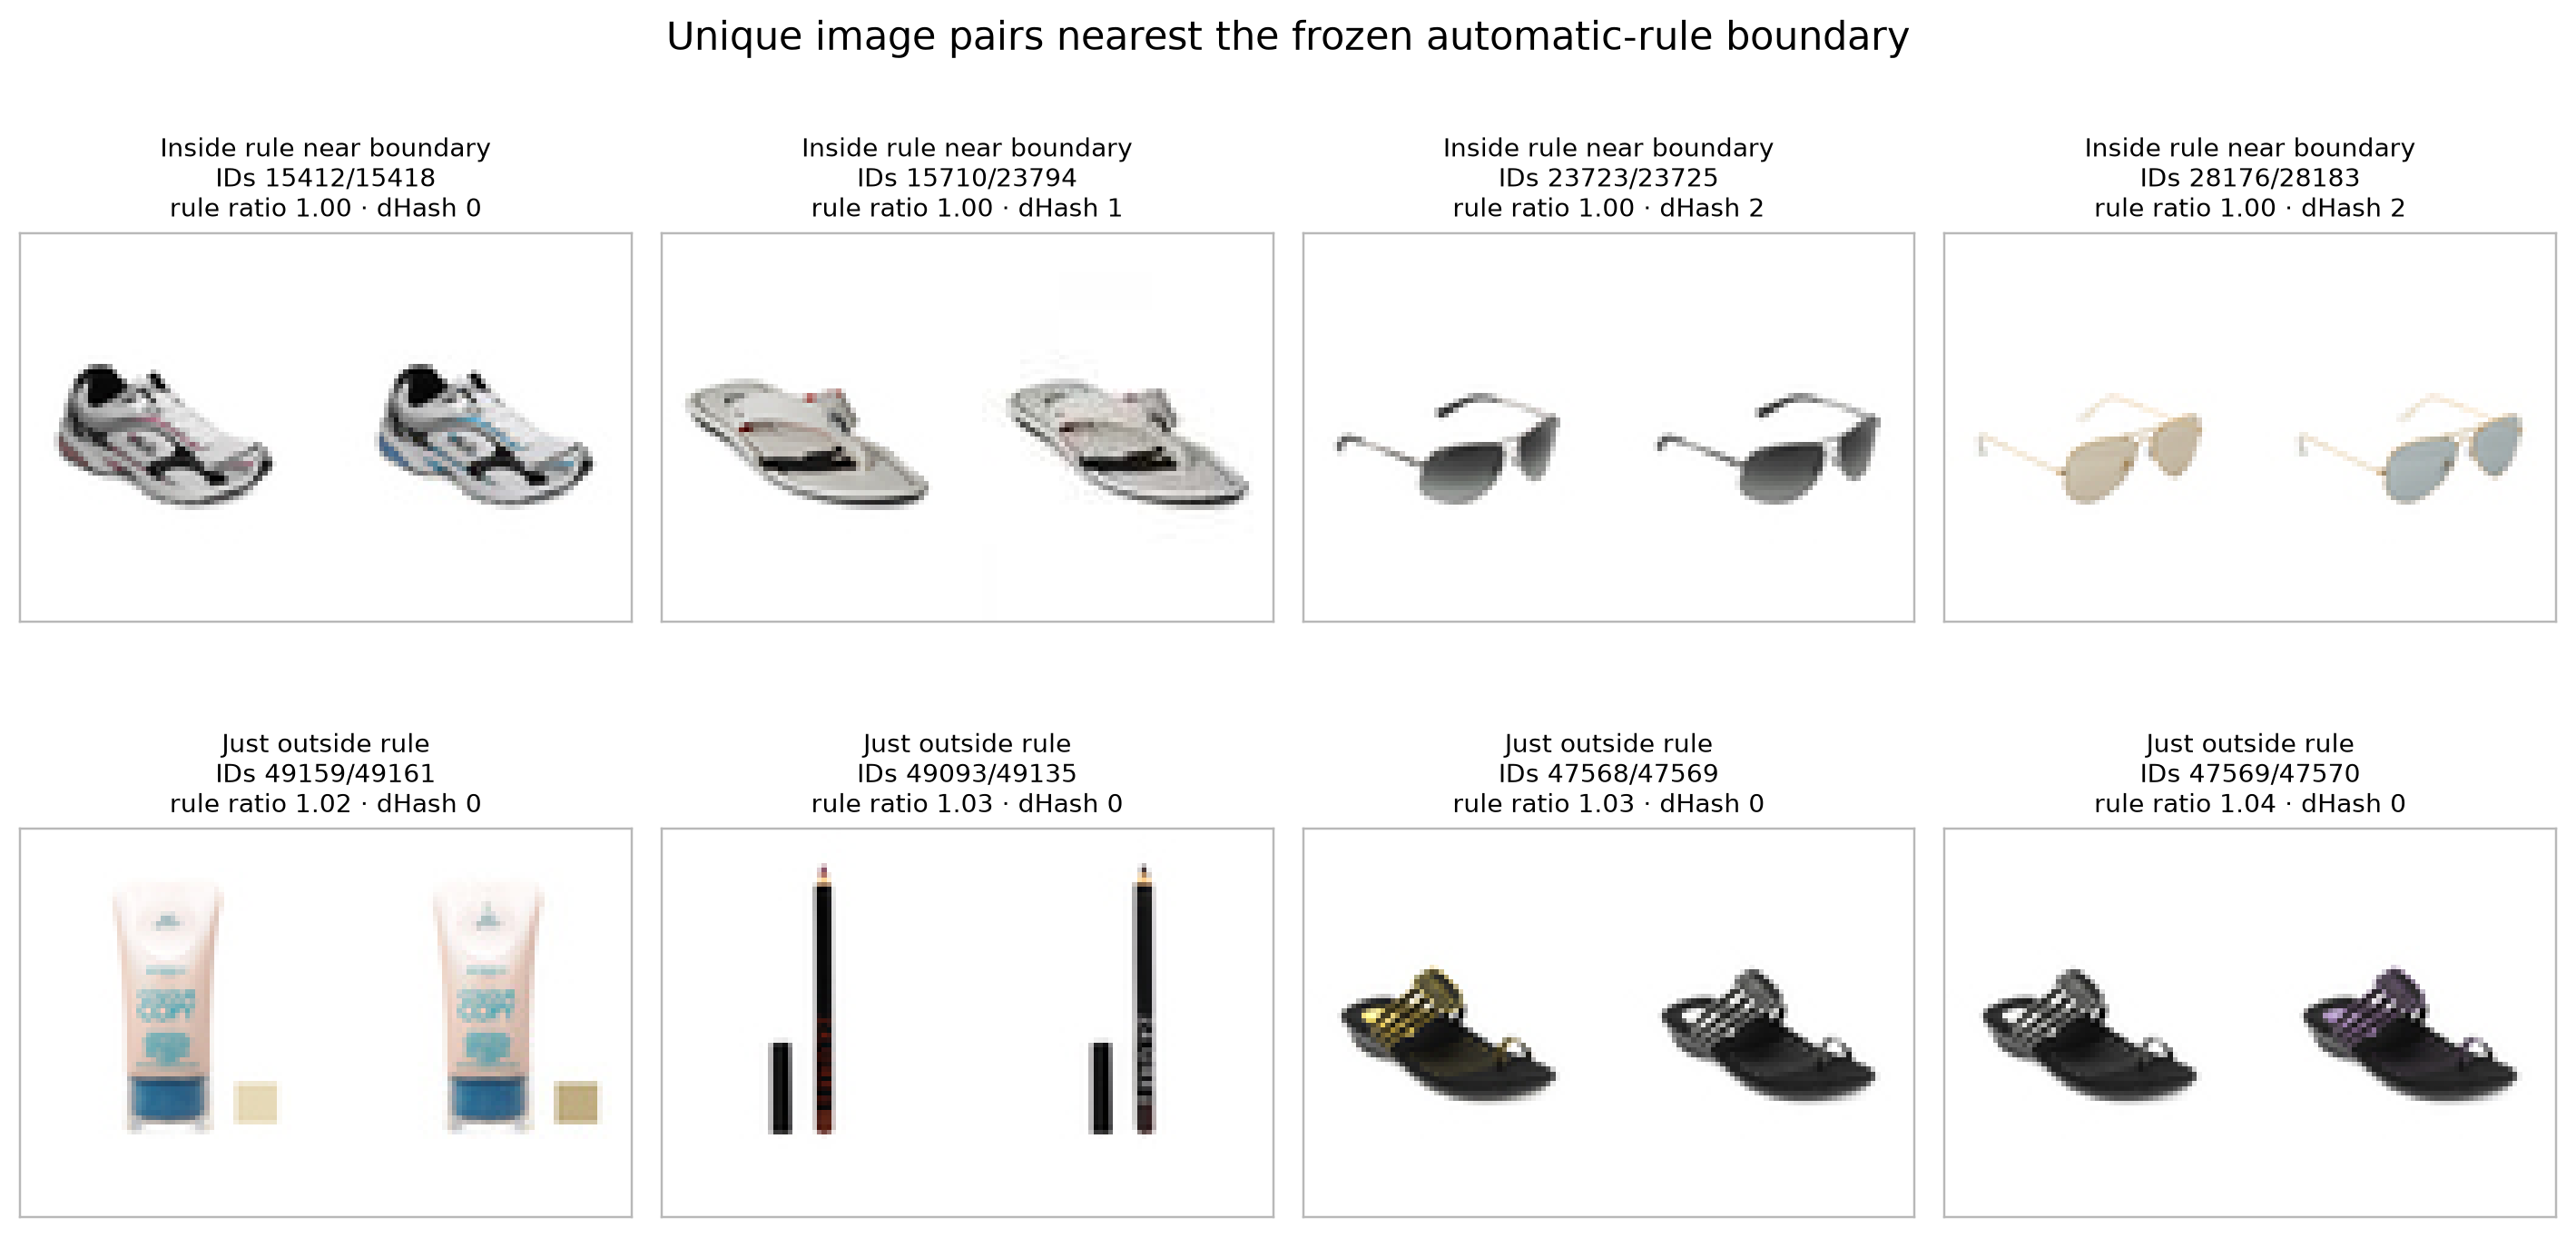


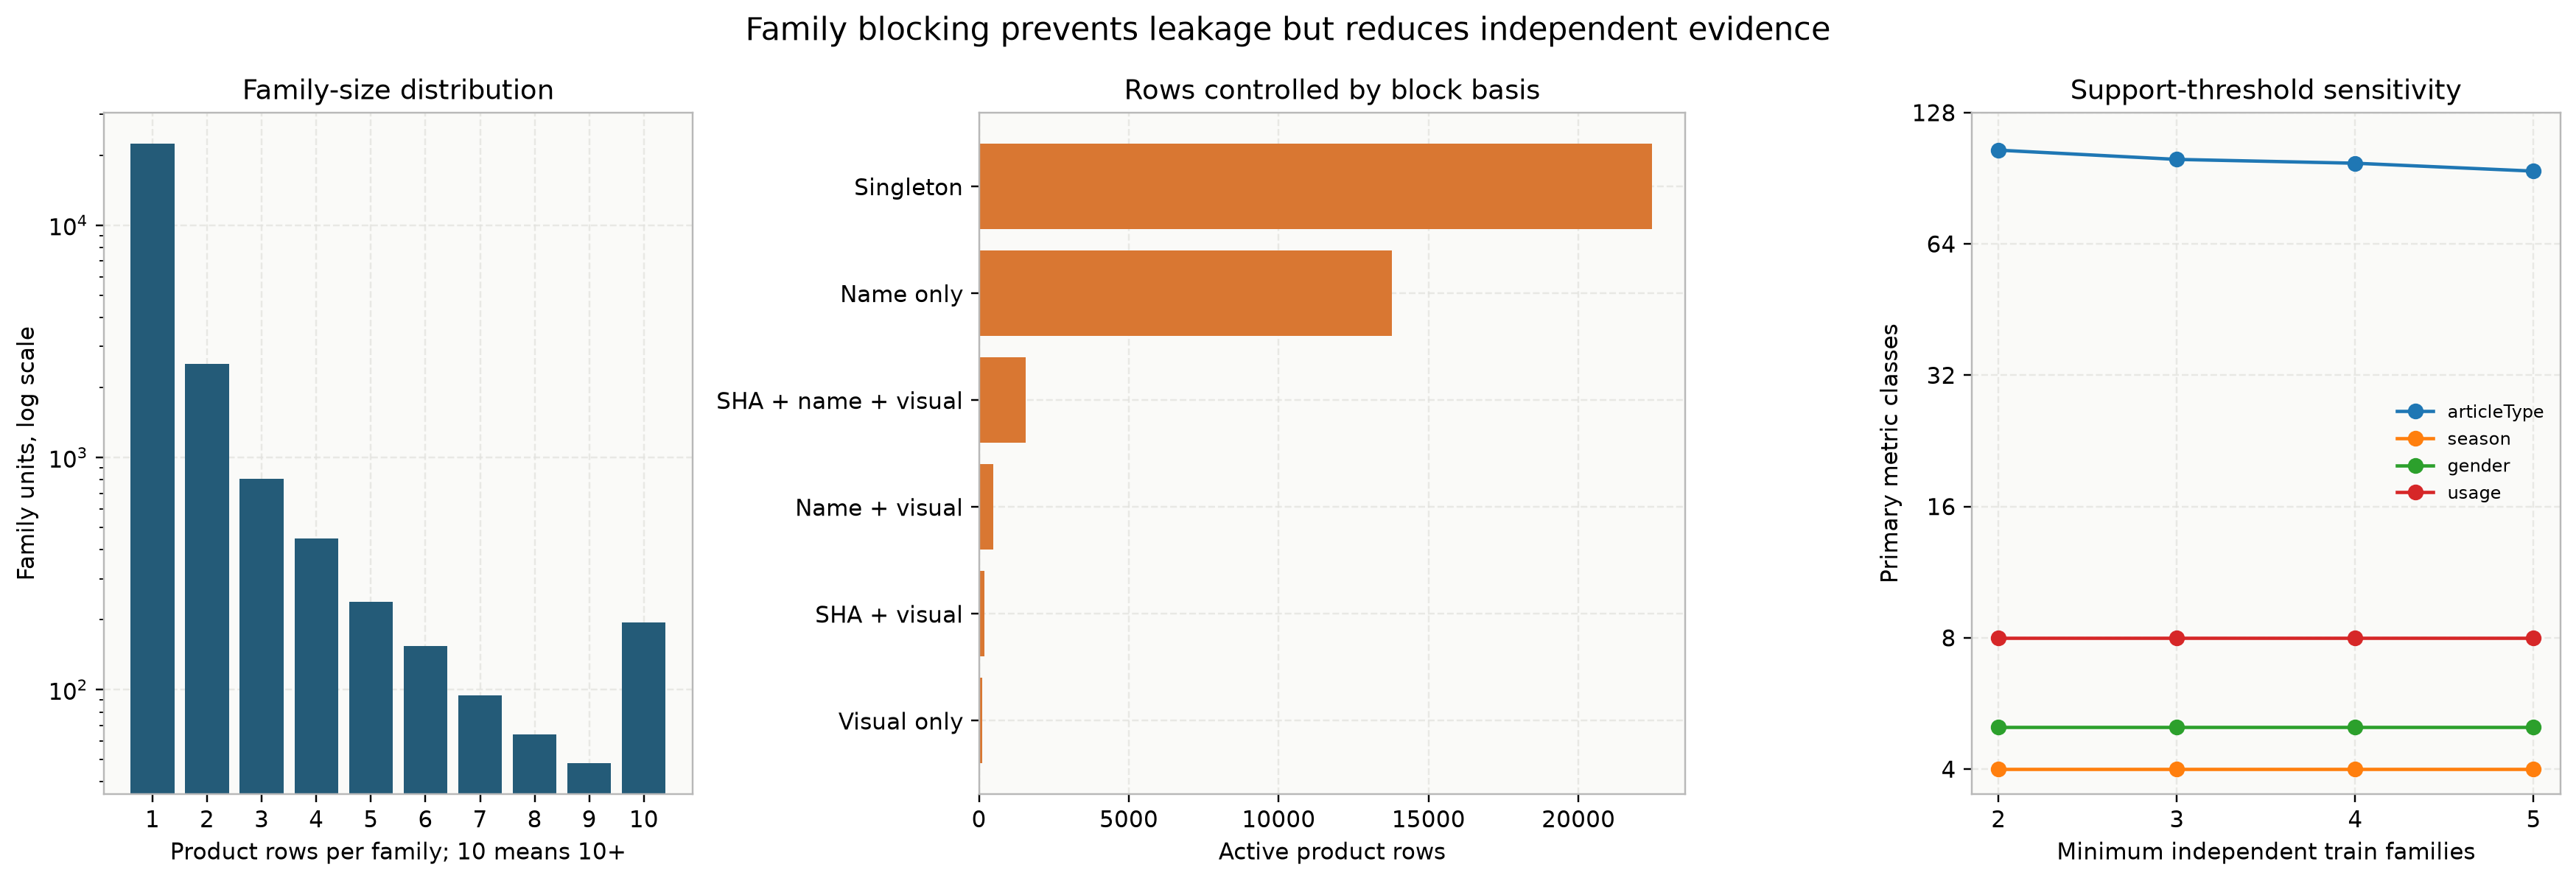

In [13]:
duplicate_summary = pd.DataFrame(
    [
        {
            "check": "exact SHA groups crossing partitions",
            "value": crossing_checks["exact_sha256_groups"],
            "required": 0,
        },
        {
            "check": "active family groups crossing partitions",
            "value": crossing_checks["product_family_groups"],
            "required": 0,
        },
        {
            "check": "active name keys crossing partitions",
            "value": crossing_checks["normalized_name_keys"],
            "required": 0,
        },
        {
            "check": "accepted visual edges crossing partitions",
            "value": len(visual_crossings),
            "required": 0,
        },
        {
            "check": "quarantined labelled rows",
            "value": int(splits["partition"].eq("quarantine").sum()),
            "required": "report",
        },
        {"check": "official prediction IDs in labelled split", "value": 0, "required": 0},
    ]
)
save_csv(duplicate_summary, "duplicate_summary.csv")

duplicate_figure = plot_duplicate_boundary(train, near_candidates)
show_table(duplicate_summary, "Leakage checks")
show_figure(
    duplicate_figure,
    (
        "Figure 1. Train-only visual pairs show the automatic leakage boundary. "
        "Uncertain cross-role pairs are conservatively quarantined, without blocking EDA."
    ),
)
show_figure(
    family_policy_figure,
    (
        "Figure 2. Family sizes, block bases, and support-threshold sensitivity quantify the "
        "leakage-safety versus validation-coverage trade-off."
    ),
)

> **Finding.** Exact hashes, accepted visual links, normalized names, and product-family groups
> have zero crossings between active partitions. Sixty-one labelled product IDs are quarantined. The
> family rule changes 38,551 active product rows into 27,009 independent units: 11,542 fewer units
> (29.9%). There are 4,567 multi-row families and the largest contains 80 rows. Article-type support
> at family thresholds 2, 3, 4, and 5 is 105, 100, 98, and 94 classes.
>
> **Modelling consequence.** Splitting and sampling operate at product-family level, not image-row
> level. Product-row metrics are still reported for scale, but family-unit counts carry the uncertainty.
> Three families is the chosen compromise. Open decisions stay non-blocking and use safe quarantine.

## 4. Target distributions and class balance

Target analysis establishes prediction scope, class support, imbalance, relationships, catalogue
ambiguity, and shortcut risk. These results define the metrics and failure slices used in later
experiments.

The univariate analysis measures support once per unique product ID and compares train and
validation product shares. The paired image rows are deliberately not double-counted here. This
exposes rare classes and dominant labels that plain accuracy would hide.

### 4.1 Product-level support and development balance

The first pass measures class support and development coverage without changing the training distribution.

**Code step — Target summary functions.**

Defines the rules for supported labels, training support, and train-versus-validation balance. These functions keep all denominators and label slices explicit.

In [14]:
# Target support and development-balance evidence


def target_columns(frame: pd.DataFrame, target: str) -> tuple[str, str]:
    supported = (f"{target}_supported", f"has_{target}_supported_label")
    if all(column in frame for column in supported):
        return supported
    deployed = (f"{target}_deployed", f"has_{target}_deployed_label")
    if all(column in frame for column in deployed):
        return deployed
    return target, f"has_{target}_label"


def summarize_target(train_frame: pd.DataFrame, target: str) -> dict[str, Any]:
    deployed = bool_mask(train_frame[f"has_{target}_deployed_label"])
    supported = bool_mask(train_frame[f"has_{target}_supported_label"])
    limited = deployed & ~supported
    counts = train_frame.loc[supported, f"{target}_supported"].value_counts()
    return {
        "target": target,
        "source_partition": "train",
        "official_label_products": int(deployed.sum()),
        "missing_label_products": int((~deployed).sum()),
        "supported_primary_products": int(supported.sum()),
        "limited_official_products": int(limited.sum()),
        "classes": int(len(counts)),
        "most_common": str(counts.index[0]),
        "most_common_count": int(counts.iloc[0]),
        "singletons": int(counts.eq(1).sum()),
        "classes_below_10": int(counts.lt(10).sum()),
    }


def validation_diagnostic(frame: pd.DataFrame, target: str) -> dict[str, Any]:
    label_column, mask_column = target_columns(frame, target)
    counts: dict[str, pd.Series] = {}
    denominators: dict[str, int] = {}
    for partition in ("train", "val"):
        rows = frame[frame["partition"].eq(partition)]
        valid = rows[bool_mask(rows[mask_column])]
        if valid.empty:
            raise ValueError(f"No valid {partition} labels for {target}")
        counts[partition] = valid[label_column].value_counts()
        denominators[partition] = len(valid)
    classes = counts["train"].index
    aligned = {
        partition: counts[partition].reindex(classes, fill_value=0)
        for partition in ("train", "val")
    }
    proportions = {
        partition: aligned[partition] / denominators[partition] * 100
        for partition in ("train", "val")
    }
    gaps = (proportions["train"] - proportions["val"]).abs()
    family_rows = []
    for label in classes:
        row = {"target": target, "label": str(label)}
        for partition in ("train", "val"):
            part = frame[frame["partition"].eq(partition)]
            labelled = part[
                bool_mask(part[mask_column]) & part[label_column].eq(label)
            ]
            row[f"{partition}_product_rows"] = int(len(labelled))
            row[f"{partition}_family_units"] = int(
                labelled["product_family_group"].nunique()
            )
        family_rows.append(row)
    family_coverage = pd.DataFrame(family_rows)
    return {
        "target": target,
        "train_valid": denominators["train"],
        "val_valid": denominators["val"],
        "train_classes": len(classes),
        "classes_seen_in_val": int(aligned["val"].gt(0).sum()),
        "coverage_percent": float(aligned["val"].gt(0).mean() * 100),
        "missing_classes": "; ".join(map(str, aligned["val"][aligned["val"].eq(0)].index))
        or "None",
        "max_gap_percentage_points": float(gaps.max()),
        "mean_gap_percentage_points": float(gaps.mean()),
        "classes_with_one_val_family": int(
            family_coverage["val_family_units"].eq(1).sum()
        ),
        "classes_with_two_val_families": int(
            family_coverage["val_family_units"].eq(2).sum()
        ),
        "classes_with_fewer_than_three_val_families": int(
            family_coverage["val_family_units"].lt(3).sum()
        ),
        "counts": aligned,
        "proportions": proportions,
        "family_coverage": family_coverage,
    }

**Code step — Target distribution plotting functions.**

Defines the long-tail, target-distribution, and development-balance figures. Every count is a unique product ID, not a doubled image-input row.

In [15]:
def plot_article_tail(train_frame: pd.DataFrame) -> Path:
    deployed = bool_mask(train_frame["has_articleType_deployed_label"])
    supported = bool_mask(train_frame["has_articleType_supported_label"])
    counts = train_frame.loc[deployed, "articleType_deployed"].value_counts()
    supported_labels = set(train_frame.loc[supported, "articleType_supported"].astype(str))
    weak_labels = set(map(str, counts.index)) - supported_labels
    top = counts.head(min(25, len(counts))).sort_values()
    fig, (left, right) = plt.subplots(
        1, 2, figsize=(14, 7), gridspec_kw={"width_ratios": [1.35, 1]}
    )
    bars = left.barh(top.index.astype(str), top.values, color=PALETTE[0])
    left.set_title("Most common official article types")
    left.set_xlabel("Training products")
    left.grid(axis="y", visible=False)
    left.bar_label(bars, labels=[f"{value:,}" for value in top.values], padding=3, fontsize=8)
    if len(top):
        left.set_xlim(0, max(top.max() * 1.18, 1))

    ranks = np.arange(1, len(counts) + 1)
    is_weak = np.array([str(label) in weak_labels for label in counts.index])
    right.plot(ranks, counts.values, color="#9CA3AF", linewidth=1.2, zorder=1)
    right.scatter(
        ranks[~is_weak],
        counts.values[~is_weak],
        color=PALETTE[0],
        s=18,
        label=f"Supported primary slice: {len(supported_labels)}",
        zorder=2,
    )
    right.scatter(
        ranks[is_weak],
        counts.values[is_weak],
        color=PALETTE[1],
        s=28,
        marker="D",
        label=f"Weak but official: {len(weak_labels)}",
        zorder=3,
    )
    right.axhline(10, color="#6B7280", linestyle="--", linewidth=1, label="10 products")
    right.set_yscale("log")
    right.set_title(f"All {len(counts)} official output classes")
    right.set_xlabel("Class rank")
    right.set_ylabel("Training products (log scale)")
    right.legend(frameon=False, fontsize=8)
    fig.suptitle("Article type has a strong long tail (training products only)")
    fig.tight_layout()
    return save_figure(fig, "article_type_long_tail.png")


def plot_target_distributions(train_frame: pd.DataFrame) -> Path:
    targets = ("gender", "season", "usage")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.3))
    for axis, target in zip(axes, targets):
        valid = bool_mask(train_frame[f"has_{target}_deployed_label"])
        counts = train_frame.loc[valid, f"{target}_deployed"].value_counts()
        labels = list(map(str, counts.index))
        values = counts.astype(int).tolist()
        missing = int((~valid).sum())
        colors = [PALETTE[0]] * len(values)
        if missing:
            labels.append("Missing")
            values.append(missing)
            colors.append(PALETTE[1])
        bars = axis.bar(labels, values, color=colors)
        if target == "usage" and values and max(values) / max(min(values), 1) > 20:
            axis.set_yscale("log")
            axis.set_ylabel("Training products (log scale)")
        else:
            axis.set_ylabel("Training products")
        axis.set_title(f"{target} (valid products={int(valid.sum()):,})")
        axis.tick_params(axis="x", rotation=35)
        for label in axis.get_xticklabels():
            label.set_ha("right")
        axis.bar_label(bars, labels=[f"{value:,}" for value in values], padding=2, fontsize=8)
        axis.grid(axis="x", visible=False)
    fig.suptitle("Official training-product target distributions and real blanks")
    fig.tight_layout()
    return save_figure(fig, "target_distributions.png")


def plot_development_balance(frame: pd.DataFrame, diagnostics: dict[str, dict[str, Any]]) -> Path:
    article = diagnostics["articleType"]
    classes = list(article["counts"]["train"].head(10).index)
    positions = np.arange(len(classes))
    width = 0.38
    fig = plt.figure(figsize=(14, 9))
    grid = fig.add_gridspec(2, 2, height_ratios=(1.35, 1), hspace=0.55, wspace=0.35)
    top = fig.add_subplot(grid[0, :])
    gap_axis = fig.add_subplot(grid[1, 0])
    coverage_axis = fig.add_subplot(grid[1, 1])
    train_values = article["proportions"]["train"].reindex(classes).to_numpy()
    val_values = article["proportions"]["val"].reindex(classes).to_numpy()
    train_bars = top.bar(
        positions - width / 2, train_values, width, color=PALETTE[0], label="Train"
    )
    val_bars = top.bar(
        positions + width / 2, val_values, width, color=PALETTE[1], label="Validation"
    )
    top.set_xticks(positions, classes, rotation=32, ha="right")
    top.set_ylabel("Within-partition valid labels (%)")
    top.set_title("Top article types selected by training frequency")
    top.legend(frameon=False)
    top.bar_label(train_bars, fmt="%.1f", padding=2, fontsize=7)
    top.bar_label(val_bars, fmt="%.1f", padding=2, fontsize=7)
    labels = ("Article type", "Season", "Gender", "Usage")
    gaps = [diagnostics[target]["max_gap_percentage_points"] for target in TARGET_COLUMNS]
    gap_bars = gap_axis.barh(labels, gaps, color=PALETTE[:4])
    gap_axis.invert_yaxis()
    gap_axis.set_title("Largest class-share gap")
    gap_axis.set_xlabel("Percentage points")
    gap_axis.bar_label(gap_bars, fmt="%.2f pp", padding=3, fontsize=8)
    family_bins = (
        pd.concat(
            [diagnostics[target]["family_coverage"] for target in TARGET_COLUMNS],
            ignore_index=True,
        )
        .assign(
            validation_support=lambda data: pd.cut(
                data["val_family_units"],
                bins=[-1, 0, 1, 2, np.inf],
                labels=["0", "1", "2", "3+"],
            )
        )
        .groupby(["target", "validation_support"], observed=False)
        .size()
        .unstack(fill_value=0)
        .reindex(index=TARGET_COLUMNS, columns=["0", "1", "2", "3+"], fill_value=0)
    )
    positions = np.arange(len(TARGET_COLUMNS))
    width = 0.2
    colors = ("#DC2626", PALETTE[1], "#F59E0B", PALETTE[0])
    for offset, (support, color) in enumerate(zip(family_bins.columns, colors)):
        bars = coverage_axis.bar(
            positions + (offset - 1.5) * width,
            family_bins[support],
            width,
            color=color,
            label=f"{support} validation families",
        )
        coverage_axis.bar_label(bars, padding=2, fontsize=7)
    coverage_axis.set_xticks(positions, labels, rotation=20, ha="right")
    coverage_axis.set_title("Independent validation-family support")
    coverage_axis.set_ylabel("Supported classes")
    coverage_axis.legend(frameon=False, fontsize=7, ncols=2)
    fig.suptitle("Development balance uses local percentages; holdout stays closed")
    fig.subplots_adjust(top=0.92, bottom=0.08, left=0.1, right=0.96)
    return save_figure(fig, "development_balance.png")

**Code step — Taxonomy and support evidence.**

Builds the train-fitted taxonomy, records limited official classes, checks the literal NA label, and saves target and validation summaries.

In [16]:
label_maps = load_label_maps(PROCESSED / "label_maps.json")
taxonomy_policy = json.loads(TAXONOMY_PATH.read_text(encoding="utf-8"))
if taxonomy_policy.get("fit_partition") != "train":
    raise ValueError("The deployment taxonomy was not fitted on train")
taxonomy_rows = []
exclusion_rows = []
for target in TARGET_COLUMNS:
    official = list(map(str, label_maps[target]["classes"]))
    supported = sorted(
        set(
            train.loc[
                bool_mask(train[f"has_{target}_supported_label"]),
                f"{target}_supported",
            ].astype(str)
        )
    )
    limited = sorted(set(official) - set(supported))
    policy_supported = set(taxonomy_policy["targets"][target]["supported_classes"])
    if set(supported) != policy_supported:
        raise ValueError(f"Frozen supported classes disagree for {target}")
    family_support = (
        train.loc[
            bool_mask(train[f"has_{target}_supported_label"]),
            [f"{target}_supported", "product_family_group"],
        ]
        .drop_duplicates()
        .groupby(f"{target}_supported")["product_family_group"]
        .nunique()
    )
    if not family_support.ge(3).all():
        raise ValueError(f"A supported {target} class has fewer than three train families")
    validation_raw = bool_mask(validation[f"has_{target}_label"])
    validation_known = bool_mask(validation[f"has_{target}_deployed_label"])
    validation_unknown = sorted(
        validation.loc[validation_raw & ~validation_known, target].astype(str).unique()
    )
    taxonomy_rows.append(
        {
            "target": target,
            "official_output_classes": len(official),
            "supported_primary_metric_classes": len(supported),
            "limited_but_still_official": len(limited),
            "validation_unknown_to_train": len(validation_unknown),
            "semantic_merges": "None",
            "source": "train-fitted label map and train family support",
        }
    )
    for label in limited:
        groups = train.loc[
            bool_mask(train[f"has_{target}_deployed_label"])
            & train[f"{target}_deployed"].eq(label),
            "product_family_group",
        ].nunique()
        exclusion_rows.append(
            {
                "target": target,
                "official_class": label,
                "train_family_groups": int(groups),
                "action": "keep train-fitted output; report outside primary macro metric",
            }
        )
taxonomy_summary = pd.DataFrame(taxonomy_rows)
taxonomy_exclusions = pd.DataFrame(
    exclusion_rows,
    columns=["target", "official_class", "train_family_groups", "action"],
)
if "NA" not in set(label_maps["usage"]["classes"]):
    raise ValueError('The literal "NA" usage label was lost')
if not train.loc[bool_mask(train["has_usage_deployed_label"]), "usage_deployed"].eq("NA").any():
    raise ValueError('The literal "NA" usage label is not present in training')

diagnostics = {target: validation_diagnostic(splits, target) for target in TARGET_COLUMNS}
validation_summary = pd.DataFrame(
    [
        {
            key: value
            for key, value in diagnostic.items()
            if key not in {"counts", "proportions", "family_coverage"}
        }
        for diagnostic in diagnostics.values()
    ]
)
validation_family_coverage = pd.concat(
    [diagnostic["family_coverage"] for diagnostic in diagnostics.values()],
    ignore_index=True,
)
target_summary = pd.DataFrame([summarize_target(train, target) for target in TARGET_COLUMNS])
save_csv(taxonomy_summary, "taxonomy_summary.csv")
save_csv(taxonomy_exclusions, "taxonomy_exclusions.csv")
save_csv(validation_summary, "validation_summary.csv")
save_csv(validation_family_coverage, "validation_family_coverage.csv")
_ = save_csv(target_summary, "target_summary.csv")

**Code step — Target distribution results.**

Creates the target profile table and Figures 4 to 6. The outputs show class support, imbalance, and development balance without opening holdout labels.

,target,official_outputs,primary_classes,limited_classes,missing_rows,limited_rows,train_products,val_products,one_val_family,val_families_lt3,top_class,dominant_share_pct,classes_lt10
0,articleType,124,100,24,0,44,"26,948","5,768",18,26,Tshirts,17.600,13
1,season,4,4,0,17,0,"26,975","5,778",0,0,Summer,49.600,0
2,gender,5,5,0,0,0,"26,992","5,781",0,0,Men,54.200,0
3,usage,9,8,1,1,1,"26,990","5,781",0,1,Casual,76.700,0



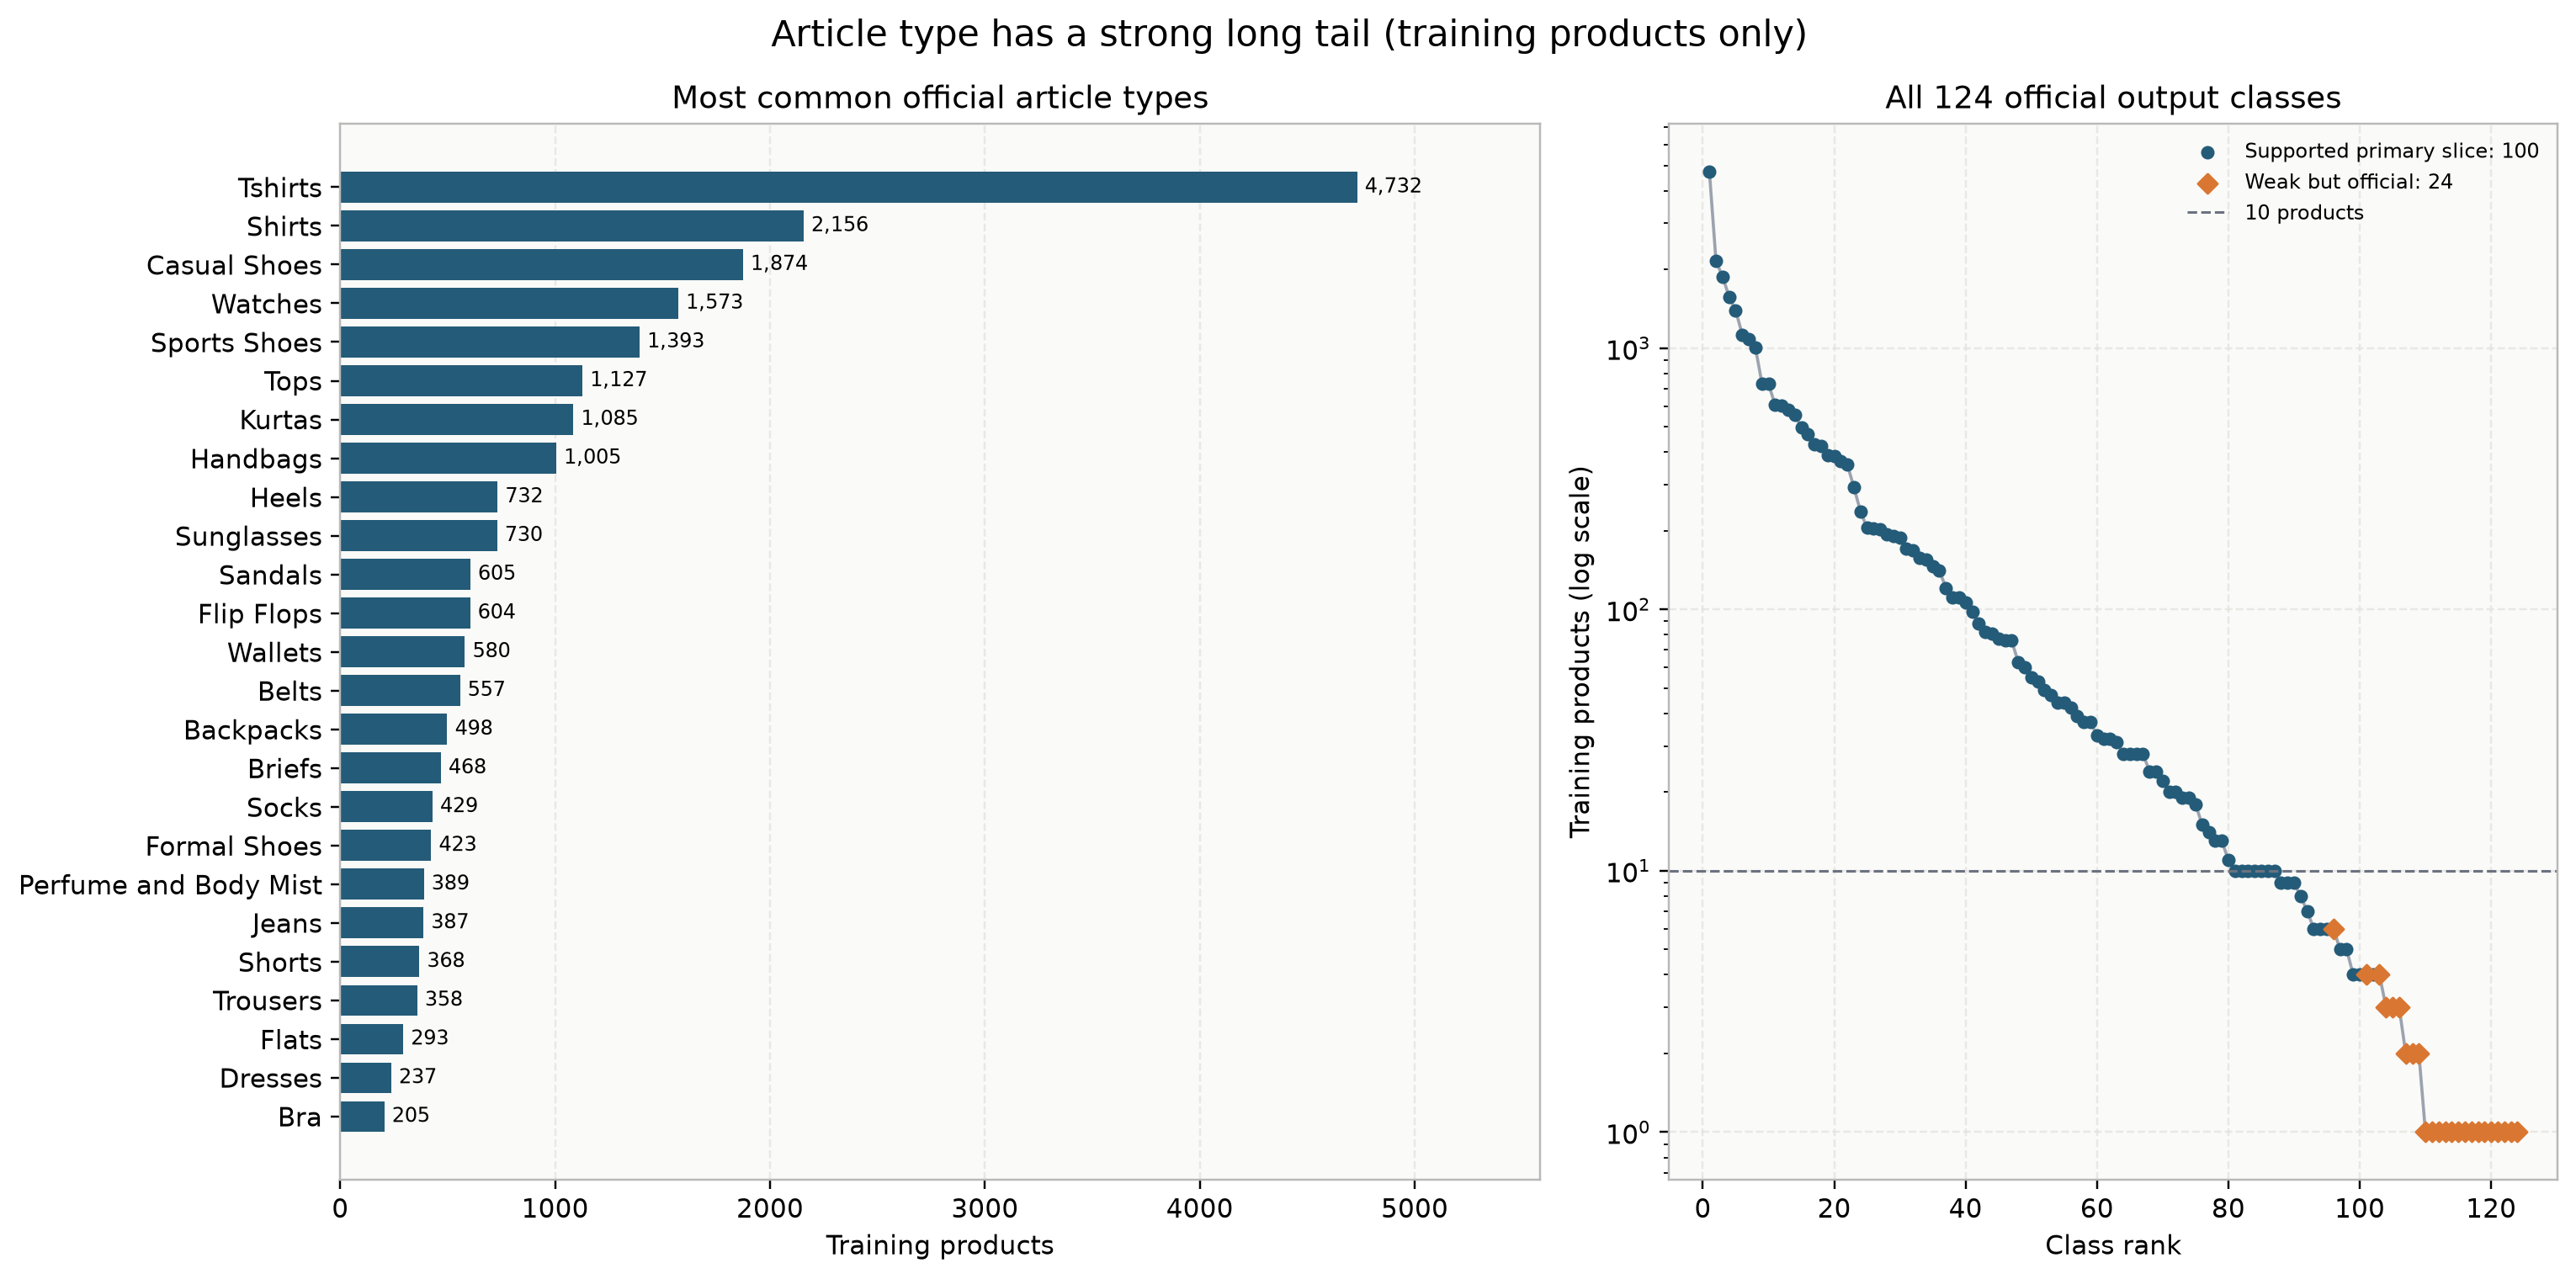


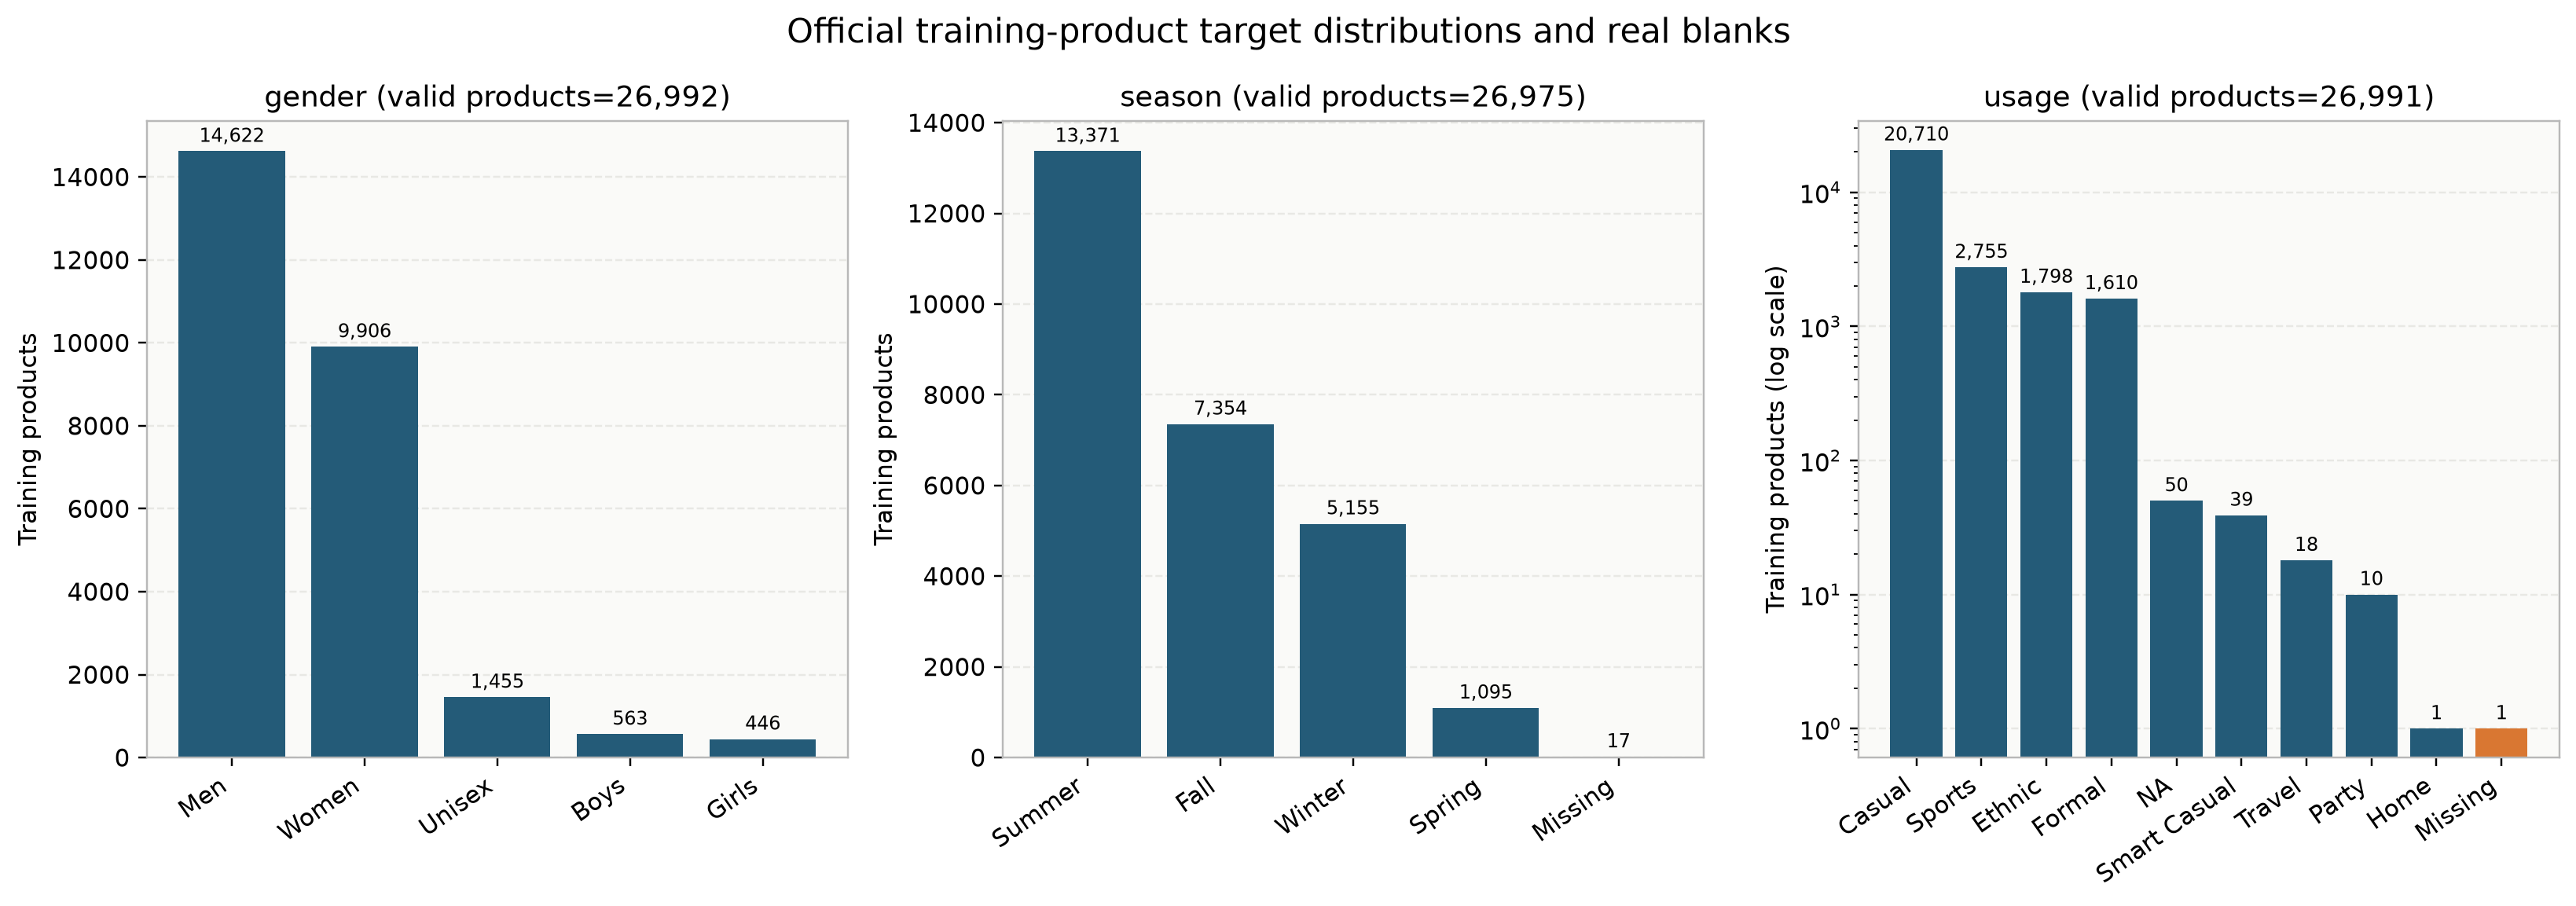


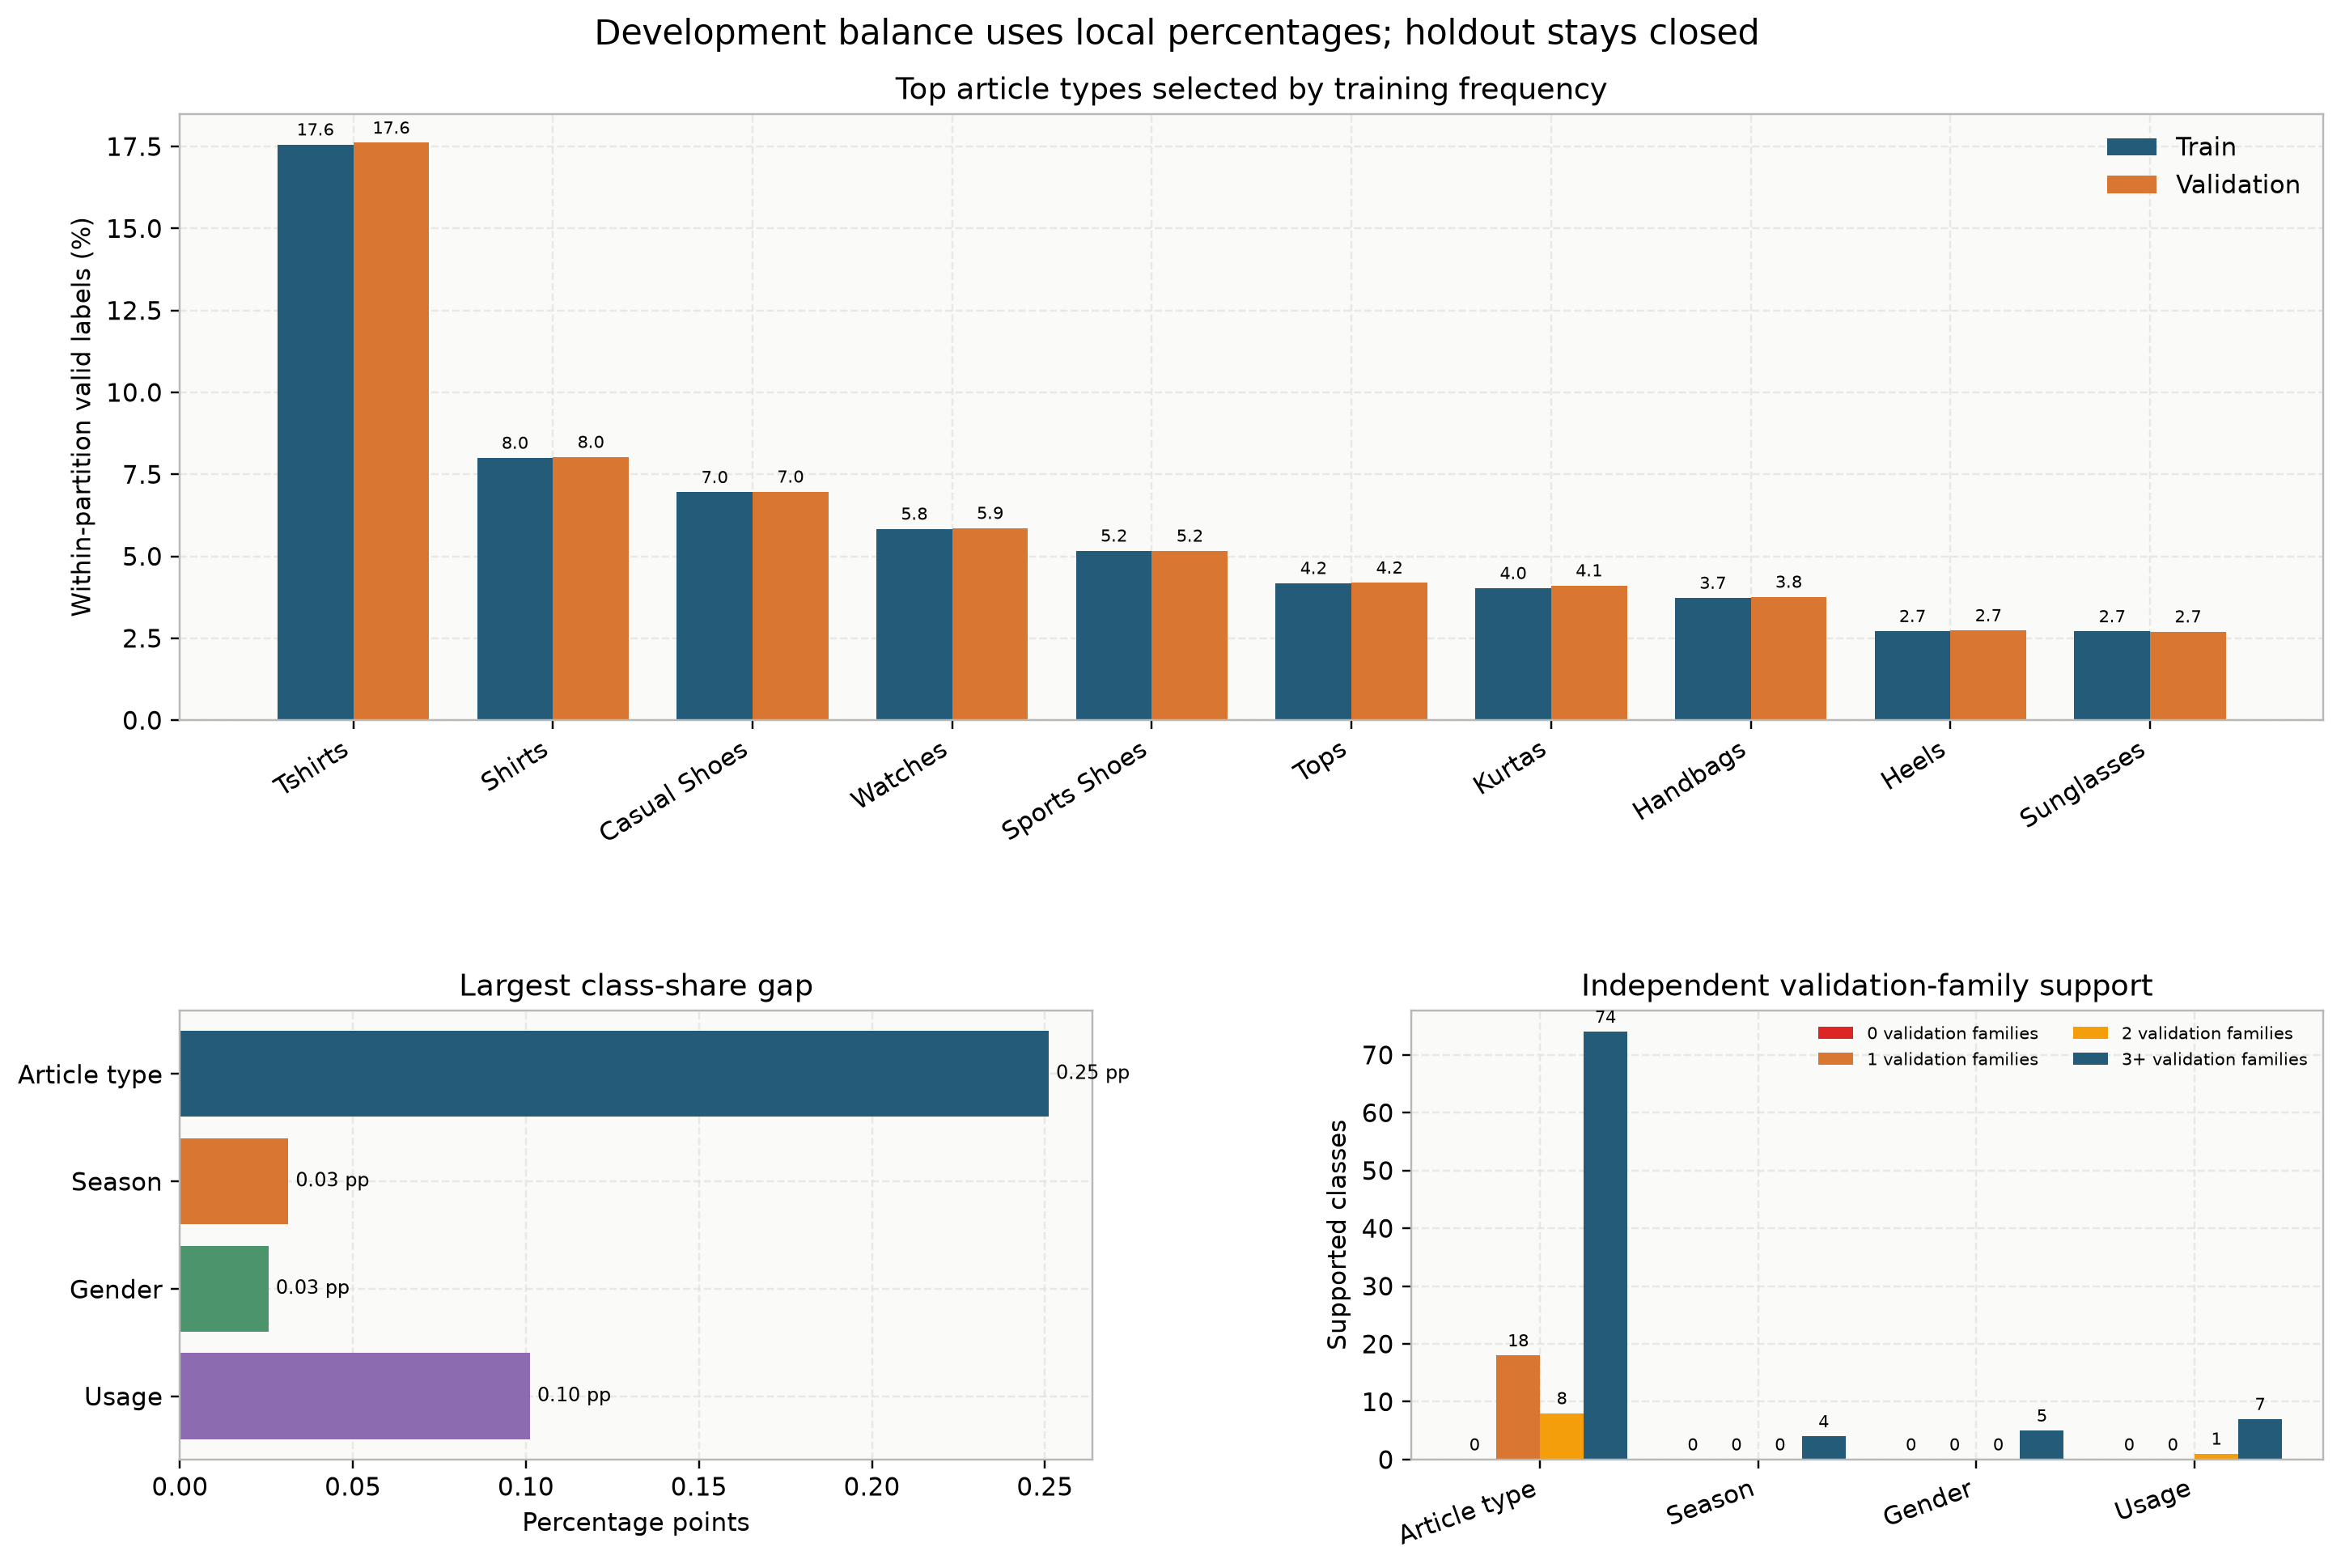

In [17]:
article_figure = plot_article_tail(train)
target_figure = plot_target_distributions(train)
balance_figure = plot_development_balance(splits, diagnostics)
taxonomy_display = taxonomy_summary.drop(columns="source").rename(
    columns={
        "official_output_classes": "official_outputs",
        "supported_primary_metric_classes": "primary_classes",
        "limited_but_still_official": "limited_classes",
        "validation_unknown_to_train": "val_unknown",
    }
)
validation_display = validation_summary.rename(
    columns={
        "train_valid": "train_products",
        "val_valid": "val_products",
        "classes_seen_in_val": "val_seen",
        "coverage_percent": "coverage_pct",
        "classes_with_one_val_family": "one_val_family",
        "classes_with_two_val_families": "two_val_families",
        "classes_with_fewer_than_three_val_families": "val_families_lt3",
        "missing_classes": "missing",
        "max_gap_percentage_points": "max_gap_pp",
        "mean_gap_percentage_points": "mean_gap_pp",
    }
).round({"coverage_pct": 2, "max_gap_pp": 3, "mean_gap_pp": 3})
target_display = target_summary.drop(columns="source_partition").rename(
    columns={
        "official_label_products": "official_rows",
        "missing_label_products": "missing_rows",
        "supported_primary_products": "primary_rows",
        "limited_official_products": "limited_rows",
        "most_common": "top_class",
        "most_common_count": "top_n",
        "classes_below_10": "classes_lt10",
    }
)
task_profile = taxonomy_display.merge(
    validation_display[
        [
            "target",
            "train_products",
            "val_products",
            "coverage_pct",
            "one_val_family",
            "two_val_families",
            "val_families_lt3",
            "max_gap_pp",
        ]
    ],
    on="target",
    validate="one_to_one",
).merge(
    target_display[
        ["target", "missing_rows", "limited_rows", "top_class", "top_n", "classes_lt10"]
    ],
    on="target",
    validate="one_to_one",
)
task_profile["dominant_share_pct"] = task_profile["top_n"] / task_profile["train_products"] * 100
task_profile = task_profile[
    [
        "target",
        "official_outputs",
        "primary_classes",
        "limited_classes",
        "missing_rows",
        "limited_rows",
        "train_products",
        "val_products",
        "one_val_family",
        "val_families_lt3",
        "top_class",
        "dominant_share_pct",
        "classes_lt10",
    ]
].round({"coverage_pct": 2, "dominant_share_pct": 1})
show_table(task_profile, "Task difficulty and fair-comparison profile")
show_figure(
    article_figure,
    (
        "Figure 4. Training-product article type counts show the frozen output classes. "
        "Orange marks explicitly account for weak train classes outside the primary slice."
    ),
)
show_figure(
    target_figure,
    (
        "Figure 5. Product-level training gender, season, and usage distributions keep literal "
        "NA separate from true blanks."
    ),
)
show_figure(
    balance_figure,
    (
        "Figure 6. Train-product and validation-product percentages use local "
        "denominators and the supported metric slice. Holdout stays closed."
    ),
)

> **Finding.** `articleType` has 124 official outputs, while 100 have at least three independent
> training families for the primary comparison. Thirteen supported classes still have fewer than ten
> training products. `usage` is highly concentrated: Casual accounts for 20,710 of 26,990 valid
> training products, or 76.7%. Validation contains every supported class, but that product-row view
> overstates certainty: 18 of 100 supported article types have one validation family, and 26 have
> fewer than three. One usage class has only two validation families. Missing labels and limited
> official classes are counted separately. The largest product-share gap is 0.251 percentage points.
> These are product-level statistics; the paired training loader
> still contains 53,984 image inputs. Figures 4–6 show the long tail, imbalance, and close development
> balance.
>
> **Modelling consequence.** Accuracy alone hides minority-class behaviour. Each task owner must choose and justify a
> class-aware primary and supporting metric set, including per-class errors and family support where
> useful. Thin validation classes carry wide uncertainty rather than strong claims. The owner compares
> an unmodified baseline with only the train-side imbalance options justified by task evidence.

### 4.2 Imbalance handoff to task owners

Shared data preparation diagnoses imbalance but does not apply one global treatment to four
different prediction targets. The common rules are fixed: calculate support on unique products,
keep both image variants at one total product weight, and never rebalance validation or holdout.

Each task notebook must compare an unmodified baseline with a small evidence-chosen set of
train-only options. Candidate options include a class-aware loss, a class-aware sampler, or another
documented method. The teammate records the final choice and its trade-offs after seeing baseline
errors. Table-data SMOTE is not applied to raw image pixels.

**Code step — Task-owned imbalance decision handoff.**

Combines train-only class support with candidate treatment families, fixed safety rules, and an explicit TODO for each task owner. It does not resample data or choose a final method.

In [18]:
imbalance_options = {
    "articleType": (
        "unmodified baseline; class-aware loss; focal-style loss; "
        "logit adjustment; class-aware train sampler"
    ),
    "season": (
        "unmodified baseline first; class-aware loss or train sampler only if "
        "minority errors justify it"
    ),
    "gender": (
        "unmodified baseline first; class-aware loss or train sampler only if "
        "minority errors justify it"
    ),
    "usage": (
        "unmodified baseline; class-aware loss; focal-style loss; "
        "logit adjustment; class-aware train sampler"
    ),
}
imbalance_rows = []
for row in task_profile.itertuples(index=False):
    if row.dominant_share_pct >= 70:
        signal = "high head-class concentration"
    elif row.classes_lt10 >= 10:
        signal = "strong long tail"
    elif row.dominant_share_pct >= 40:
        signal = "moderate head-class concentration"
    else:
        signal = "lower concentration; inspect per-class errors"
    imbalance_rows.append(
        {
            "target": row.target,
            "train_products": int(row.train_products),
            "official_outputs": int(row.official_outputs),
            "supported_comparison_classes": int(row.primary_classes),
            "limited_official_classes": int(row.limited_classes),
            "classes_below_10_products": int(row.classes_lt10),
            "dominant_class_share_percent": float(row.dominant_share_pct),
            "imbalance_signal": signal,
            "candidate_train_only_options": imbalance_options[row.target],
            "task_owner_decision": "TODO in task notebook after baseline evidence",
            "validation_holdout_policy": "never resample or rebalance",
            "paired_variant_rule": "two image rows keep one total product weight",
            "raw_pixel_smote": "not used",
        }
    )
imbalance_handoff = pd.DataFrame(imbalance_rows)
save_csv(imbalance_handoff, "imbalance_handoff.csv")
show_table(
    imbalance_handoff[
        [
            "target",
            "official_outputs",
            "classes_below_10_products",
            "dominant_class_share_percent",
            "imbalance_signal",
            "candidate_train_only_options",
            "task_owner_decision",
        ]
    ],
    "Imbalance evidence, candidate options, and task-owner TODOs",
)

,target,official_outputs,classes_below_10_products,dominant_class_share_percent,imbalance_signal,candidate_train_only_options,task_owner_decision
0,articleType,124,13,17.600,strong long tail,unmodified baseline; class-aware loss; focal-style loss; logit adjustment; class-aware train sampler,TODO in task notebook after baseline evidence
1,season,4,0,49.600,moderate head-class concentration,unmodified baseline first; class-aware loss or train sampler only if minority errors justify it,TODO in task notebook after baseline evidence
2,gender,5,0,54.200,moderate head-class concentration,unmodified baseline first; class-aware loss or train sampler only if minority errors justify it,TODO in task notebook after baseline evidence
3,usage,9,0,76.700,high head-class concentration,unmodified baseline; class-aware loss; focal-style loss; logit adjustment; class-aware train sampler,TODO in task notebook after baseline evidence


> **Finding.** Imbalance is not one shared problem with one shared fix. `articleType` has a
> long tail, while `usage` is dominated by one head class. Season and gender require their own
> per-class error evidence before adding treatment complexity. The handoff table keeps diagnosis,
> candidate options, and the unanswered teammate decision separate.
>
> **Modelling consequence.** No common preprocessing step resamples products or manufactures image
> pixels. Each task owner first records a baseline, chooses the metric set, compares only justified
> train-side options under the same budget, and explains both minority gains and head-class losses.
> Validation and holdout remain untouched.

## 5. Target relationships and bias

The multivariate analysis measures shared information between targets and tests whether catalogue
hierarchy, product naming, or dominant label combinations could create misleading shortcuts.

**Code step — Relationship metrics and summaries.**

Defines normalized mutual information, hierarchy summaries, season-family summaries, and readable heat-map labels.

In [19]:
# Target relationship, hierarchy, ambiguity, and bias evidence


def normalized_mutual_information(first: pd.Series, second: pd.Series) -> float:
    table = pd.crosstab(first, second).to_numpy(dtype=float)
    if table.size == 0 or table.sum() == 0:
        return 0.0
    probability = table / table.sum()
    row_probability = probability.sum(axis=1, keepdims=True)
    column_probability = probability.sum(axis=0, keepdims=True)
    expected = row_probability @ column_probability
    valid = probability > 0
    information = float((probability[valid] * np.log(probability[valid] / expected[valid])).sum())
    row_entropy = float(
        -(row_probability[row_probability > 0] * np.log(row_probability[row_probability > 0])).sum()
    )
    column_entropy = float(
        -(
            column_probability[column_probability > 0]
            * np.log(column_probability[column_probability > 0])
        ).sum()
    )
    denominator = row_entropy + column_entropy
    return 0.0 if denominator == 0 else 2 * information / denominator


def hierarchy_summary(train_frame: pd.DataFrame) -> pd.DataFrame:
    rows = train_frame[bool_mask(train_frame["has_articleType_supported_label"])]
    return (
        rows.groupby("articleType_supported", sort=True)
        .agg(
            train_products=("id", "size"),
            master_category_count=("masterCategory", "nunique"),
            sub_category_count=("subCategory", "nunique"),
            master_categories=("masterCategory", lambda x: "; ".join(sorted(set(x)))),
            sub_categories=("subCategory", lambda x: "; ".join(sorted(set(x)))),
        )
        .reset_index()
        .rename(columns={"articleType_supported": "article_type"})
    )


def season_family_summary(train_frame: pd.DataFrame) -> pd.DataFrame:
    valid = train_frame[bool_mask(train_frame["has_season_supported_label"])]
    grouped = valid.groupby("product_family_group").agg(
        rows=("id", "size"),
        seasons=("season_supported", "nunique"),
        family_group_basis=("family_group_basis", "first"),
    )
    rows = []
    for basis, groups in grouped[grouped["rows"].gt(1)].groupby("family_group_basis", sort=True):
        basis_text = str(basis)
        name_involved = "normalized_product_name" in basis_text
        visual_only = not name_involved and any(
            token in basis_text for token in ("exact_sha256", "accepted_near_duplicate")
        )
        rows.append(
            {
                "family_group_basis": basis_text,
                "multirow_train_groups": len(groups),
                "mixed_season_train_groups": int(groups["seasons"].gt(1).sum()),
                "name_block_involved": name_involved,
                "eligible_as_label_ambiguity_signal": visual_only,
                "interpretation": (
                    "possible visual-family ambiguity; EDA does not relabel it"
                    if visual_only
                    else "name blocking may be broad; this cannot prove label noise"
                ),
            }
        )
    columns = [
        "family_group_basis",
        "multirow_train_groups",
        "mixed_season_train_groups",
        "name_block_involved",
        "eligible_as_label_ambiguity_signal",
        "interpretation",
    ]
    return pd.DataFrame(rows, columns=columns)


def text_colour(image: Any, value: float) -> str:
    red, green, blue, _ = image.cmap(image.norm(float(value)))
    luminance = 0.2126 * red + 0.7152 * green + 0.0722 * blue
    return "white" if luminance < 0.52 else "#111827"

**Code step — Joint-target plot.**

Defines the joint-target figure combining off-diagonal mutual information with season mixtures inside common article types.

In [20]:
def plot_joint_relationships(train_frame: pd.DataFrame, matrix: pd.DataFrame) -> Path:
    article_mask = bool_mask(train_frame["has_articleType_supported_label"]) & bool_mask(
        train_frame["has_season_supported_label"]
    )
    top_articles = (
        train_frame.loc[article_mask, "articleType_supported"].value_counts().head(12).index
    )
    season = pd.crosstab(
        train_frame.loc[
            article_mask & train_frame["articleType_supported"].isin(top_articles),
            "articleType_supported",
        ],
        train_frame.loc[
            article_mask & train_frame["articleType_supported"].isin(top_articles),
            "season_supported",
        ],
        normalize="index",
    ).reindex(top_articles)
    fig, (left, right) = plt.subplots(
        1, 2, figsize=(13, 6), gridspec_kw={"width_ratios": [0.8, 1.4]}
    )
    display_matrix = matrix.to_numpy(dtype=float).copy()
    np.fill_diagonal(display_matrix, np.nan)
    off_diagonal = display_matrix[np.isfinite(display_matrix)]
    upper = max(float(off_diagonal.max()) if len(off_diagonal) else 0.0, 0.01)
    colour_map = plt.get_cmap("Blues").with_extremes(bad="#E5E7EB")
    heat = left.imshow(display_matrix, vmin=0, vmax=upper, cmap=colour_map)
    left.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=35, ha="right")
    left.set_yticks(range(len(matrix.index)), matrix.index)
    left.set_title("Off-diagonal normalized mutual information")
    for row in range(len(matrix.index)):
        for column in range(len(matrix.columns)):
            if row == column:
                left.text(column, row, "self", ha="center", va="center", color="#4B5563")
                continue
            value = matrix.iloc[row, column]
            left.text(
                column,
                row,
                f"{value:.2f}",
                ha="center",
                va="center",
                color=text_colour(heat, value),
            )
    colour_bar = fig.colorbar(heat, ax=left, fraction=0.046, pad=0.04)
    colour_bar.set_label("Off-diagonal NMI")
    if season.empty:
        right.axis("off")
        right.text(0.5, 0.5, "Too few classes for a season mixture", ha="center")
    else:
        season_image = right.imshow(season.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="YlOrBr")
        right.set_yticks(range(len(season.index)), season.index)
        right.set_xticks(range(len(season.columns)), season.columns, rotation=35, ha="right")
        right.set_title("Season mix inside common article types")
        for row in range(len(season.index)):
            for column in range(len(season.columns)):
                value = season.iloc[row, column]
                right.text(
                    column,
                    row,
                    f"{value:.0%}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color=text_colour(season_image, value),
                )
        fig.colorbar(season_image, ax=right, fraction=0.046, pad=0.04)
    fig.suptitle("Targets are related, but one target does not replace another (train only)")
    fig.tight_layout()
    return save_figure(fig, "joint_target_relationships.png")

**Code step — Hierarchy and season plots.**

Defines separate figures for catalogue hierarchy overlap and mixed-season family review leads.

In [21]:
def plot_hierarchy(train_frame: pd.DataFrame, summary: pd.DataFrame) -> Path:
    valid = train_frame[bool_mask(train_frame["has_articleType_supported_label"])]
    top_parents = (
        valid.groupby("subCategory")["articleType_supported"].nunique().sort_values().tail(12)
    )
    sub_cross = summary[summary["sub_category_count"].gt(1)]
    master_cross = summary[summary["master_category_count"].gt(1)]
    fig, (left, right) = plt.subplots(1, 2, figsize=(14, 5.8))
    bars = left.barh(top_parents.index.astype(str), top_parents.values, color=PALETTE[0])
    left.set_xlabel("Supported article types")
    left.set_title("Broad parents contain competing classes")
    left.bar_label(bars, padding=3)
    total = len(summary)
    positions = np.arange(2)
    one = [total - len(sub_cross), total - len(master_cross)]
    many = [len(sub_cross), len(master_cross)]
    right.bar(positions, one, color="#7599AA", label="one parent")
    right.bar(positions, many, bottom=one, color=PALETTE[1], label="more than one")
    right.set_xticks(positions, ["Subcategory", "Master category"])
    right.set_ylabel("Supported article types")
    right.set_title("The metadata hierarchy is not strict")
    right.legend(
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=2,
    )
    fig.suptitle("Hierarchy supports error slices, not automatic relabelling")
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    return save_figure(fig, "hierarchy_overlap.png")


def plot_season_ambiguity(summary: pd.DataFrame) -> Path:
    mixed = summary[summary["mixed_season_train_groups"].gt(0)].copy()
    fig, axis = plt.subplots(figsize=(12, 5.8))
    if mixed.empty:
        axis.axis("off")
        axis.text(
            0.5,
            0.55,
            "No mixed-season multi-row train family in this fixture",
            ha="center",
            fontsize=12,
        )
    else:
        label_map = {
            "accepted_near_duplicate": "visual near only",
            "exact_sha256+accepted_near_duplicate": "exact + near",
            "exact_sha256+normalized_product_name+accepted_near_duplicate": "exact + name + near",
            "normalized_product_name": "name only",
            "normalized_product_name+accepted_near_duplicate": "name + near",
        }
        labels = mixed["family_group_basis"].map(
            lambda value: label_map.get(str(value), str(value).replace("_", " "))
        )
        values = mixed["mixed_season_train_groups"].astype(int)
        colors = [
            PALETTE[1] if flag else "#7599AA"
            for flag in mixed["eligible_as_label_ambiguity_signal"]
        ]
        bars = axis.bar(labels, values, color=colors)
        if values.max() / max(values.min(), 1) > 20:
            axis.set_yscale("log")
            axis.set_ylabel("Mixed groups (log scale)")
        else:
            axis.set_ylabel("Mixed groups")
        axis.bar_label(bars, labels=[f"{value:,}" for value in values], padding=3)
        axis.tick_params(axis="x", rotation=15)
        for label in axis.get_xticklabels():
            label.set_ha("right")
    axis.set_title("Observed mixed-season train families, split by evidence basis")
    fig.suptitle("These groups are review leads, not a season-label error-rate estimate")
    fig.text(
        0.5,
        0.01,
        (
            "A single visual pair cannot support a general claim; "
            "name-only blocks are especially broad."
        ),
        ha="center",
        fontsize=9,
    )
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    return save_figure(fig, "season_ambiguity.png")

**Code step — Bias-risk plot.**

Defines the usage-by-gender and article-type concentration figure plus the compact bias evidence table.

In [22]:
def plot_bias(train_frame: pd.DataFrame) -> tuple[Path, pd.DataFrame]:
    mask = bool_mask(train_frame["has_gender_supported_label"]) & bool_mask(
        train_frame["has_usage_supported_label"]
    )
    count_table = pd.crosstab(
        train_frame.loc[mask, "usage_supported"],
        train_frame.loc[mask, "gender_supported"],
    )
    table = count_table.div(count_table.sum(axis=1), axis=0)
    article_mask = bool_mask(train_frame["has_articleType_supported_label"]) & bool_mask(
        train_frame["has_gender_supported_label"]
    )
    article_gender = pd.crosstab(
        train_frame.loc[article_mask, "articleType_supported"],
        train_frame.loc[article_mask, "gender_supported"],
        normalize="index",
    )
    support = train_frame.loc[article_mask, "articleType_supported"].value_counts()
    eligible = support[support.ge(20)].index
    concentration = article_gender.reindex(eligible).dropna(how="all").max(axis=1)
    fig, (left, right) = plt.subplots(1, 2, figsize=(13, 5.8))
    if table.empty:
        left.axis("off")
        left.text(0.5, 0.5, "Too few rows for a usage/gender slice", ha="center")
    else:
        image = left.imshow(table.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="Purples")
        left.set_yticks(range(len(table.index)), table.index)
        left.set_xticks(range(len(table.columns)), table.columns, rotation=35, ha="right")
        left.set_title("Gender-label share within usage")
        for row in range(len(table.index)):
            for column in range(len(table.columns)):
                value = table.iloc[row, column]
                support_n = int(count_table.iloc[row, column])
                left.text(
                    column,
                    row,
                    f"{value:.0%}\nn={support_n:,}",
                    ha="center",
                    va="center",
                    fontsize=6.5,
                    color=text_colour(image, value),
                )
        fig.colorbar(image, ax=left, fraction=0.046, pad=0.04)
    if concentration.empty:
        right.axis("off")
        right.text(0.5, 0.5, "No article type has 20 train rows in this fixture", ha="center")
    else:
        right.hist(concentration, bins=np.linspace(0, 1, 11), color=PALETTE[3], edgecolor="white")
        right.set_xlabel("Largest gender-label share in article type")
        right.set_ylabel("Article types with at least 20 rows")
    right.set_title("Item classes can be strongly gender-coded")
    fig.suptitle("Bias risk: catalogue labels can copy stereotypes; they do not identify a person")
    fig.tight_layout()
    evidence = pd.DataFrame(
        [
            {
                "source_partition": "train",
                "article_types_with_at_least_20_rows": len(concentration),
                "median_largest_gender_share": float(concentration.median())
                if len(concentration)
                else np.nan,
                "article_types_at_or_above_90_percent": int(concentration.ge(0.9).sum())
                if len(concentration)
                else 0,
                "decision": "report gender and usage slices plus qualitative failures",
            }
        ]
    )
    return save_figure(fig, "bias_risk.png"), evidence

**Code step — Relationship and bias results.**

Computes the train-only relationship evidence, saves the risk tables, and displays Figures 6 to 9 with the matching modelling actions.

,risk,evidence,modelling_action
0,targets can share shortcuts,strongest NMI is 0.255: articleType vs usage,compare separate and shared representations; score each target
1,season is not always visually stable,1 mixed-season visual families from 95,show qualitative errors; do not relabel from image evidence alone
2,gender can be a catalogue shortcut,27 of 72 common article types are at least 90% one gender label,report gender and usage slices; never treat gender as identity



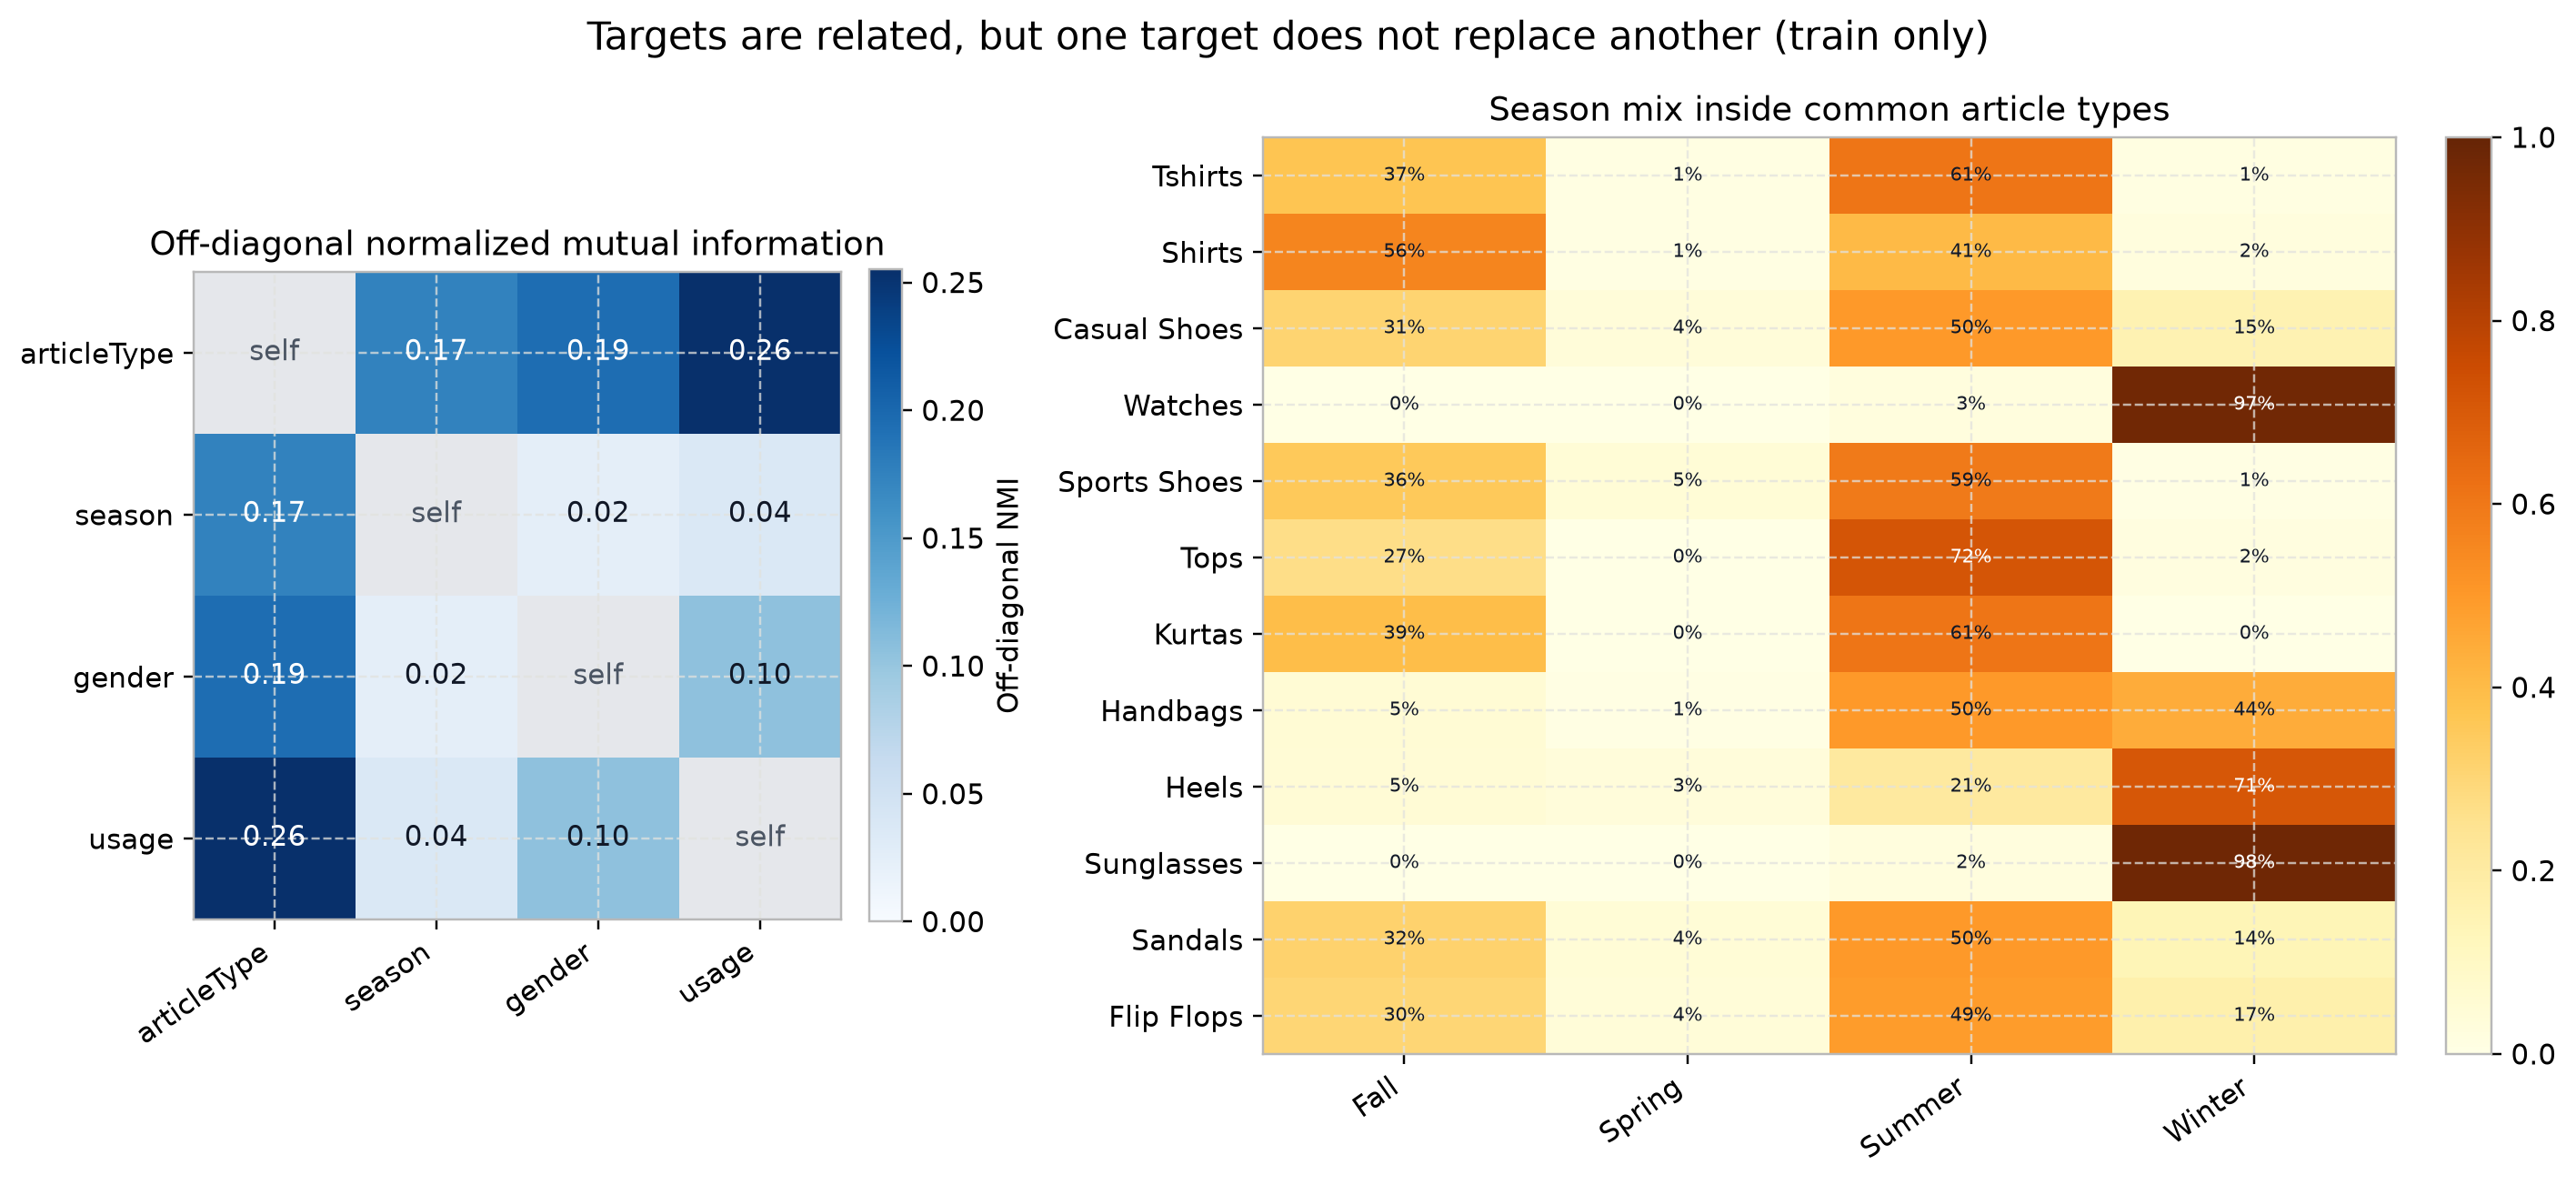


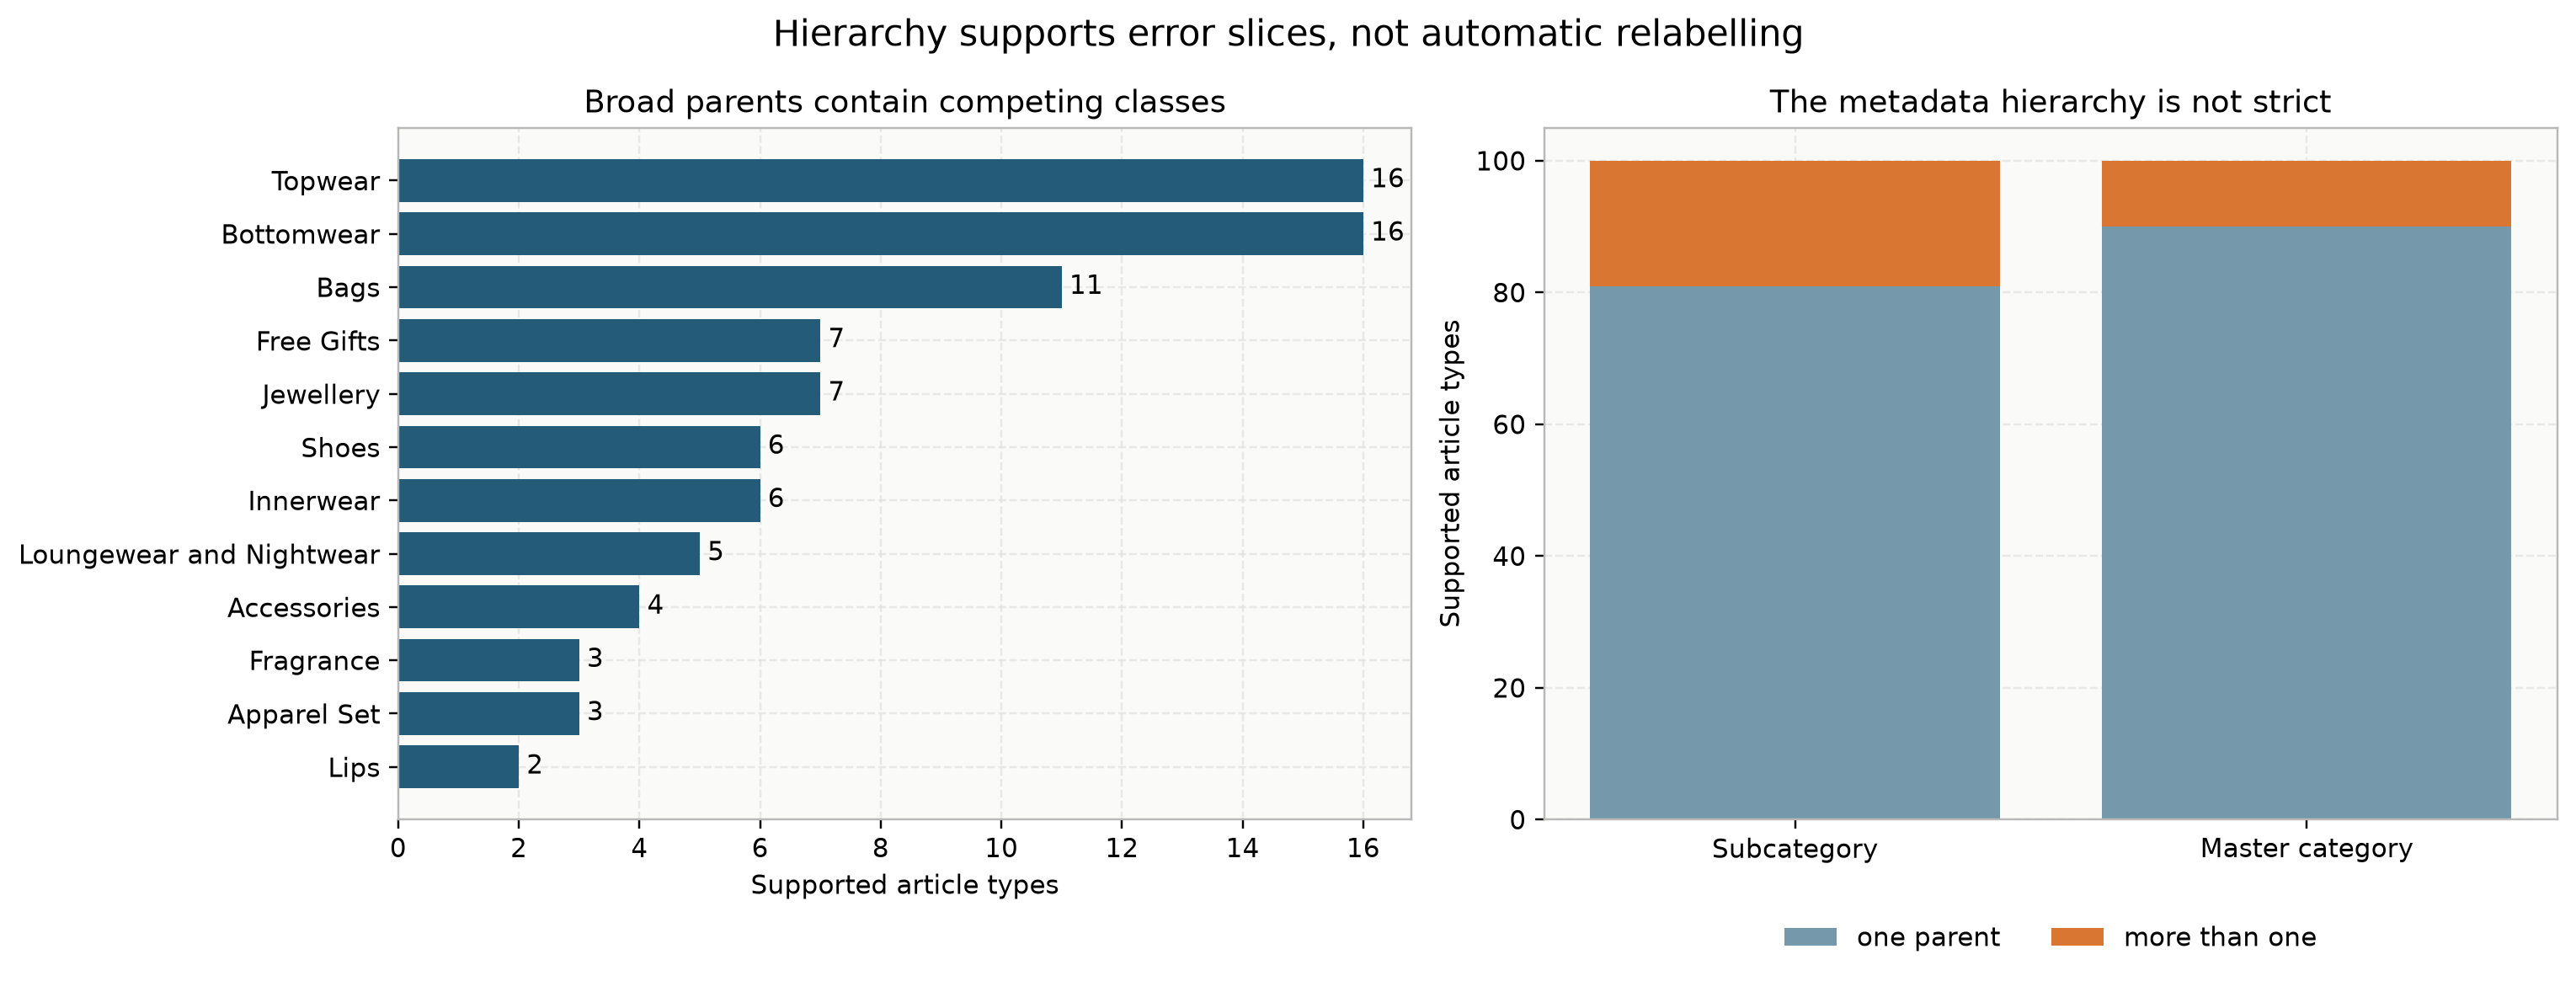


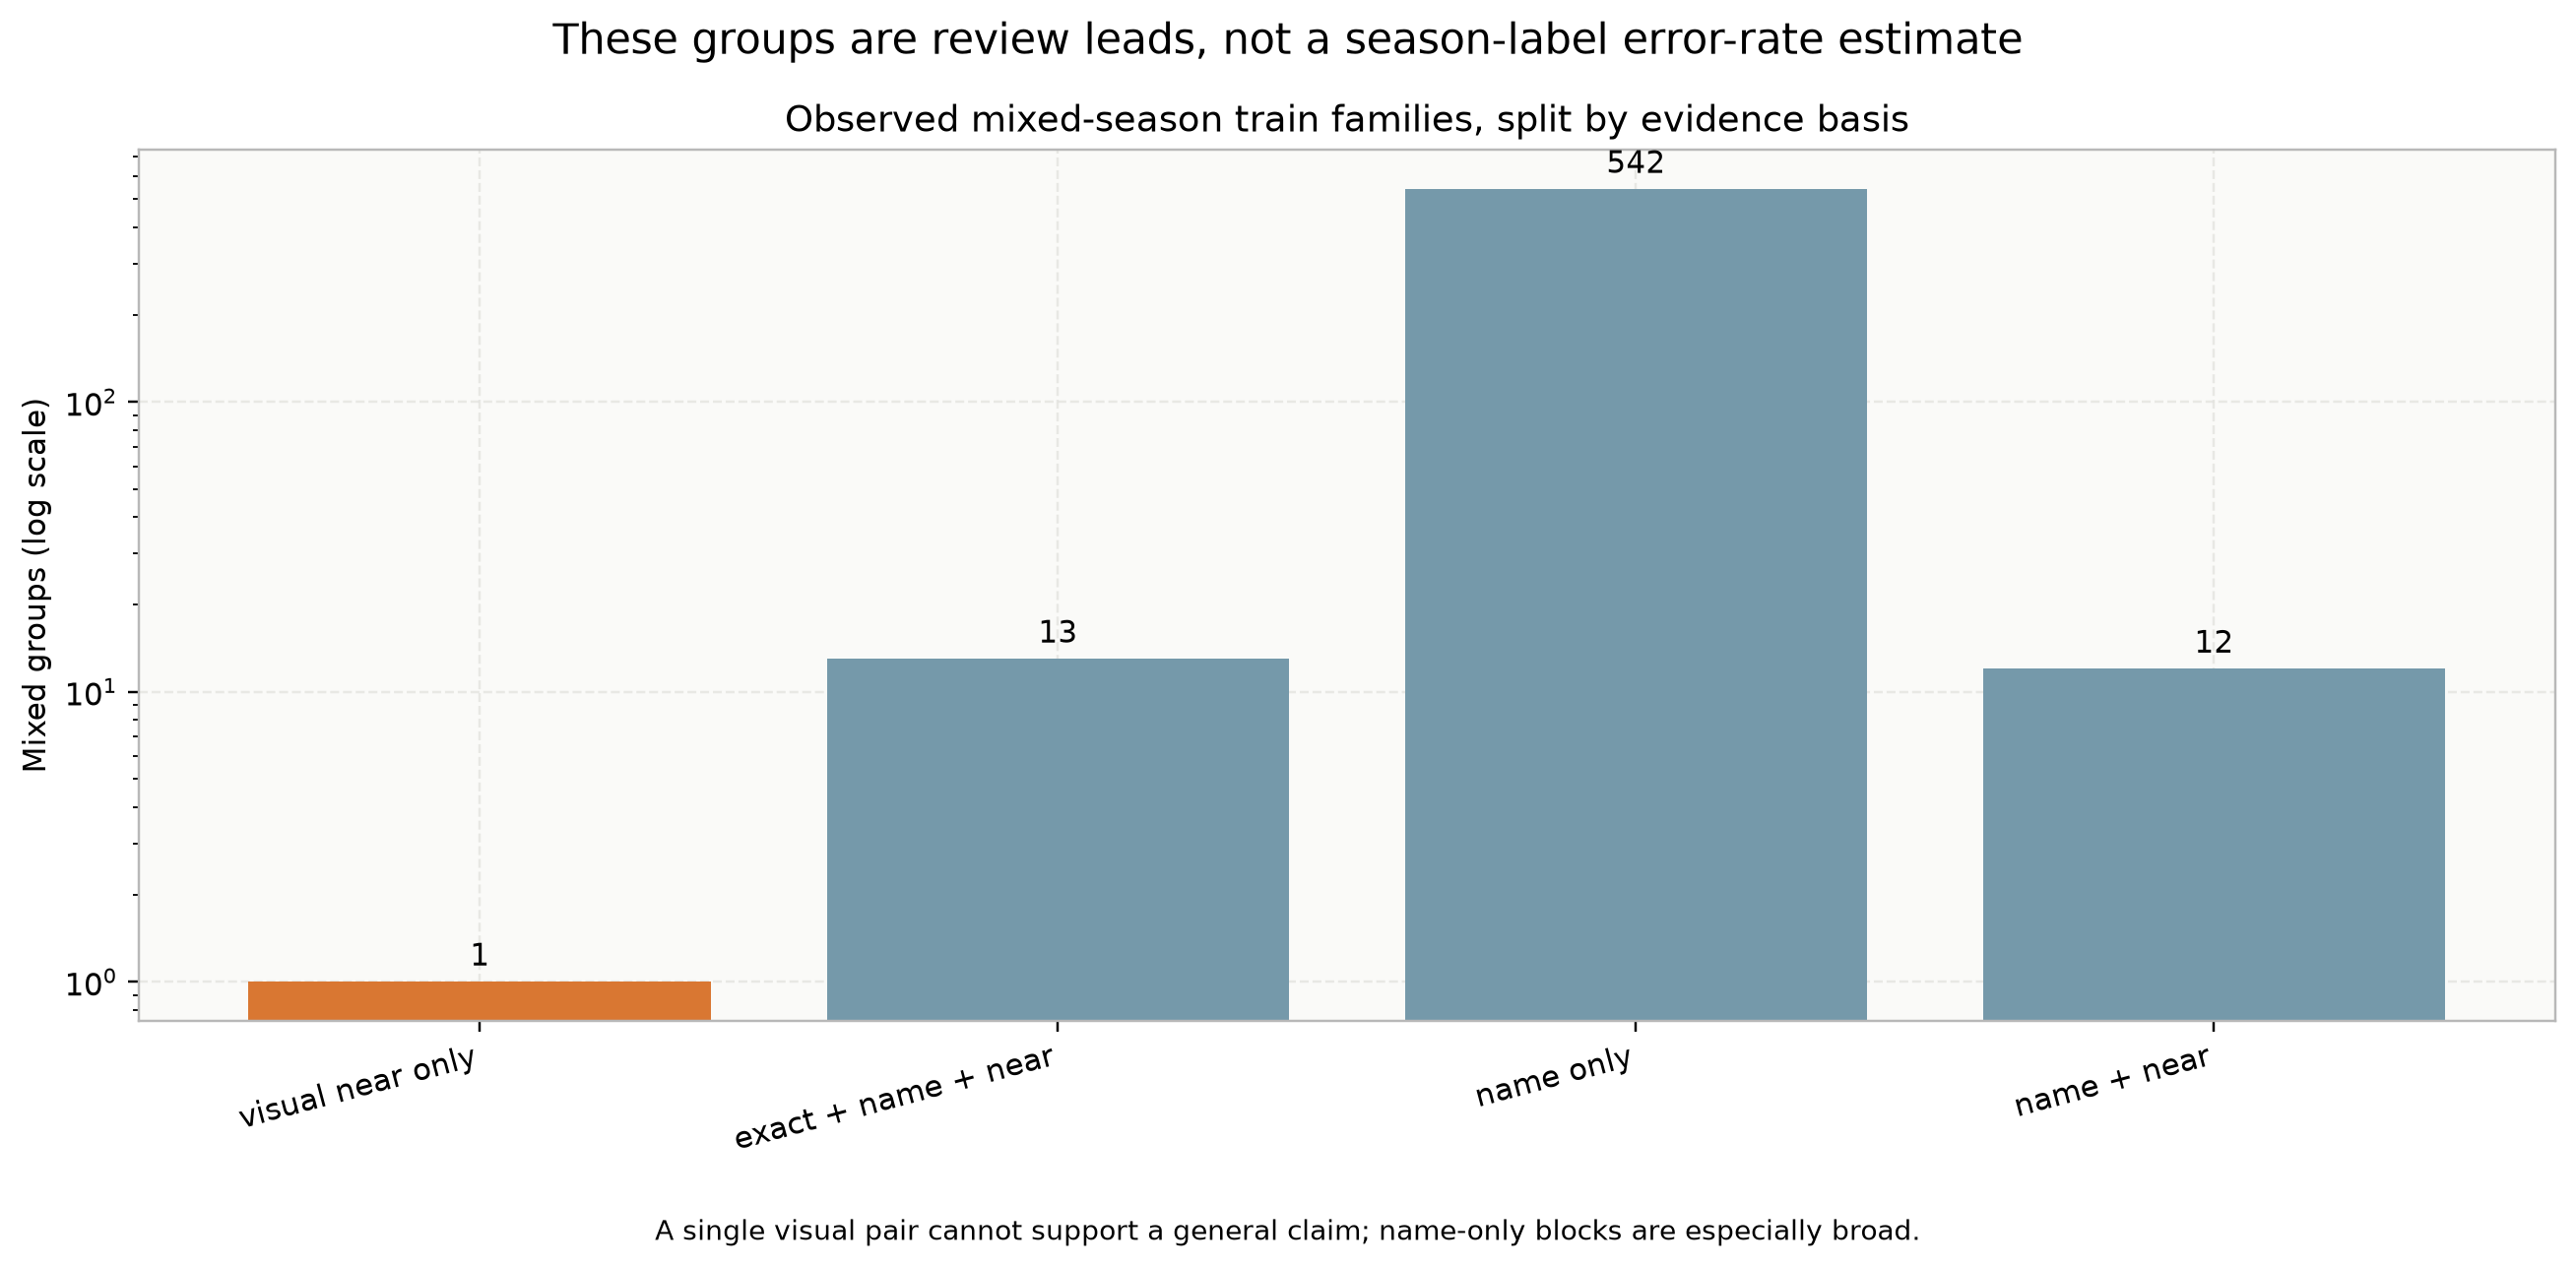


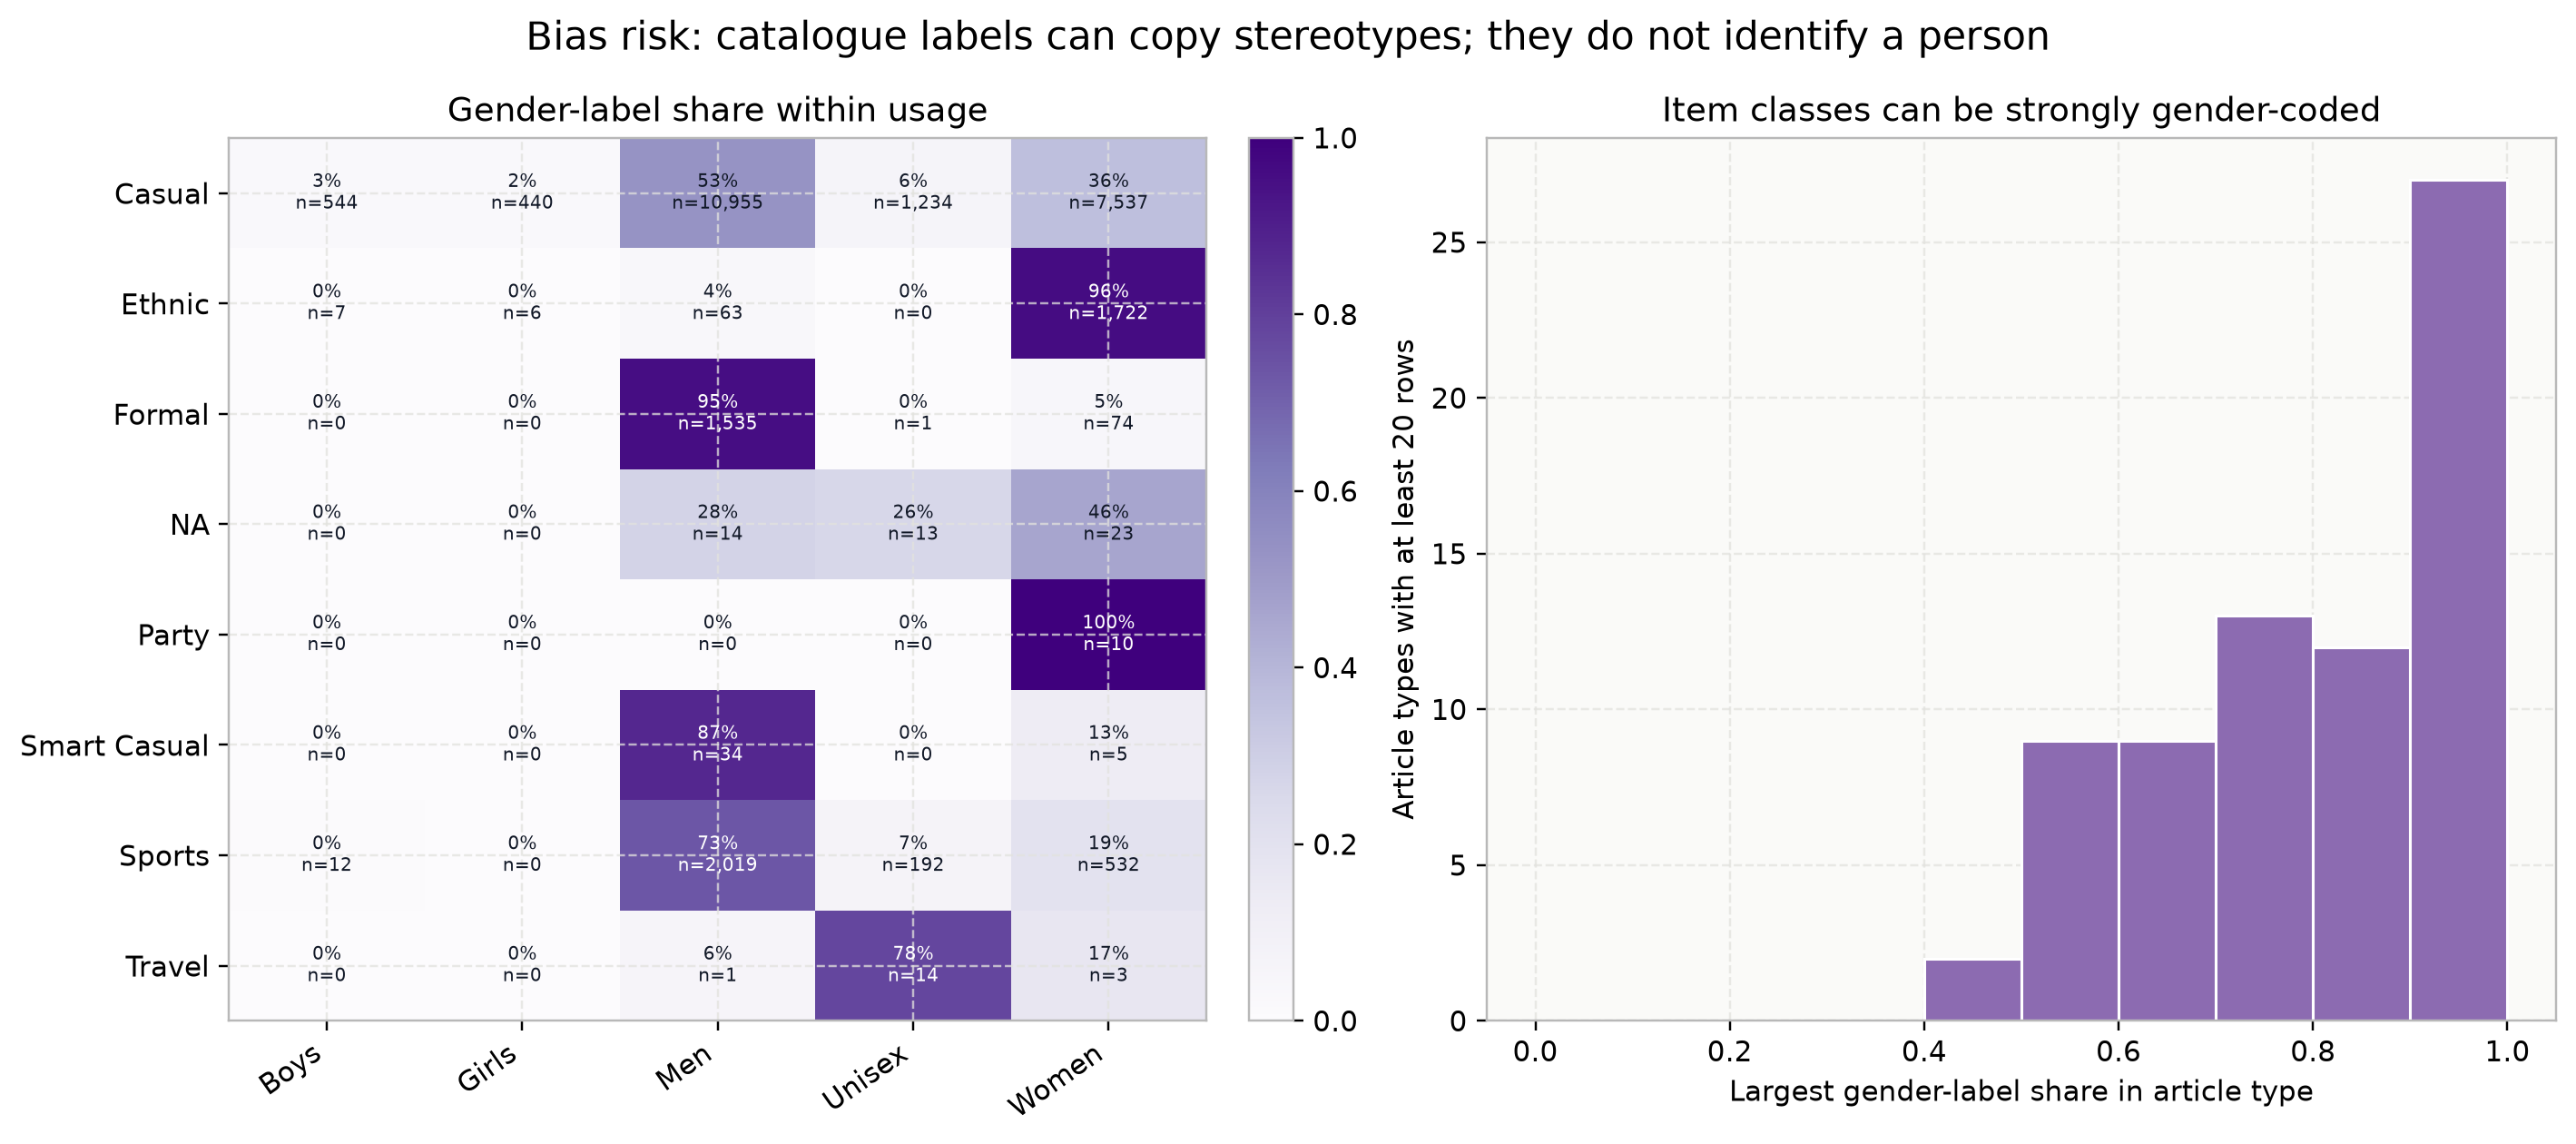

In [23]:
nmi = pd.DataFrame(np.eye(len(TARGET_COLUMNS)), index=TARGET_COLUMNS, columns=TARGET_COLUMNS)
for first_index, first in enumerate(TARGET_COLUMNS):
    for second_index, second in enumerate(TARGET_COLUMNS):
        if second_index <= first_index:
            continue
        mask = bool_mask(train[f"has_{first}_supported_label"]) & bool_mask(
            train[f"has_{second}_supported_label"]
        )
        value = normalized_mutual_information(
            train.loc[mask, f"{first}_supported"],
            train.loc[mask, f"{second}_supported"],
        )
        nmi.iloc[first_index, second_index] = value
        nmi.iloc[second_index, first_index] = value

hierarchy = hierarchy_summary(train)
season_families = season_family_summary(train)
save_csv(nmi.reset_index(names="target"), "joint_target_nmi.csv")
save_csv(hierarchy, "hierarchy_summary.csv")
save_csv(season_families, "season_family_basis_summary.csv")

joint_figure = plot_joint_relationships(train, nmi)
hierarchy_figure = plot_hierarchy(train, hierarchy)
season_figure = plot_season_ambiguity(season_families)
bias_figure, bias_summary = plot_bias(train)
save_csv(bias_summary, "bias_summary.csv")

association_pairs = [
    (first, second, float(nmi.loc[first, second]))
    for first_index, first in enumerate(TARGET_COLUMNS)
    for second in TARGET_COLUMNS[first_index + 1 :]
]
strongest_first, strongest_second, strongest_nmi = max(
    association_pairs, key=lambda record: record[2]
)
visual_family_rows = season_families[
    season_families["eligible_as_label_ambiguity_signal"].astype(bool)
]
risk_to_action = pd.DataFrame(
    [
        {
            "risk": "targets can share shortcuts",
            "evidence": (
                f"strongest NMI is {strongest_nmi:.3f}: {strongest_first} vs {strongest_second}"
            ),
            "modelling_action": "compare separate and shared representations; score each target",
        },
        {
            "risk": "season is not always visually stable",
            "evidence": (
                f"{int(visual_family_rows['mixed_season_train_groups'].sum())} mixed-season "
                f"visual families from {int(visual_family_rows['multirow_train_groups'].sum())}"
            ),
            "modelling_action": "show qualitative errors; do not relabel from image evidence alone",
        },
        {
            "risk": "gender can be a catalogue shortcut",
            "evidence": (
                f"{int(bias_summary.iloc[0]['article_types_at_or_above_90_percent'])} of "
                f"{int(bias_summary.iloc[0]['article_types_with_at_least_20_rows'])} common "
                "article types are at least 90% one gender label"
            ),
            "modelling_action": "report gender and usage slices; never treat gender as identity",
        },
    ]
)
show_table(risk_to_action, "Observed risk, evidence, and required modelling response")
show_figure(
    joint_figure,
    (
        "Figure 7. Training-only normalized mutual information and season mixtures show "
        "related but distinct prediction targets."
    ),
)
show_figure(
    hierarchy_figure,
    (
        "Figure 8. Catalogue parents contain multiple article types and some article types "
        "cross parents, so hierarchy is an error slice rather than an automatic merge."
    ),
)
show_figure(
    season_figure,
    (
        "Figure 9. Mixed-season training families are separated by evidence basis. "
        "These counts are review leads only; one visual pair cannot support a general "
        "error-rate claim."
    ),
)
show_figure(
    bias_figure,
    (
        "Figure 10. Training-only usage and gender-label associations reveal shortcut and "
        "stereotype risk that later evaluation must report."
    ),
)

> **Finding.** The strongest target link is moderate: `articleType` versus `usage` has NMI 0.255.
> Season is weakly linked to the other targets, consistent with its limited visual signal. Catalogue
> hierarchy is not one-to-one, so parent labels cannot safely merge article types. Only one of 30
> multi-row families based purely on accepted visual similarity mixes seasons; larger mixed counts
> from normalized names are triage leads rather than proof of bad labels. Shortcut risk remains
> material: 27 of 72 common article types are at least 90% one gender label. Figures 6–9 show these
> relationships and risks.
>
> **Modelling consequence.** The system keeps four explicit outputs. Separate models and a shared
> representation are compared under the same budget. Evaluation includes target-specific errors,
> hierarchy slices, season examples, and gender/usage shortcut slices. Gender remains a catalogue
> label and is not interpreted as a person's identity.

## 6. Image data quality and preprocessing

Image analysis covers objective file quality, source geometry, paired-resolution coverage, alignment
risk, and the cost of the proposed tensor representation. Unlike target EDA, this section reports the
actual doubled image-input volume as well as the unique product count. These checks define preprocessing without
claiming an unmeasured model gain.

### 6.1 Image quality and resolution variants

The source-image profile identifies safe decoding repairs and verifies that the high-resolution
collection represents the same model products without admitting official prediction IDs.

**Code step — Image profile and quality plots.**

Defines the original-resolution source profile and objective quality-exception figures. This audit covers 26,992 original files, which are one half of the 53,984 training image inputs.

In [24]:
# Image profile, quality, and low/high alignment evidence


def plot_image_profile(train_images: pd.DataFrame) -> Path:
    resolutions = train_images.groupby(["width", "height"]).size().sort_values()
    resolution_labels = [f"{int(w)}x{int(h)}" for w, h in resolutions.index]
    modes = train_images["mode"].value_counts()
    file_sizes = train_images["file_size_bytes"] / 1024
    aspect = train_images["aspect_ratio"].value_counts().sort_index()
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    bars = axes[0, 0].barh(resolution_labels, resolutions.values, color=PALETTE[0])
    if len(resolutions) > 1 or (len(resolutions) and resolutions.iloc[0] > 20):
        axes[0, 0].set_xscale("log")
    axes[0, 0].set_title("Native resolutions")
    axes[0, 0].set_xlabel("Original training files")
    axes[0, 0].bar_label(bars, labels=[f"{value:,}" for value in resolutions.values], padding=3)
    axes[0, 1].hist(file_sizes, bins=min(40, max(5, len(file_sizes))), color=PALETTE[0])
    axes[0, 1].axvline(file_sizes.median(), color=PALETTE[1], linestyle="--", label="median")
    axes[0, 1].set_title("Source file sizes")
    axes[0, 1].set_xlabel("KiB")
    axes[0, 1].set_ylabel("Original training files")
    axes[0, 1].legend(frameon=False)
    mode_bars = axes[1, 0].bar(modes.index.astype(str), modes.values, color=PALETTE[: len(modes)])
    axes[1, 0].set_title("Source colour modes")
    axes[1, 0].set_ylabel("Original training files")
    axes[1, 0].bar_label(mode_bars, labels=[f"{value:,}" for value in modes.values], padding=3)
    aspect_labels = [f"{float(value):.3f}" for value in aspect.index]
    aspect_bars = axes[1, 1].bar(aspect_labels, aspect.values, color=PALETTE[0])
    axes[1, 1].set_title("Native aspect ratios")
    axes[1, 1].set_xlabel("Width / height")
    axes[1, 1].set_ylabel("Original training files")
    axes[1, 1].bar_label(aspect_bars, labels=[f"{value:,}" for value in aspect.values], padding=3)
    fig.suptitle(f"Original-resolution profile (training products only, n={len(train_images):,})")
    fig.tight_layout()
    return save_figure(fig, "image_profile.png")


def plot_data_quality(
    train_frame: pd.DataFrame, train_images: pd.DataFrame, issues: pd.DataFrame
) -> Path:
    representatives = (
        train_frame[bool_mask(train_frame["has_articleType_deployed_label"])]
        .sort_values("id")
        .groupby("articleType_deployed", sort=False)
        .head(1)
        .head(4)
    )
    fig, axes = plt.subplots(2, 4, figsize=(13, 7.6))
    flat = list(axes.flat)
    for axis in flat:
        axis.axis("off")
    for axis, row in zip(flat[:4], representatives.itertuples(index=False)):
        axis.axis("on")
        show_image(
            axis,
            open_rgb(row.path),
            f"Original train image\n{row.articleType_deployed} · ID {row.id}",
        )

    selected = []
    non_rgb = train_images[train_images["mode"].ne("RGB")].sort_values("id")
    odd_size = train_images[~(train_images["width"].eq(60) & train_images["height"].eq(80))].copy()
    odd_size["aspect_distance"] = (odd_size["aspect_ratio"] - 0.75).abs()
    odd_size.sort_values(["aspect_distance", "id"], ascending=[False, True], inplace=True)
    for candidates in (non_rgb, odd_size):
        for row in candidates.itertuples(index=False):
            if int(row.id) not in {int(item.id) for item in selected}:
                selected.append(row)
                break
    exceptions = train_images[
        train_images["mode"].ne("RGB")
        | ~(train_images["width"].eq(60) & train_images["height"].eq(80))
    ].sort_values("id")
    for row in exceptions.itertuples(index=False):
        if len(selected) >= 3:
            break
        if int(row.id) not in {int(item.id) for item in selected}:
            selected.append(row)

    for axis, row in zip(flat[4:7], selected):
        axis.axis("on")
        odd = not (int(row.width) == 60 and int(row.height) == 80)
        note = "odd size/aspect → letterbox" if odd else "non-RGB → RGB conversion"
        show_image(
            axis,
            open_rgb(row.path),
            f"{row.mode} · {int(row.width)}x{int(row.height)}\nID {int(row.id)} · {note}",
        )
    if len(selected) < 3:
        flat[4 + len(selected)].text(
            0.5, 0.5, "No more image exceptions\nin this fixture", ha="center", va="center"
        )
    flat[7].text(
        0.5,
        0.56,
        (
            f"Missing image rows: {int(issues['issue_code'].eq('missing_image').sum()):,}\n"
            f"Corrupt image rows: {int(issues['issue_code'].eq('corrupt_image').sum()):,}\n"
            "They are excluded before the split."
        ),
        ha="center",
        va="center",
        fontsize=11,
    )
    fig.suptitle("Original-image evidence changes cleaning, colour conversion, and masking")
    fig.tight_layout()
    return save_figure(fig, "data_quality_examples.png")

**Code step — Resolution-alignment plot.**

Defines the low-resolution and high-resolution pairing figure across the observed hash-distance range.

In [25]:
def image_quality_metrics(path: str | Path) -> dict[str, float]:
    image = open_rgb(path).resize((60, 80), Image.Resampling.BILINEAR)
    rgb = np.asarray(image, dtype=np.float32) / 255.0
    gray = 0.2126 * rgb[..., 0] + 0.7152 * rgb[..., 1] + 0.0722 * rgb[..., 2]
    laplacian = (
        -4 * gray[1:-1, 1:-1]
        + gray[:-2, 1:-1]
        + gray[2:, 1:-1]
        + gray[1:-1, :-2]
        + gray[1:-1, 2:]
    )
    border = np.concatenate(
        [rgb[0], rgb[-1], rgb[1:-1, 0], rgb[1:-1, -1]], axis=0
    )
    background_colour = np.median(border, axis=0)
    colour_distance = np.sqrt(((rgb - background_colour) ** 2).sum(axis=2))
    foreground = colour_distance > 0.12
    if foreground.any():
        rows, columns = np.where(foreground)
        box_fraction = float(
            (rows.max() - rows.min() + 1) * (columns.max() - columns.min() + 1)
            / foreground.size
        )
    else:
        box_fraction = 0.0
    return {
        "brightness_mean": float(gray.mean()),
        "contrast_std": float(gray.std()),
        "laplacian_variance": float(laplacian.var()),
        "foreground_fraction": float(foreground.mean()),
        "foreground_box_fraction": box_fraction,
        "background_fraction": float((~foreground).mean()),
    }


def summarize_quality(sample: pd.DataFrame) -> pd.DataFrame:
    metrics = [
        "brightness_mean",
        "contrast_std",
        "laplacian_variance",
        "foreground_fraction",
        "foreground_box_fraction",
        "background_fraction",
    ]
    rows = []
    for metric in metrics:
        values = sample[metric]
        rows.append(
            {
                "metric": metric,
                "source_partition": "train",
                "sample_products": len(sample),
                "minimum": float(values.min()),
                "p05": float(values.quantile(0.05)),
                "median": float(values.median()),
                "p95": float(values.quantile(0.95)),
                "maximum": float(values.max()),
            }
        )
    return pd.DataFrame(rows)


def plot_train_quality(sample: pd.DataFrame) -> Path:
    panels = [
        ("brightness_mean", "Brightness"),
        ("contrast_std", "Contrast"),
        ("laplacian_variance", "Sharpness proxy"),
        ("foreground_fraction", "Foreground pixels"),
        ("foreground_box_fraction", "Foreground box scale"),
        ("background_fraction", "Background pixels"),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for axis, (metric, title) in zip(axes.flat, panels):
        values = sample[metric]
        axis.hist(values, bins=32, color=PALETTE[0], alpha=0.9)
        axis.axvline(values.median(), color=PALETTE[1], linestyle="--", label="median")
        axis.set_title(title)
        axis.set_xlabel(metric.replace("_", " "))
        axis.set_ylabel("Sampled train products")
        axis.legend(frameon=False, fontsize=8)
    fig.suptitle("Train-only image quality and subject-scale proxies")
    fig.tight_layout()
    return save_figure(fig, "train_image_quality.png")


def plot_variant_alignment(variants: pd.DataFrame, pairs: pd.DataFrame) -> Path:
    paths = variants.pivot(index="id", columns="variant", values="path").dropna()
    comparable = pairs[pairs["id"].astype(int).isin(paths.index.astype(int))].copy()
    comparable["max_hash_distance"] = comparable[["dhash_distance", "ahash_distance"]].max(axis=1)
    comparable.sort_values(["max_hash_distance", "id"], inplace=True)
    positions = np.linspace(0, max(len(comparable) - 1, 0), min(4, len(comparable)))
    sample = comparable.iloc[sorted(set(np.rint(positions).astype(int)))].copy()
    fig, axes = plt.subplots(2, 4, figsize=(13, 7.2), squeeze=False)
    for axis in axes.flat:
        axis.axis("off")
    for column, row in enumerate(sample.itertuples(index=False)):
        item_id = int(row.id)
        low = open_rgb(paths.loc[item_id, "original"])
        high = open_rgb(paths.loc[item_id, "high_resolution"])
        show_image(axes[0, column], low, f"ID {item_id} · original\n{low.width}x{low.height}")
        show_image(
            axes[1, column],
            high,
            f"same ID · high resolution\ndHash {row.dhash_distance} · aHash {row.ahash_distance}",
        )
    if sample.empty:
        axes[0, 0].text(0.5, 0.5, "No comparable pairs in this fixture", ha="center")
    fig.suptitle("Label-free low/high same-ID checks across the hash-distance range")
    fig.text(
        0.5,
        0.015,
        (
            "Perceptual agreement is strong evidence, not proof of product identity; "
            "the 84 warnings stay non-blocking and are listed for later inspection."
        ),
        ha="center",
        fontsize=9,
    )
    fig.tight_layout(rect=(0, 0.04, 1, 0.96))
    return save_figure(fig, "variant_alignment_examples.png")

**Code step — Image and variant validation.**

Audits the 26,992 original training files, then verifies that the paired manifest supplies 53,984 training, 11,562 validation, and 11,556 holdout image inputs with no incomplete pair.

In [26]:
decoded_training = image_audit[
    image_audit["role"].eq("train") & bool_mask(image_audit["decode_ok"])
].copy()
decoded_training["id"] = pd.to_numeric(decoded_training["id"], errors="coerce")
decoded_training = decoded_training[decoded_training["id"].notna()]
decoded_training["id"] = decoded_training["id"].astype(int)
for column in ("width", "height", "aspect_ratio", "file_size_bytes"):
    decoded_training[column] = pd.to_numeric(decoded_training[column], errors="raise")
train_images = decoded_training[decoded_training["id"].isin(set(train["id"]))].copy()
if set(train_images["id"]) != set(train["id"]):
    raise ValueError("Train-only image audit does not cover every training row")
if train_images["id"].duplicated().any():
    raise ValueError("Train-only image audit repeats an ID")

image_summary = pd.DataFrame(
    [
        {
            "source_partition": "train",
            "product_ids": len(train),
            "original_files_audited": len(train_images),
            "paired_image_inputs": int(partition_input_counts.loc["train", "image_inputs"]),
            "original_native_60x80": int(
                (train_images["width"].eq(60) & train_images["height"].eq(80)).sum()
            ),
            "original_other_sizes": int(
                (~(train_images["width"].eq(60) & train_images["height"].eq(80))).sum()
            ),
            "original_non_rgb_sources": int(train_images["mode"].ne("RGB").sum()),
            "original_median_file_kib": float(train_images["file_size_bytes"].median() / 1024),
            "original_p95_file_kib": float(train_images["file_size_bytes"].quantile(0.95) / 1024),
            "ordered_inventory_sha256": dataframe_digest(
                train_images.sort_values("id"),
                ["id", "path", "width", "height", "mode", "sha256"],
            ),
        }
    ]
)
save_csv(image_summary, "image_summary.csv")
quality_source = train_images.sort_values("id").reset_index(drop=True)
quality_positions = np.linspace(
    0, len(quality_source) - 1, min(QUALITY_SAMPLE_SIZE, len(quality_source)), dtype=int
)
quality_rows = []
for row in quality_source.iloc[quality_positions].itertuples(index=False):
    quality_rows.append(
        {
            "id": int(row.id),
            "source_partition": "train",
            "path": str(row.path),
            **image_quality_metrics(row.path),
        }
    )
train_quality_sample = pd.DataFrame(quality_rows)
train_quality_summary = summarize_quality(train_quality_sample)
save_csv(train_quality_sample, "train_image_quality_sample.csv")
save_csv(train_quality_summary, "train_image_quality_summary.csv")

model_partitions = ("train", "val", "holdout")
eligible_ids = set(splits.loc[splits["partition"].isin(model_partitions), "id"].astype(int))
if set(variant_manifest["id"].astype(int)) != eligible_ids:
    raise ValueError("The image-variant manifest does not cover the exact modelling product set")
if set(TARGET_COLUMNS).intersection(variant_manifest.columns):
    raise ValueError("Target columns entered the structural image-variant manifest")
variant_pairs = variant_manifest.groupby("id")["variant"].agg(set)
if not variant_pairs.eq({"original", "high_resolution"}).all():
    raise ValueError("Every modelling product must have both image variants")
if not np.allclose(variant_manifest.groupby("id")["per_product_weight"].sum().to_numpy(), 1.0):
    raise ValueError("Image variants must sum to one product of evidence")
variant_evidence = pd.DataFrame(
    [
        {
            "partition": partition,
            "products": values["product_count"],
            "image_variants": values["variant_count"],
            "complete_pairs": values["complete_pair_count"],
            "incomplete_pairs": values["incomplete_pair_count"],
            "weight_per_pair": 1.0,
        }
        for partition, values in variant_proof["partition_coverage"].items()
    ]
).sort_values("partition", key=lambda values: values.map({"train": 0, "val": 1, "holdout": 2}))
save_csv(variant_evidence, "high_resolution_summary.csv")
if alignment_proof.get("pair_count") != len(alignment_pairs):
    raise ValueError("The low/high alignment summary is stale")
if alignment_proof.get("output_sha256") != compute_sha256(ALIGNMENT_PAIRS_PATH):
    raise ValueError("The low/high alignment table hash is stale")
alignment_evidence = pd.DataFrame(
    [
        {
            "same_id_pairs": int(alignment_proof["pair_count"]),
            "original_only": int(alignment_proof["original_only_count"]),
            "high_only": int(alignment_proof["high_resolution_only_count"]),
            "possible_mismatches": int(alignment_proof["possible_content_mismatch_count"]),
            "exception_distance": int(alignment_proof["exception_distance"]),
            "warning_count": int(alignment_proof["possible_content_mismatch_count"]),
            "blocks_preparation": False,
            "safe_action": "keep warning IDs visible; do not infer product identity",
        }
    ]
)
save_csv(alignment_evidence, "variant_alignment_summary.csv")
variant_record = {
    "policy": variant_proof["policy"],
    "manifest_path": "data/processed/training_image_variants.csv.gz",
    "manifest_sha256": compute_sha256(VARIANT_MANIFEST_PATH),
    "high_resolution_catalogue_path": "data/processed/high_resolution/image_catalogue.csv.gz",
    "high_resolution_catalogue_sha256": compute_sha256(HIGH_RES_CATALOGUE_PATH),
    "model_product_count": variant_proof["model_product_count"],
    "model_variant_count": variant_proof["model_variant_count"],
    "partition_coverage": variant_proof["partition_coverage"],
    "official_prediction_id_intersection": variant_proof["official_prediction_id_intersection"],
    "quarantine_id_intersection": variant_proof["quarantine_id_intersection"],
    "target_columns_in_variant_manifest": variant_proof["target_columns_in_variant_manifest"],
    "same_product_variants_are_independent_evidence": False,
    "paired_normalization_sha256": compute_sha256(PAIRED_NORMALIZATION_PATH),
    "alignment_summary_sha256": stable_artifact_digest(ALIGNMENT_SUMMARY_PATH),
    "alignment_pairs_sha256": compute_sha256(ALIGNMENT_PAIRS_PATH),
    "alignment": alignment_evidence.iloc[0].to_dict(),
}

**Code step — Image evidence results.**

Creates the image contract table and Figures 10 to 13 covering source quality, train-only quality metrics, objective exceptions, and paired-resolution examples.

,evidence,scope,result,modelling_use
0,original-resolution audit,"26,992 files from 53,984 train inputs","26,982 are 60x80; 246 need RGB conversion","decode safely, convert to RGB, preserve aspect ratio"
1,paired model datasets,"38,551 product IDs","77,102 image inputs: 53,984 train; 11,562 validation; 11,556 holdout",load both images; weight or aggregate once per product
2,train-only quality sample,"2,048 original product images","brightness, contrast, sharpness, foreground and background scale",set robust augmentation bounds; slice errors by image quality
3,same-ID alignment screen,"44,441 pairs",84 non-blocking warnings listed for later inspection,keep warnings visible; never claim identity ground truth



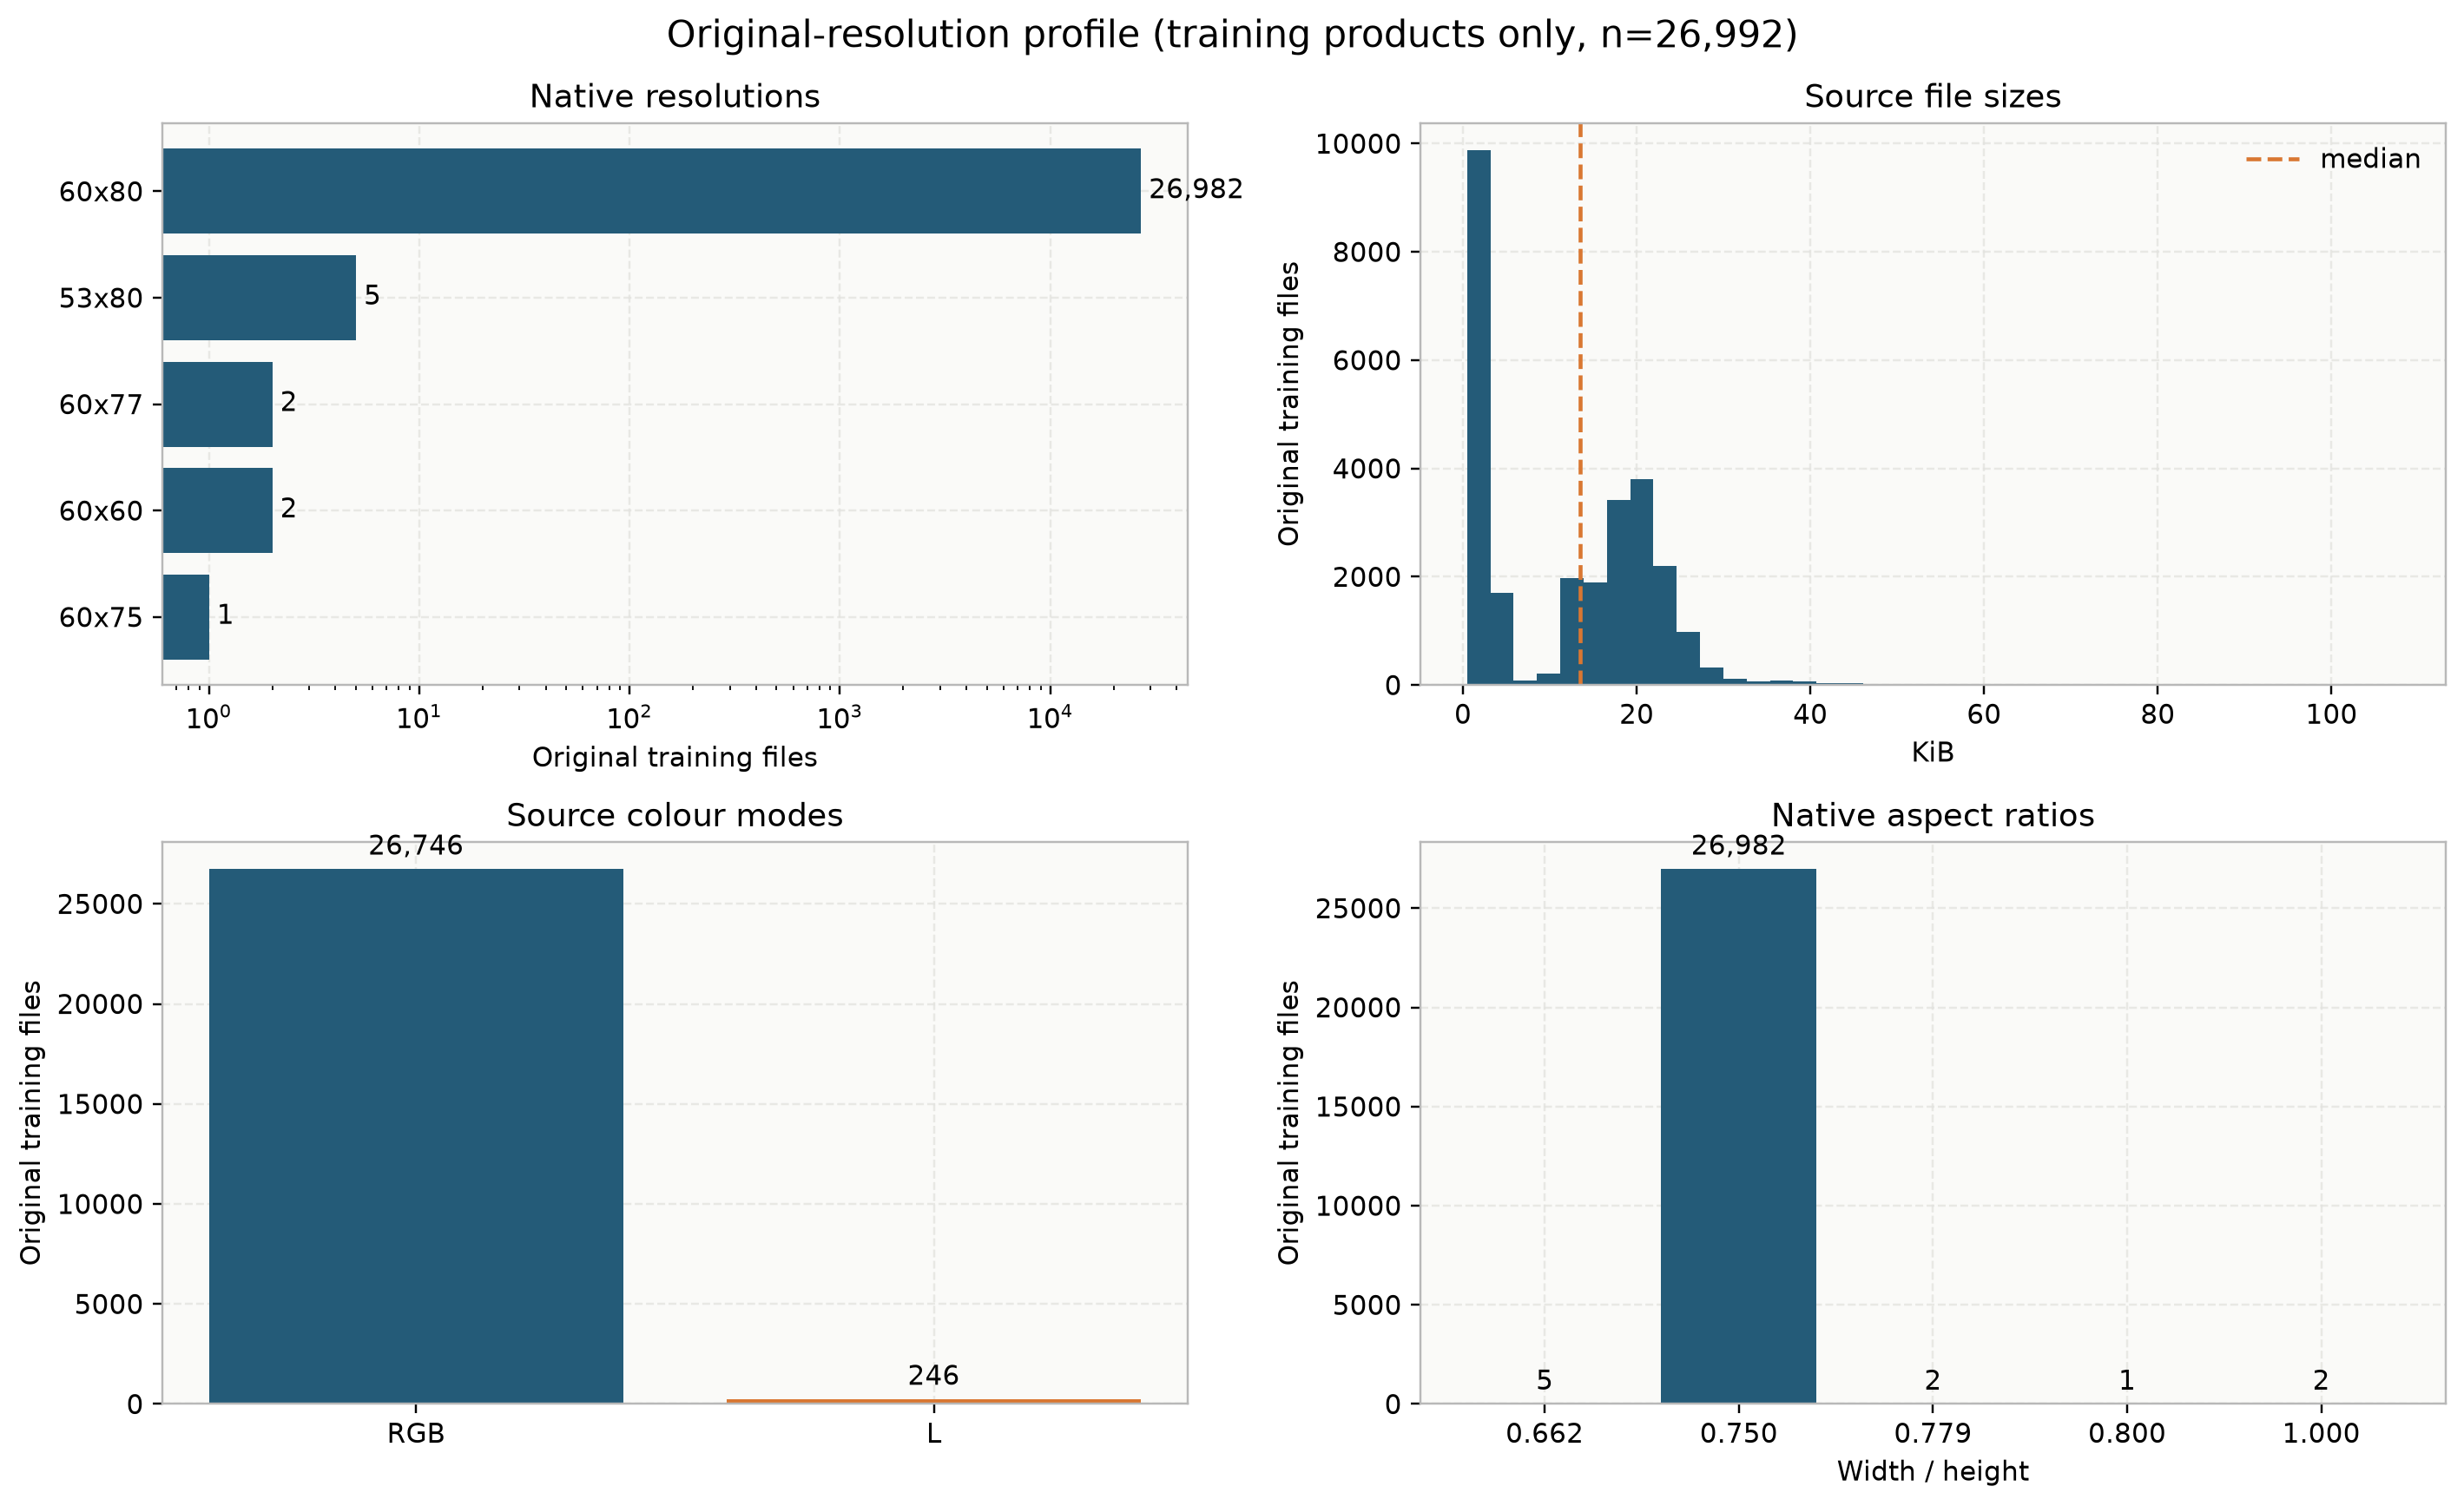


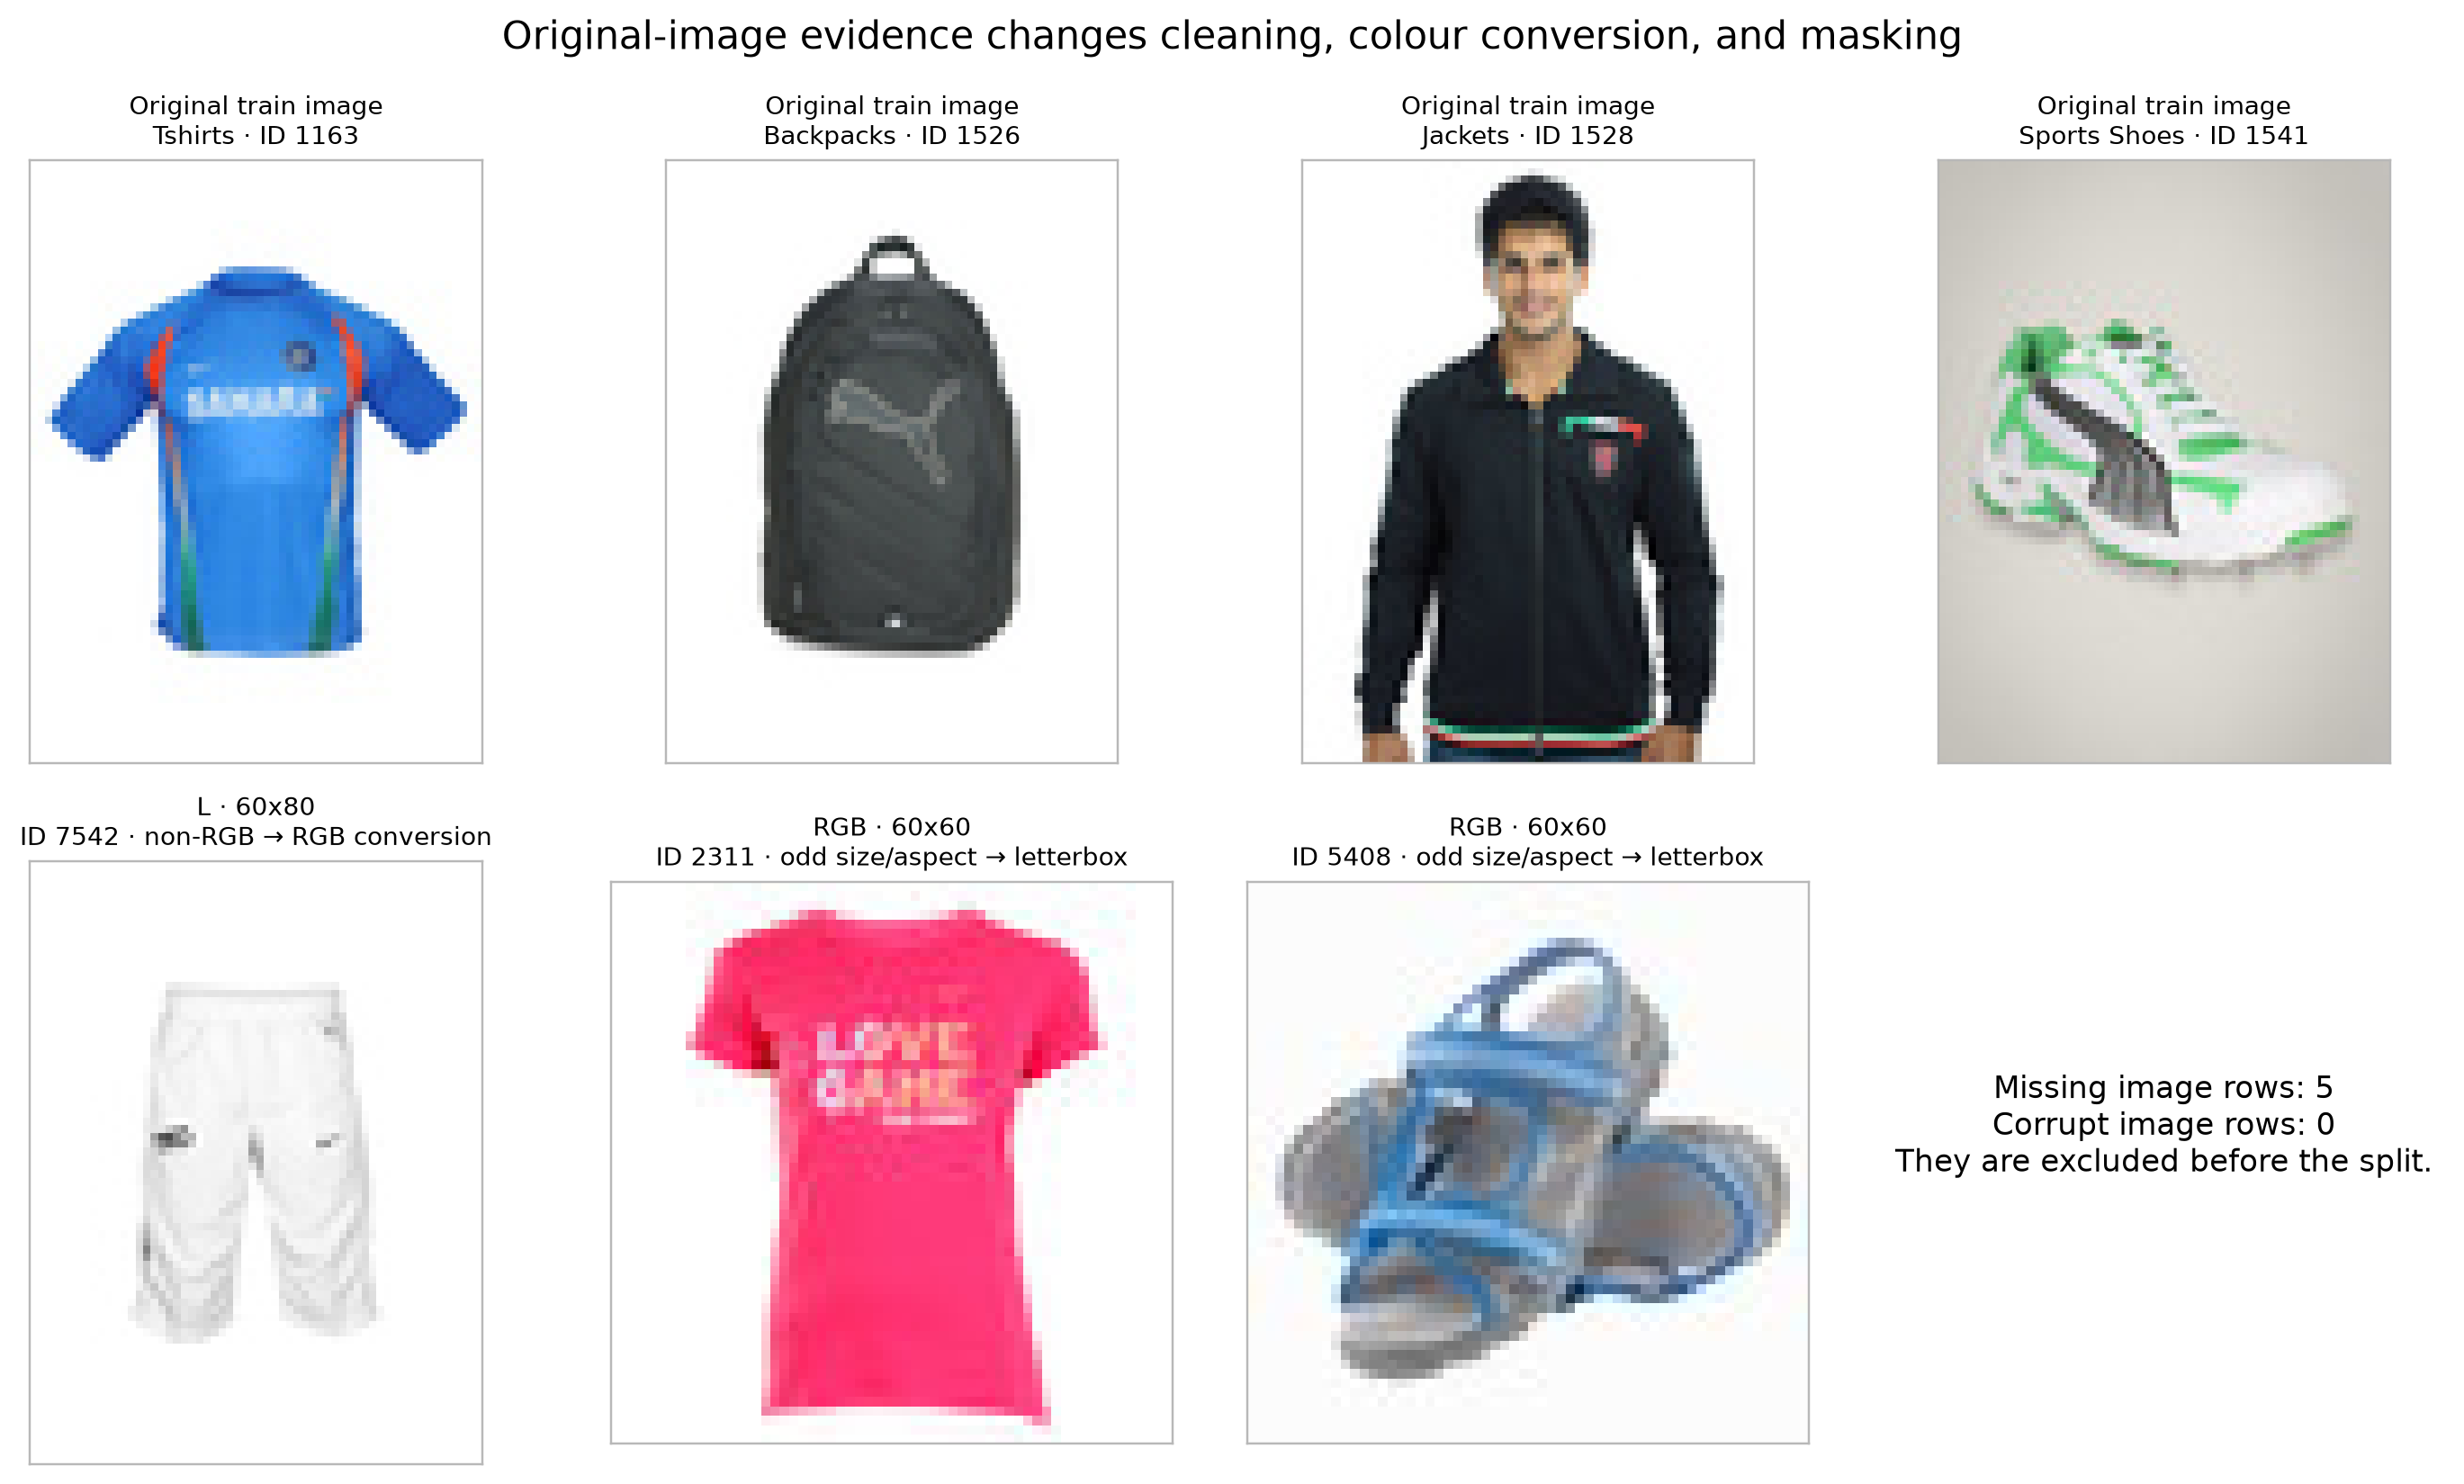


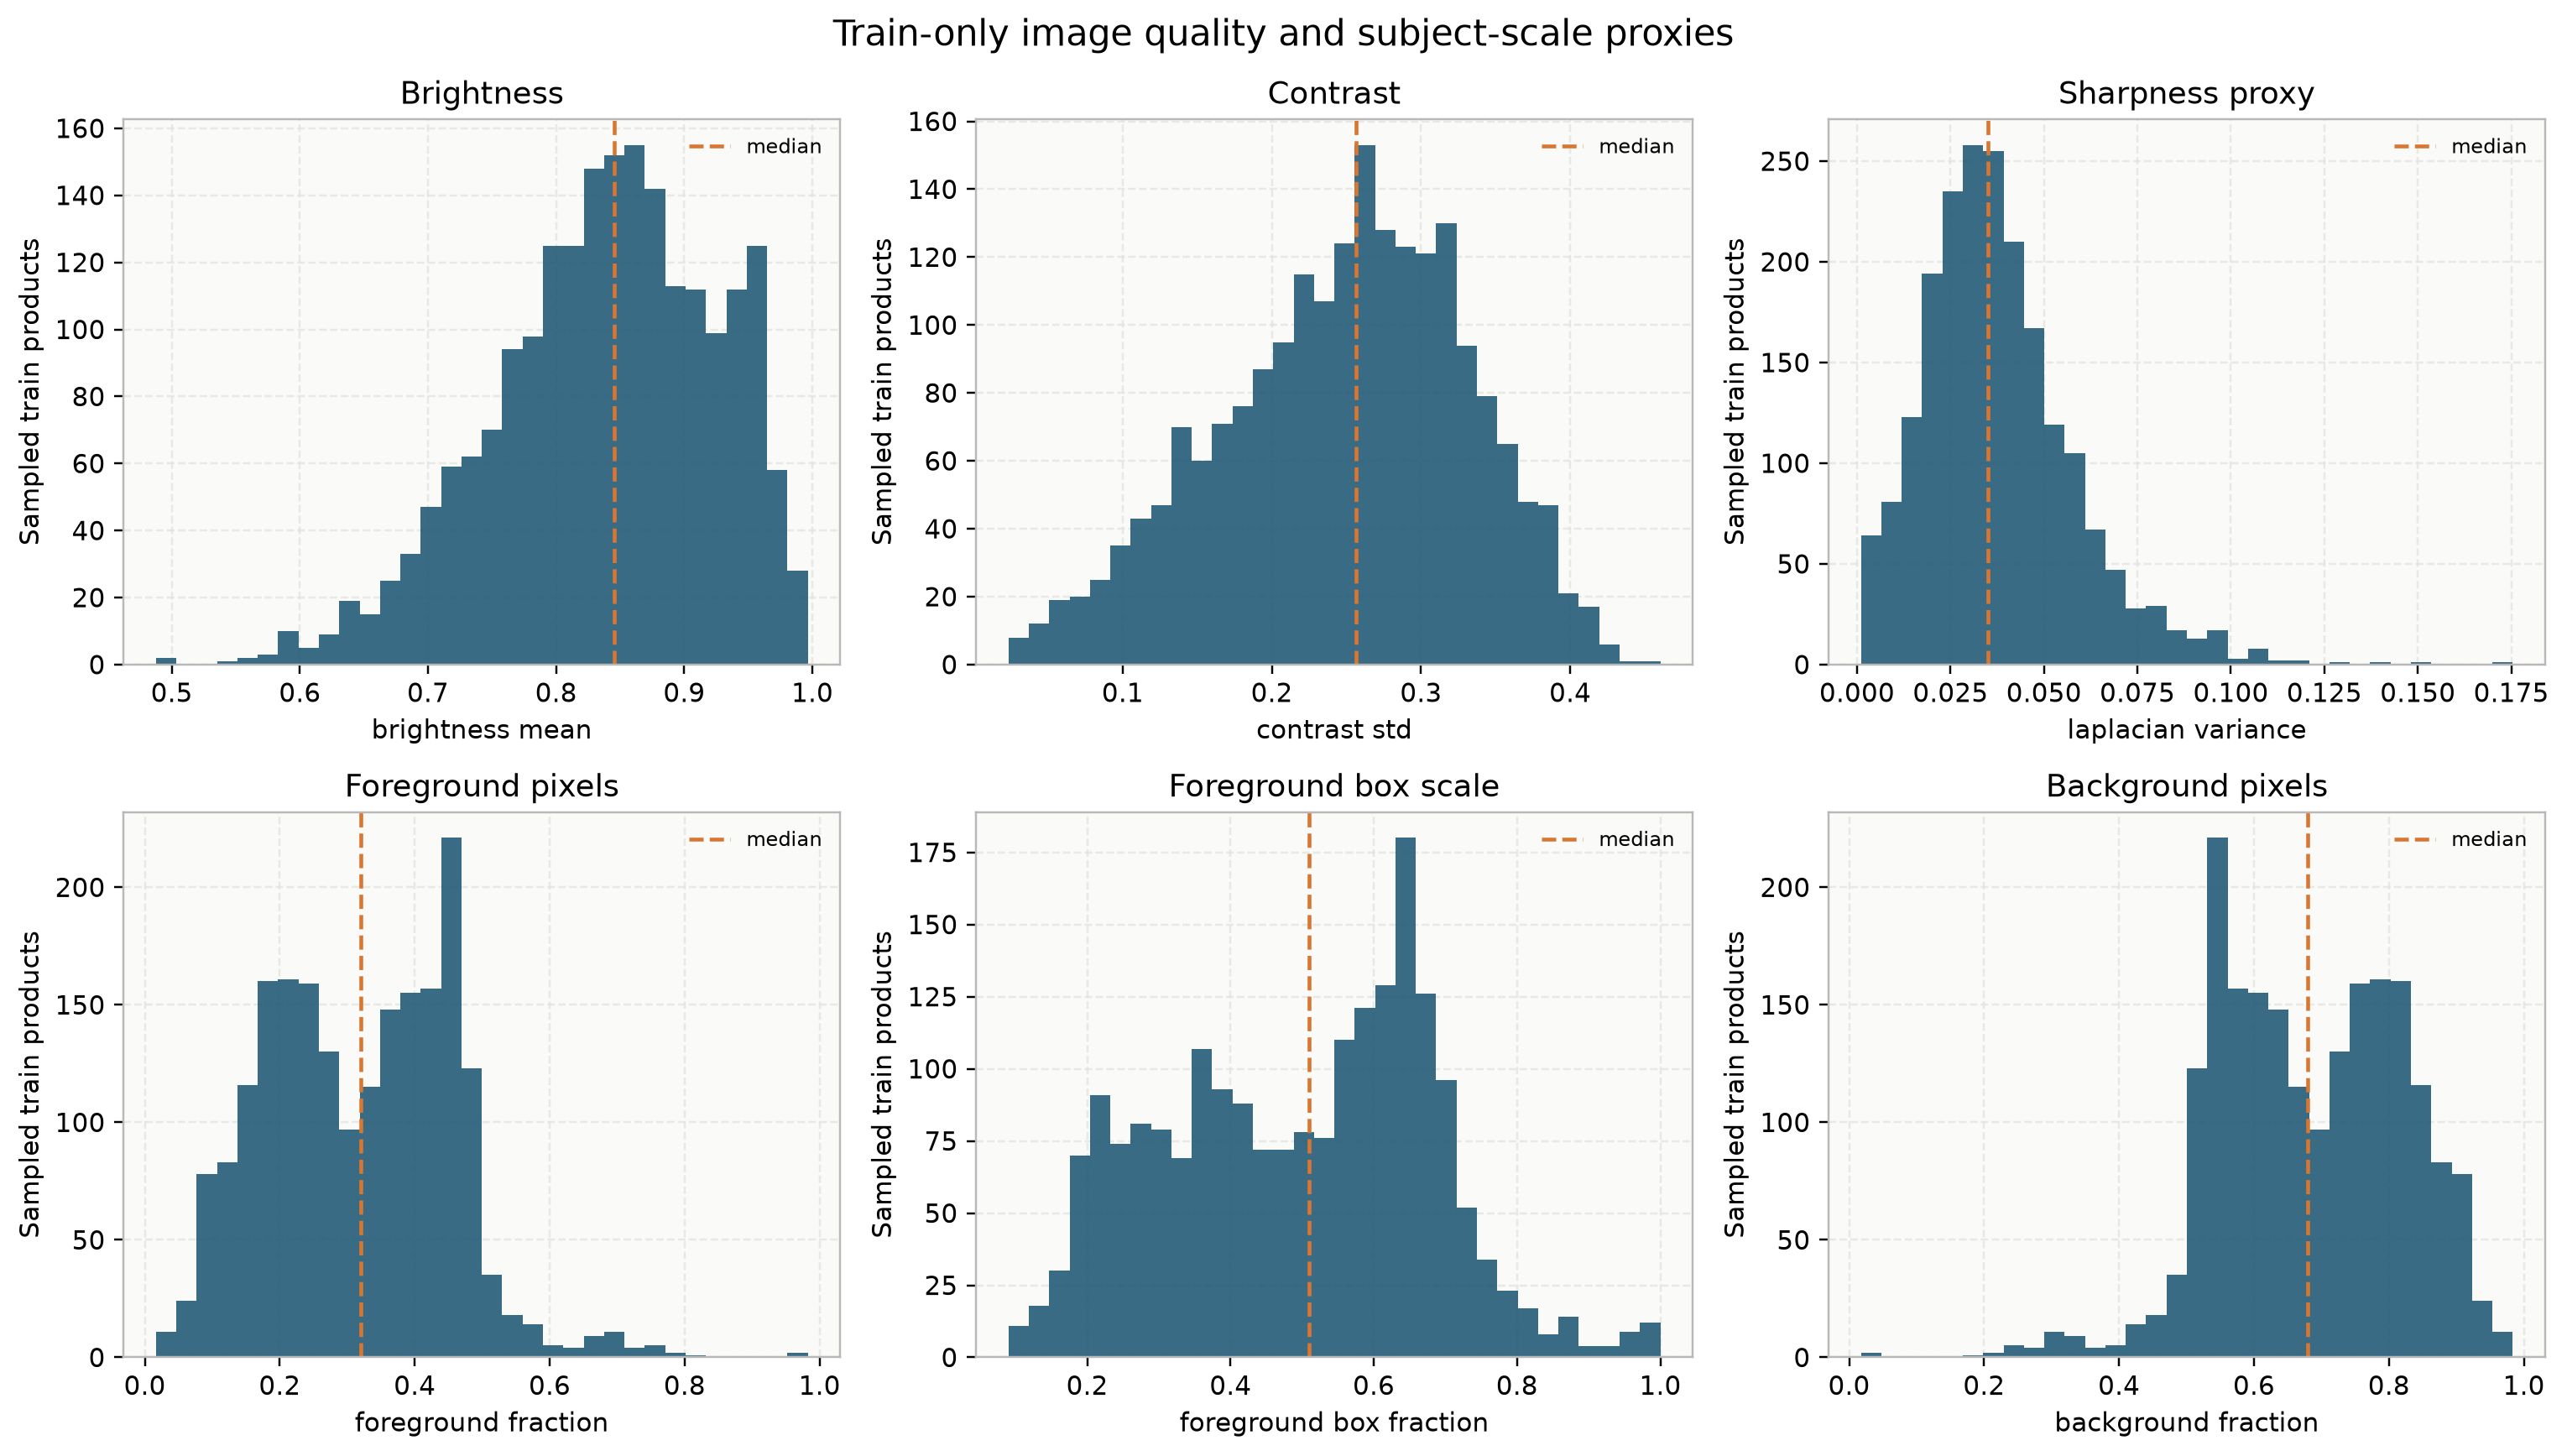


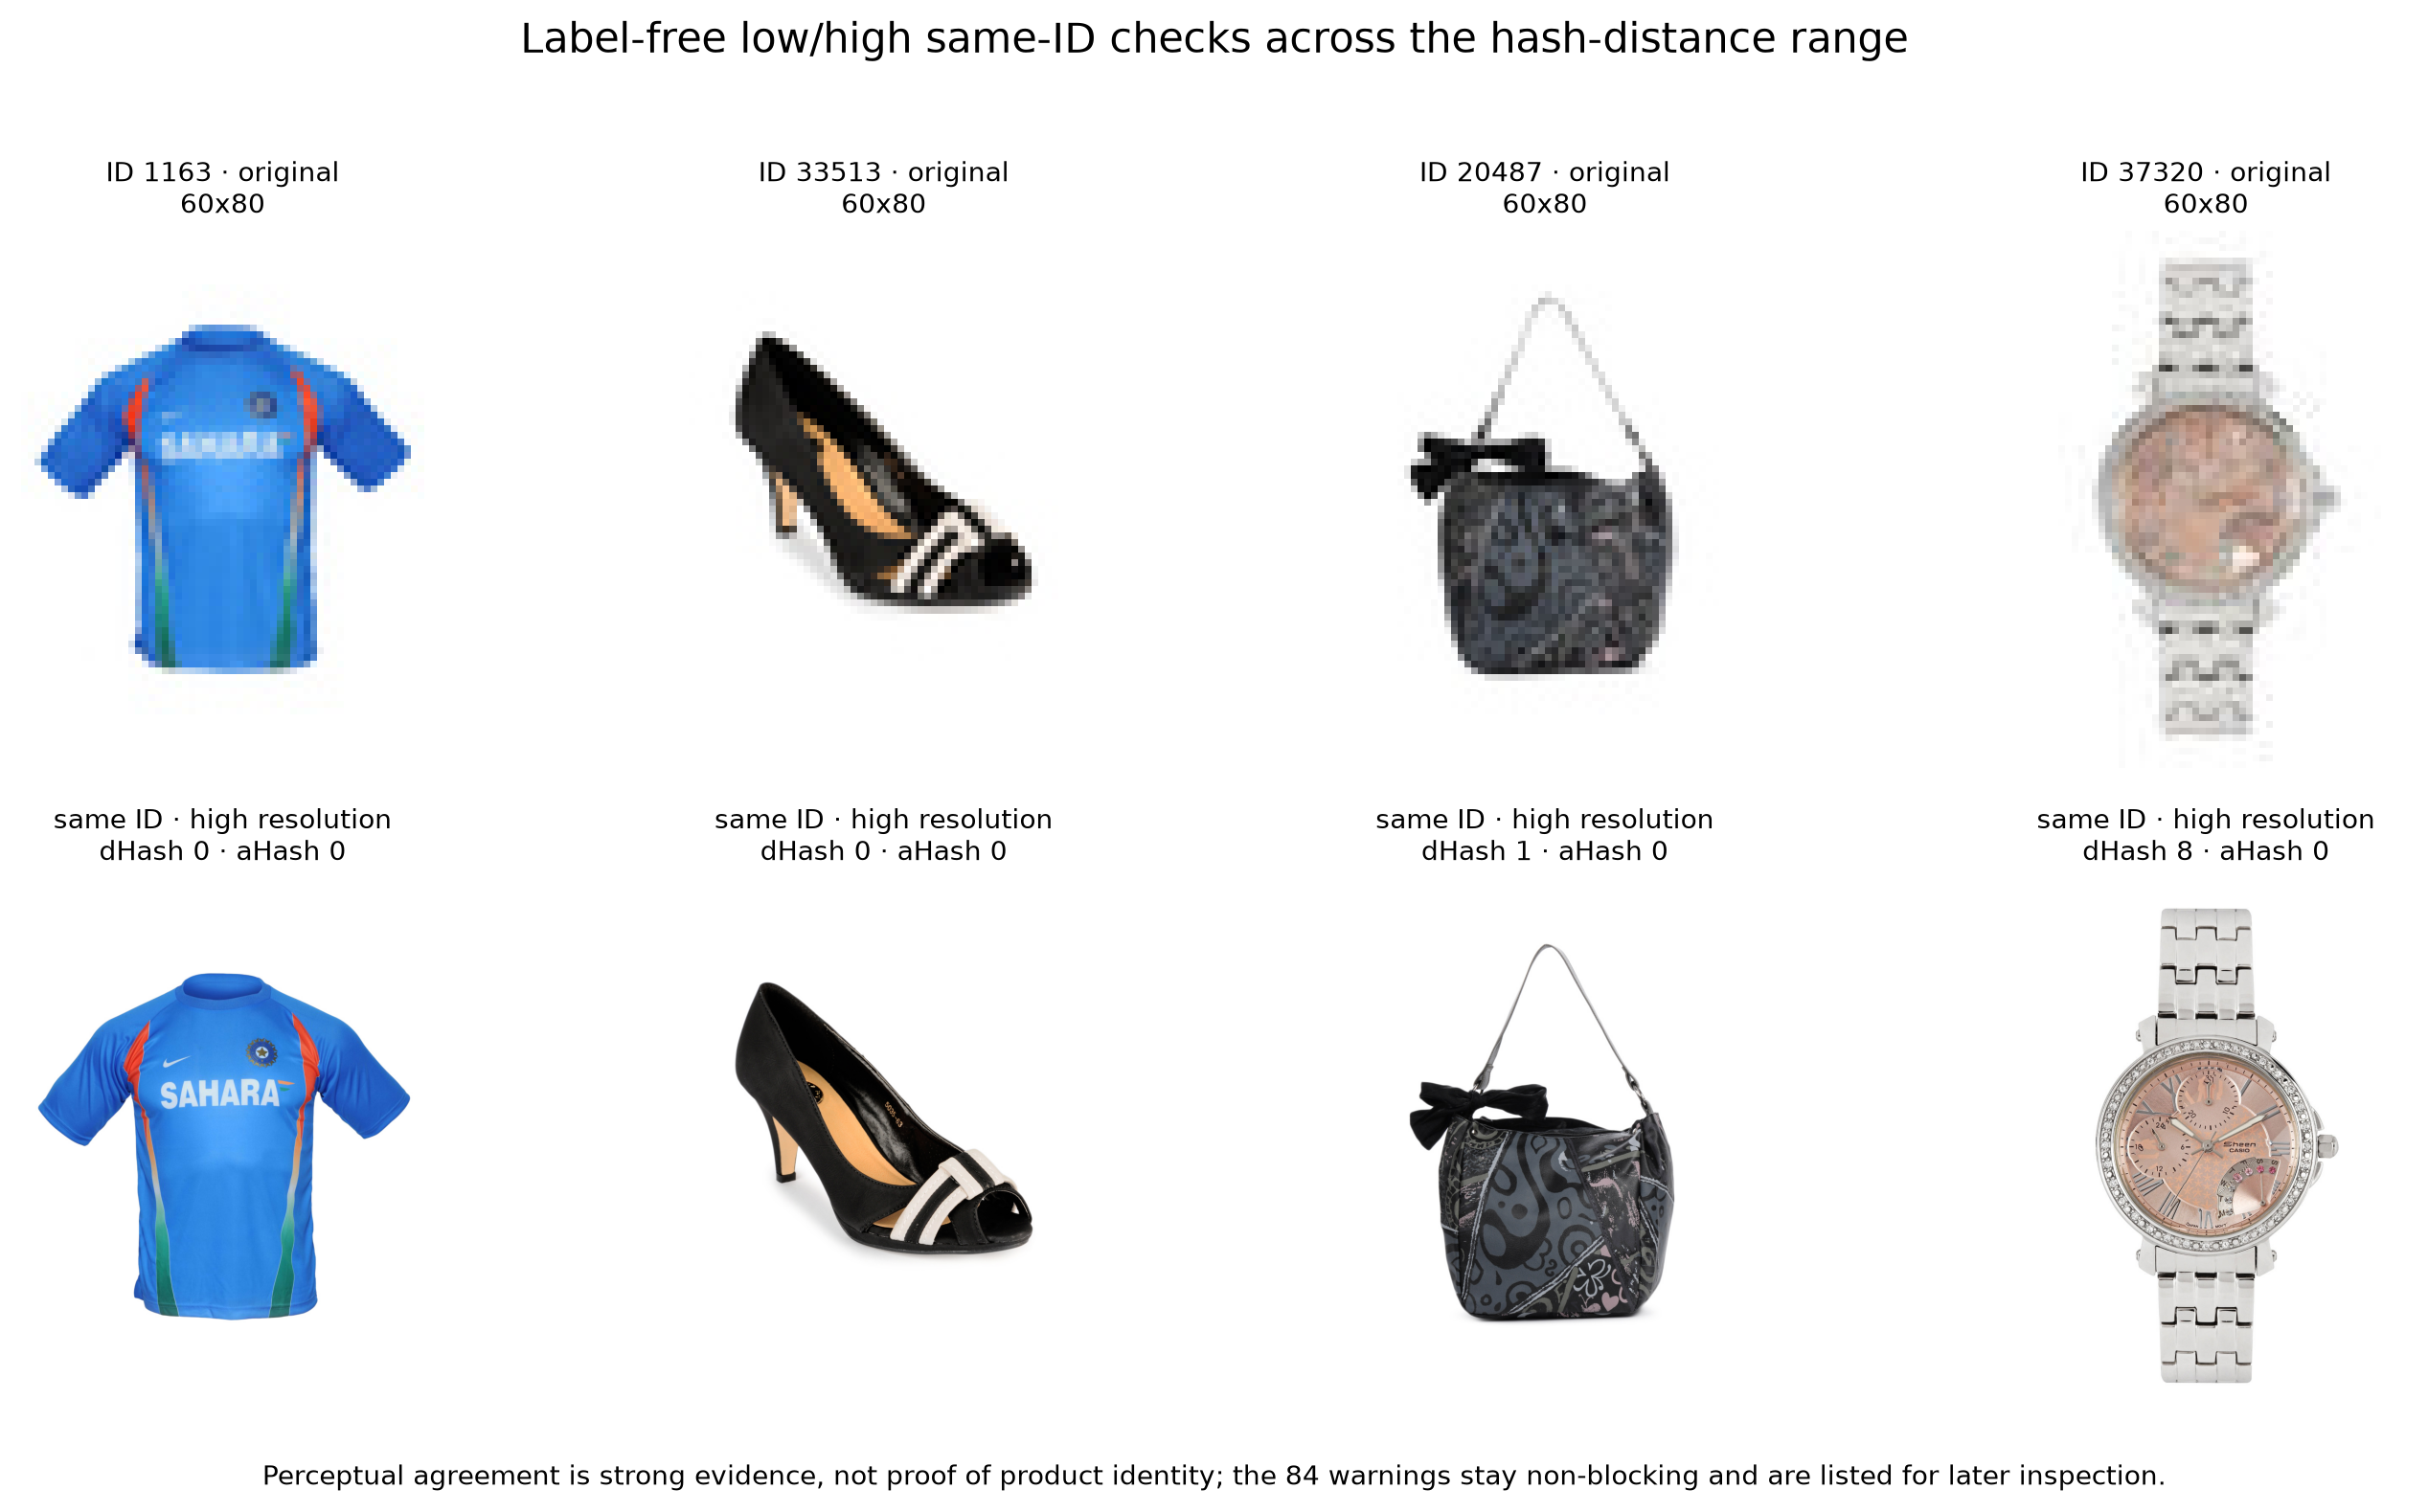

In [27]:
profile_figure = plot_image_profile(train_images)
quality_figure = plot_data_quality(train, train_images, issues)
train_quality_figure = plot_train_quality(train_quality_sample)
alignment_figure = plot_variant_alignment(variant_manifest, alignment_pairs)
image_contract_display = pd.DataFrame(
    [
        {
            "evidence": "original-resolution audit",
            "scope": (
                f"{int(image_summary.iloc[0]['original_files_audited']):,} files from "
                f"{int(image_summary.iloc[0]['paired_image_inputs']):,} train inputs"
            ),
            "result": (
                f"{int(image_summary.iloc[0]['original_native_60x80']):,} are 60x80; "
                f"{int(image_summary.iloc[0]['original_non_rgb_sources']):,} need RGB conversion"
            ),
            "modelling_use": "decode safely, convert to RGB, preserve aspect ratio",
        },
        {
            "evidence": "paired model datasets",
            "scope": f"{int(variant_proof['model_product_count']):,} product IDs",
            "result": (
                f"{int(variant_proof['model_variant_count']):,} image inputs: "
                f"{int(partition_input_counts.loc['train', 'image_inputs']):,} train; "
                f"{int(partition_input_counts.loc['val', 'image_inputs']):,} validation; "
                f"{int(partition_input_counts.loc['holdout', 'image_inputs']):,} holdout"
            ),
            "modelling_use": "load both images; weight or aggregate once per product",
        },
        {
            "evidence": "train-only quality sample",
            "scope": f"{len(train_quality_sample):,} original product images",
            "result": "brightness, contrast, sharpness, foreground and background scale",
            "modelling_use": "set robust augmentation bounds; slice errors by image quality",
        },
        {
            "evidence": "same-ID alignment screen",
            "scope": f"{int(alignment_proof['pair_count']):,} pairs",
            "result": (
                f"{int(alignment_proof['possible_content_mismatch_count']):,} non-blocking "
                "warnings listed for later inspection"
            ),
            "modelling_use": "keep warnings visible; never claim identity ground truth",
        },
    ]
)
show_table(image_contract_display, "Image-file evidence and actual model-input counts")
show_figure(
    profile_figure,
    (
        "Figure 11. Original-resolution training files show native resolution, colour mode, "
        "aspect ratio, and source-file-size distributions."
    ),
)
show_figure(
    quality_figure,
    (
        "Figure 12. Representative original-resolution files and objective exceptions motivate "
        "exclusion, RGB conversion, and letterbox masking."
    ),
)
show_figure(
    train_quality_figure,
    (
        "Figure 13. A deterministic train-only sample measures brightness, contrast, a "
        "sharpness proxy, and foreground/background scale for augmentation and error slices."
    ),
)
show_figure(
    alignment_figure,
    (
        "Figure 15. Same-ID original/high pairs span the observed hash-distance range. "
        "The 84 warnings are non-blocking review items, not identity ground truth."
    ),
)

> **Finding.** The original-resolution half of the training set contains 26,992 files: 26,982
> use the common 60x80 size, ten use another size, and 246 are not stored as RGB. The actual paired
> training loader contains 53,984 image inputs. Validation contains 11,562 inputs and holdout contains
> 11,556. Across all active partitions, 38,551 product IDs become 77,102 model inputs. The alignment
> screen covers 44,441 same-ID pairs and flags 84 non-blocking warnings, about 0.19%. A deterministic
> 2,048-product train-only sample adds brightness, contrast, sharpness, and subject-scale proxies.
> Figures 10–13 show the source profile, exceptions, quality distributions, and resolution pairs.
>
> **Modelling consequence.** Preprocessing preserves aspect ratio, converts images to RGB, and loads
> both resolutions. Each training pair carries one total unit of weight; each validation or holdout
> pair becomes one final product prediction. Train-only mean/std normalizes inputs; quality tails
> define augmentation bounds and later error slices. The doubled image-input count is a real compute and
> storage cost, even though product-level metrics count each ID once.

### 6.2 Numeric image-feature correlation

The target tags are categorical, so Section 5 uses normalized mutual information rather than a
linear correlation coefficient. The image-quality measures are numeric and may be monotonic without
being linear, so this section uses train-only Spearman rank correlation.

The goal is to find redundant measurements and possible image shortcuts. Correlation describes
association, not cause, and it does not justify dropping a feature without a controlled downstream
comparison.

**Code step — Train-only Spearman image-feature correlation.**

Computes and saves the full rank-correlation matrix for six numeric image measures, then renders a labelled heatmap and a strongest-pair table.

,feature_x,feature_y,spearman_rho,absolute_rho
0,foreground_fraction,background_fraction,-1.000,1.000
1,foreground_box_fraction,background_fraction,-0.902,0.902
2,foreground_fraction,foreground_box_fraction,0.902,0.902
3,brightness_mean,contrast_std,-0.847,0.847
4,brightness_mean,background_fraction,0.791,0.791
5,brightness_mean,foreground_fraction,-0.791,0.791
6,brightness_mean,foreground_box_fraction,-0.674,0.674
7,brightness_mean,laplacian_variance,-0.606,0.606
8,contrast_std,laplacian_variance,0.574,0.574
9,laplacian_variance,foreground_box_fraction,0.544,0.544



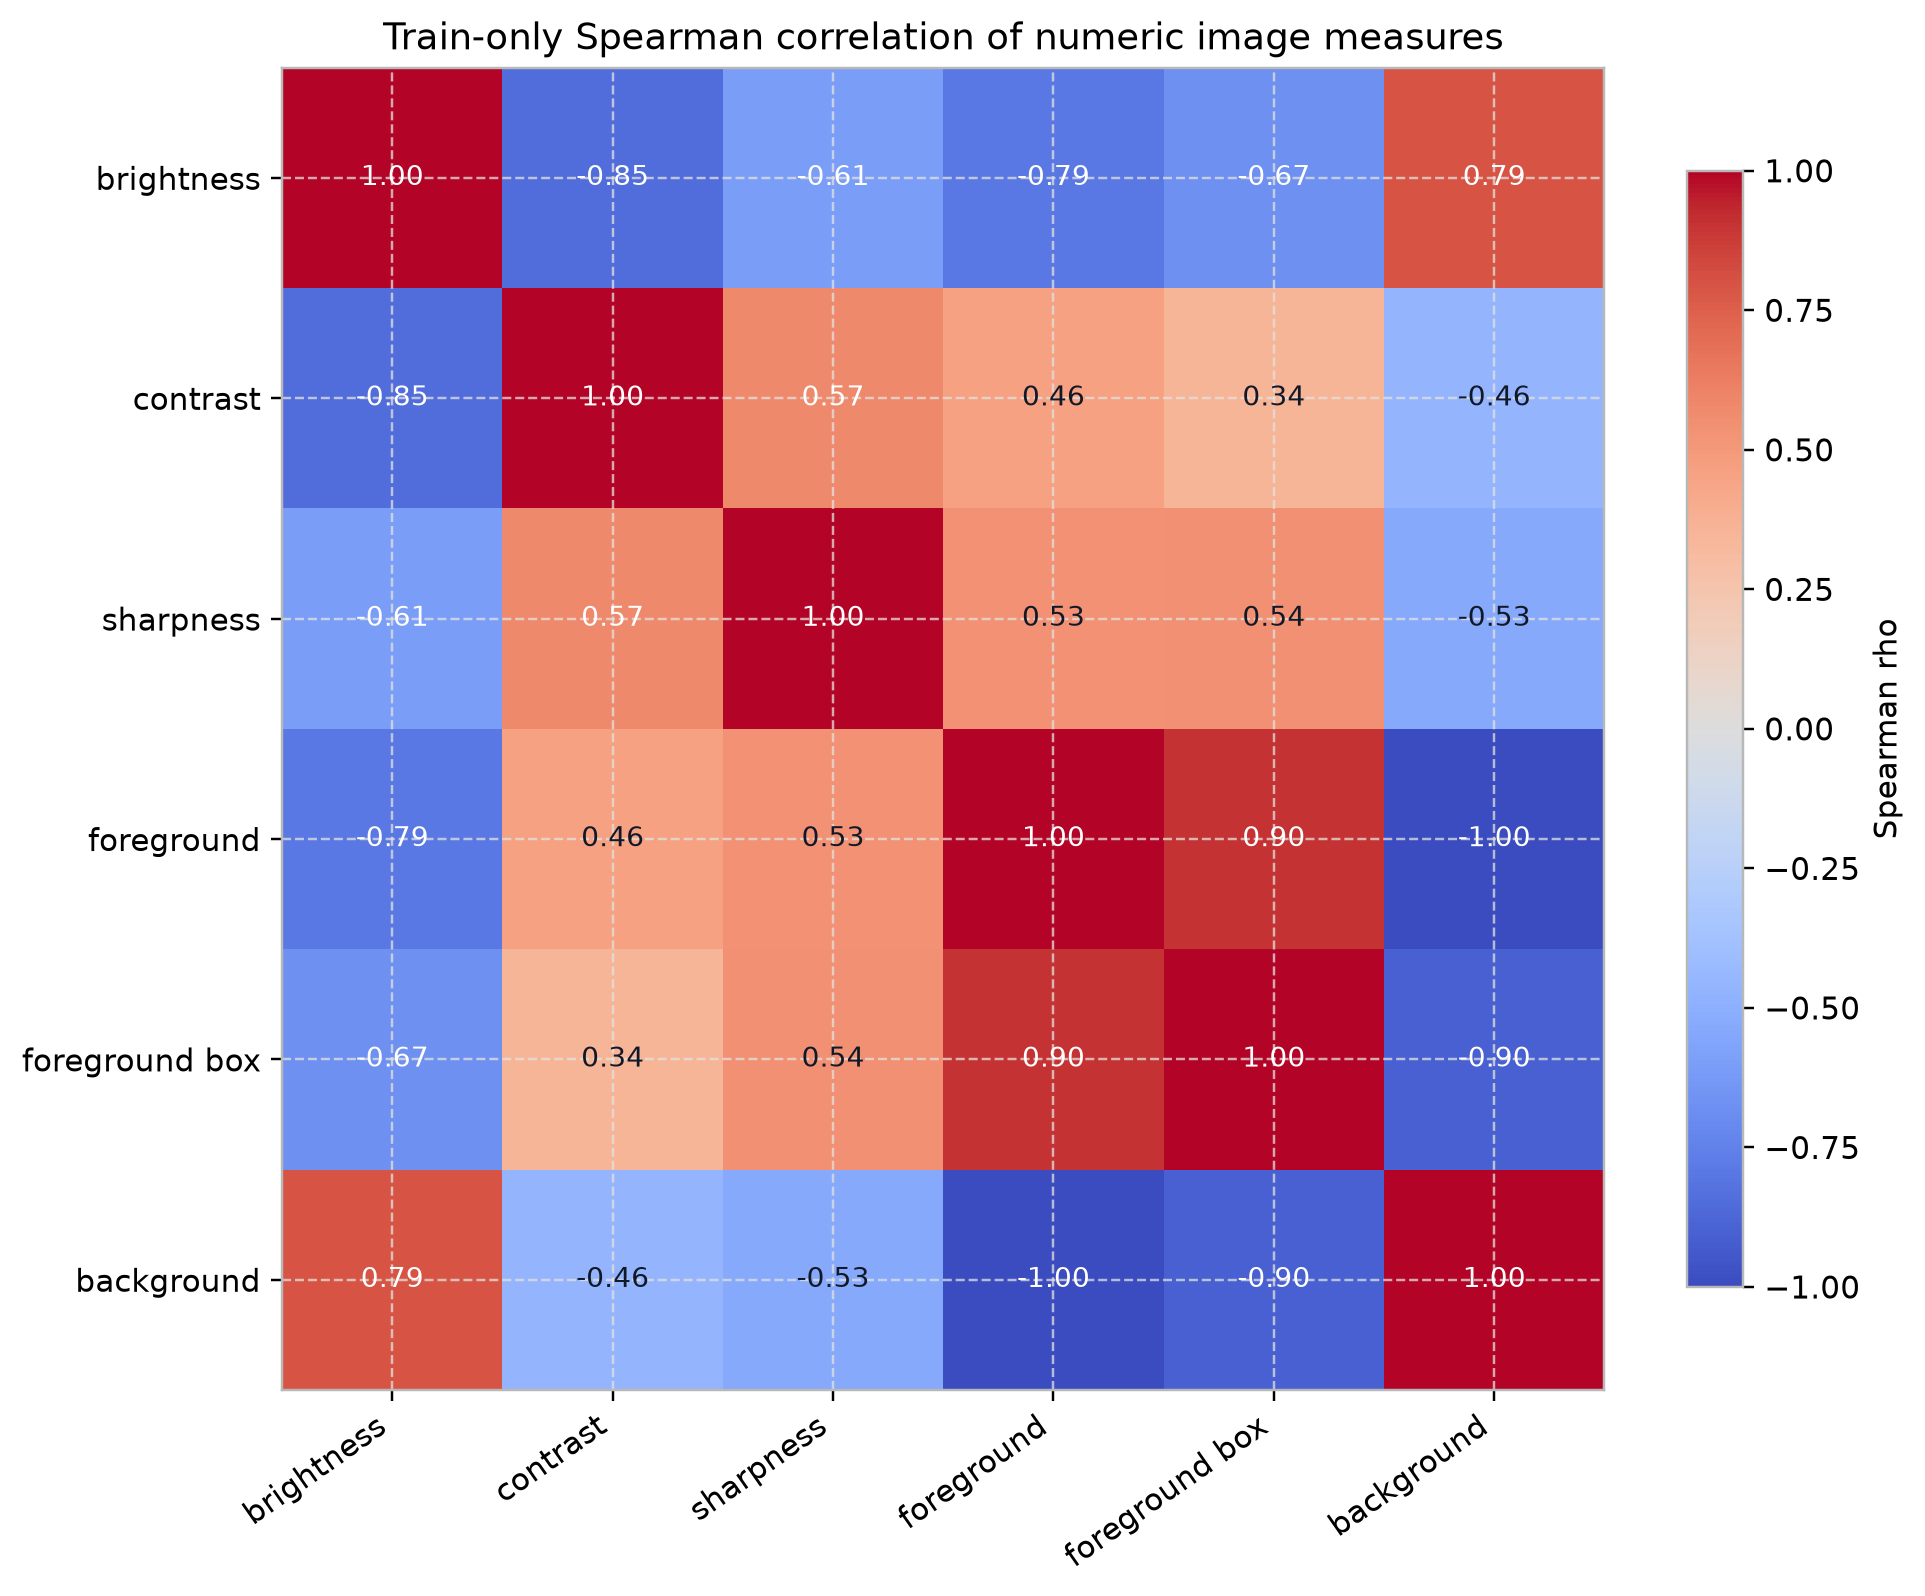

In [28]:
quality_feature_columns = [
    "brightness_mean",
    "contrast_std",
    "laplacian_variance",
    "foreground_fraction",
    "foreground_box_fraction",
    "background_fraction",
]
image_quality_spearman_matrix = train_quality_sample[quality_feature_columns].corr(
    method="spearman"
)
image_quality_spearman = (
    image_quality_spearman_matrix.rename_axis("feature_x")
    .reset_index()
    .melt(id_vars="feature_x", var_name="feature_y", value_name="spearman_rho")
)
image_quality_spearman["absolute_rho"] = image_quality_spearman["spearman_rho"].abs()
save_csv(image_quality_spearman, "image_quality_spearman.csv")

upper_mask = np.triu(np.ones(image_quality_spearman_matrix.shape, dtype=bool), k=1)
unique_pairs = (
    image_quality_spearman_matrix.where(upper_mask)
    .stack()
    .rename("spearman_rho")
    .reset_index()
    .rename(columns={"level_0": "feature_x", "level_1": "feature_y"})
)
unique_pairs["absolute_rho"] = unique_pairs["spearman_rho"].abs()
unique_pairs.sort_values(
    ["absolute_rho", "feature_x", "feature_y"],
    ascending=[False, True, True],
    inplace=True,
    ignore_index=True,
)
if unique_pairs.empty:
    strongest_image_quality_pair = {
        "feature_x": "not estimable",
        "feature_y": "not estimable",
        "spearman_rho": None,
    }
else:
    strongest = unique_pairs.iloc[0]
    strongest_image_quality_pair = {
        "feature_x": str(strongest["feature_x"]),
        "feature_y": str(strongest["feature_y"]),
        "spearman_rho": float(strongest["spearman_rho"]),
    }

short_labels = [
    "brightness",
    "contrast",
    "sharpness",
    "foreground",
    "foreground box",
    "background",
]
fig, axis = plt.subplots(figsize=(9, 7.5))
heatmap = axis.imshow(image_quality_spearman_matrix, cmap="coolwarm", vmin=-1, vmax=1)
axis.set_xticks(range(len(short_labels)), short_labels, rotation=35, ha="right")
axis.set_yticks(range(len(short_labels)), short_labels)
for row_index in range(len(short_labels)):
    for column_index in range(len(short_labels)):
        value = image_quality_spearman_matrix.iloc[row_index, column_index]
        if np.isfinite(value):
            axis.text(
                column_index,
                row_index,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="white" if abs(value) > 0.55 else "#111827",
                fontsize=9,
            )
axis.set_title("Train-only Spearman correlation of numeric image measures")
fig.colorbar(heatmap, ax=axis, label="Spearman rho", shrink=0.8)
fig.tight_layout()
image_quality_correlation_figure = save_figure(fig, "image_quality_correlation.png")
show_table(unique_pairs.head(10), "Strongest unique numeric image-feature associations")
show_figure(
    image_quality_correlation_figure,
    (
        "Figure 14. Train-only Spearman rank correlation separates redundant image "
        "quality measures from weaker associations."
    ),
)

> **Finding.** `foreground_fraction` and `background_fraction` are exact complements, so
> their Spearman correlation is -1 by construction rather than a new discovery. Foreground coverage
> and foreground-box coverage are also strongly related. Brightness and contrast have a strong
> negative rank association in the train-only sample. Figure 14 distinguishes these redundancies
> from the categorical target associations measured with NMI in Section 5.
>
> **Modelling consequence.** Do not present complementary foreground/background measures as two
> independent signals. Task owners may use these diagnostics for shortcut slices or ablations, but
> must test any preprocessing choice under the same split and budget. Correlation alone does not
> choose a model input.

### 6.3 Input transformation

The transform comparison measures geometry, padding, tensor size, and local decoding cost. Model
quality remains an open experimental result rather than an EDA claim.

**Code step — Transform comparison functions.**

Defines the padding and tensor-cost calculation and the visual grid used to compare the 128x128 and 96x128 transforms.

In [29]:
# Transform cost and visual comparison evidence


def transform_cost(image_size: tuple[int, int], native_size: tuple[int, int]) -> dict[str, Any]:
    output_height, output_width = resolve_image_size(image_size)
    native_width, native_height = native_size
    scale = min(output_width / native_width, output_height / native_height)
    content_width = max(1, round(native_width * scale))
    content_height = max(1, round(native_height * scale))
    output_pixels = output_height * output_width
    content_pixels = content_height * content_width
    return {
        "output_height": output_height,
        "output_width": output_width,
        "content_height": content_height,
        "content_width": content_width,
        "output_pixels": output_pixels,
        "padding_pixels": output_pixels - content_pixels,
        "padding_percent": (output_pixels - content_pixels) / output_pixels * 100,
        "float32_rgb_kib": output_pixels * 3 * 4 / 1024,
    }


def plot_transform_grid(train_frame: pd.DataFrame, train_images: pd.DataFrame) -> Path:
    lookup = train_frame.set_index("id")
    ids = [int(train_frame.sort_values("id").iloc[0]["id"])]
    for mask in (
        train_images["mode"].ne("RGB"),
        ~(train_images["width"].eq(60) & train_images["height"].eq(80)),
    ):
        candidates = train_images[mask].sort_values("id")
        ids.append(int(candidates.iloc[0]["id"]) if not candidates.empty else ids[0])
    fig, axes = plt.subplots(3, 3, figsize=(9.5, 11))
    for row_index, item_id in enumerate(ids):
        row = lookup.loc[item_id]
        source = open_rgb(str(row["path"]))
        old = transform_image(source, image_size=LEGACY_IMAGE_SIZE)
        chosen = transform_image(source, image_size=IMAGE_SIZE)
        old_cost = transform_cost(LEGACY_IMAGE_SIZE, source.size)
        chosen_cost = transform_cost(IMAGE_SIZE, source.size)
        show_image(
            axes[row_index, 0], source, f"Source · ID {item_id}\n{source.width}x{source.height}"
        )
        show_image(
            axes[row_index, 1],
            old,
            f"Old 128x128\npadding {old_cost['padding_percent']:.1f}%",
        )
        show_image(
            axes[row_index, 2],
            chosen,
            f"Chosen 96x128\npadding {chosen_cost['padding_percent']:.1f}%",
        )
    fig.suptitle("96x128 matches the common 60x80 source with fewer tensor pixels")
    fig.text(
        0.5,
        0.015,
        "Padding is excluded from train-only mean/std and becomes neutral after standardization.",
        ha="center",
        fontsize=9,
    )
    fig.tight_layout(rect=(0, 0.04, 1, 0.97))
    return save_figure(fig, "transform_comparison.png")

**Code step — Transform benchmark results.**

Runs a fixed original-resolution training-file sample through both transforms. This local timing sample does not represent the full 53,984-input paired training epoch.

,option,shape,padding_pct,pixels,rgb_kib,images_per_sec
0,old_128x128,128x128,25.000,"16,384",192.000,"5,526.800"
1,chosen_96x128,96x128,0.000,"12,288",144.000,"5,714.000"



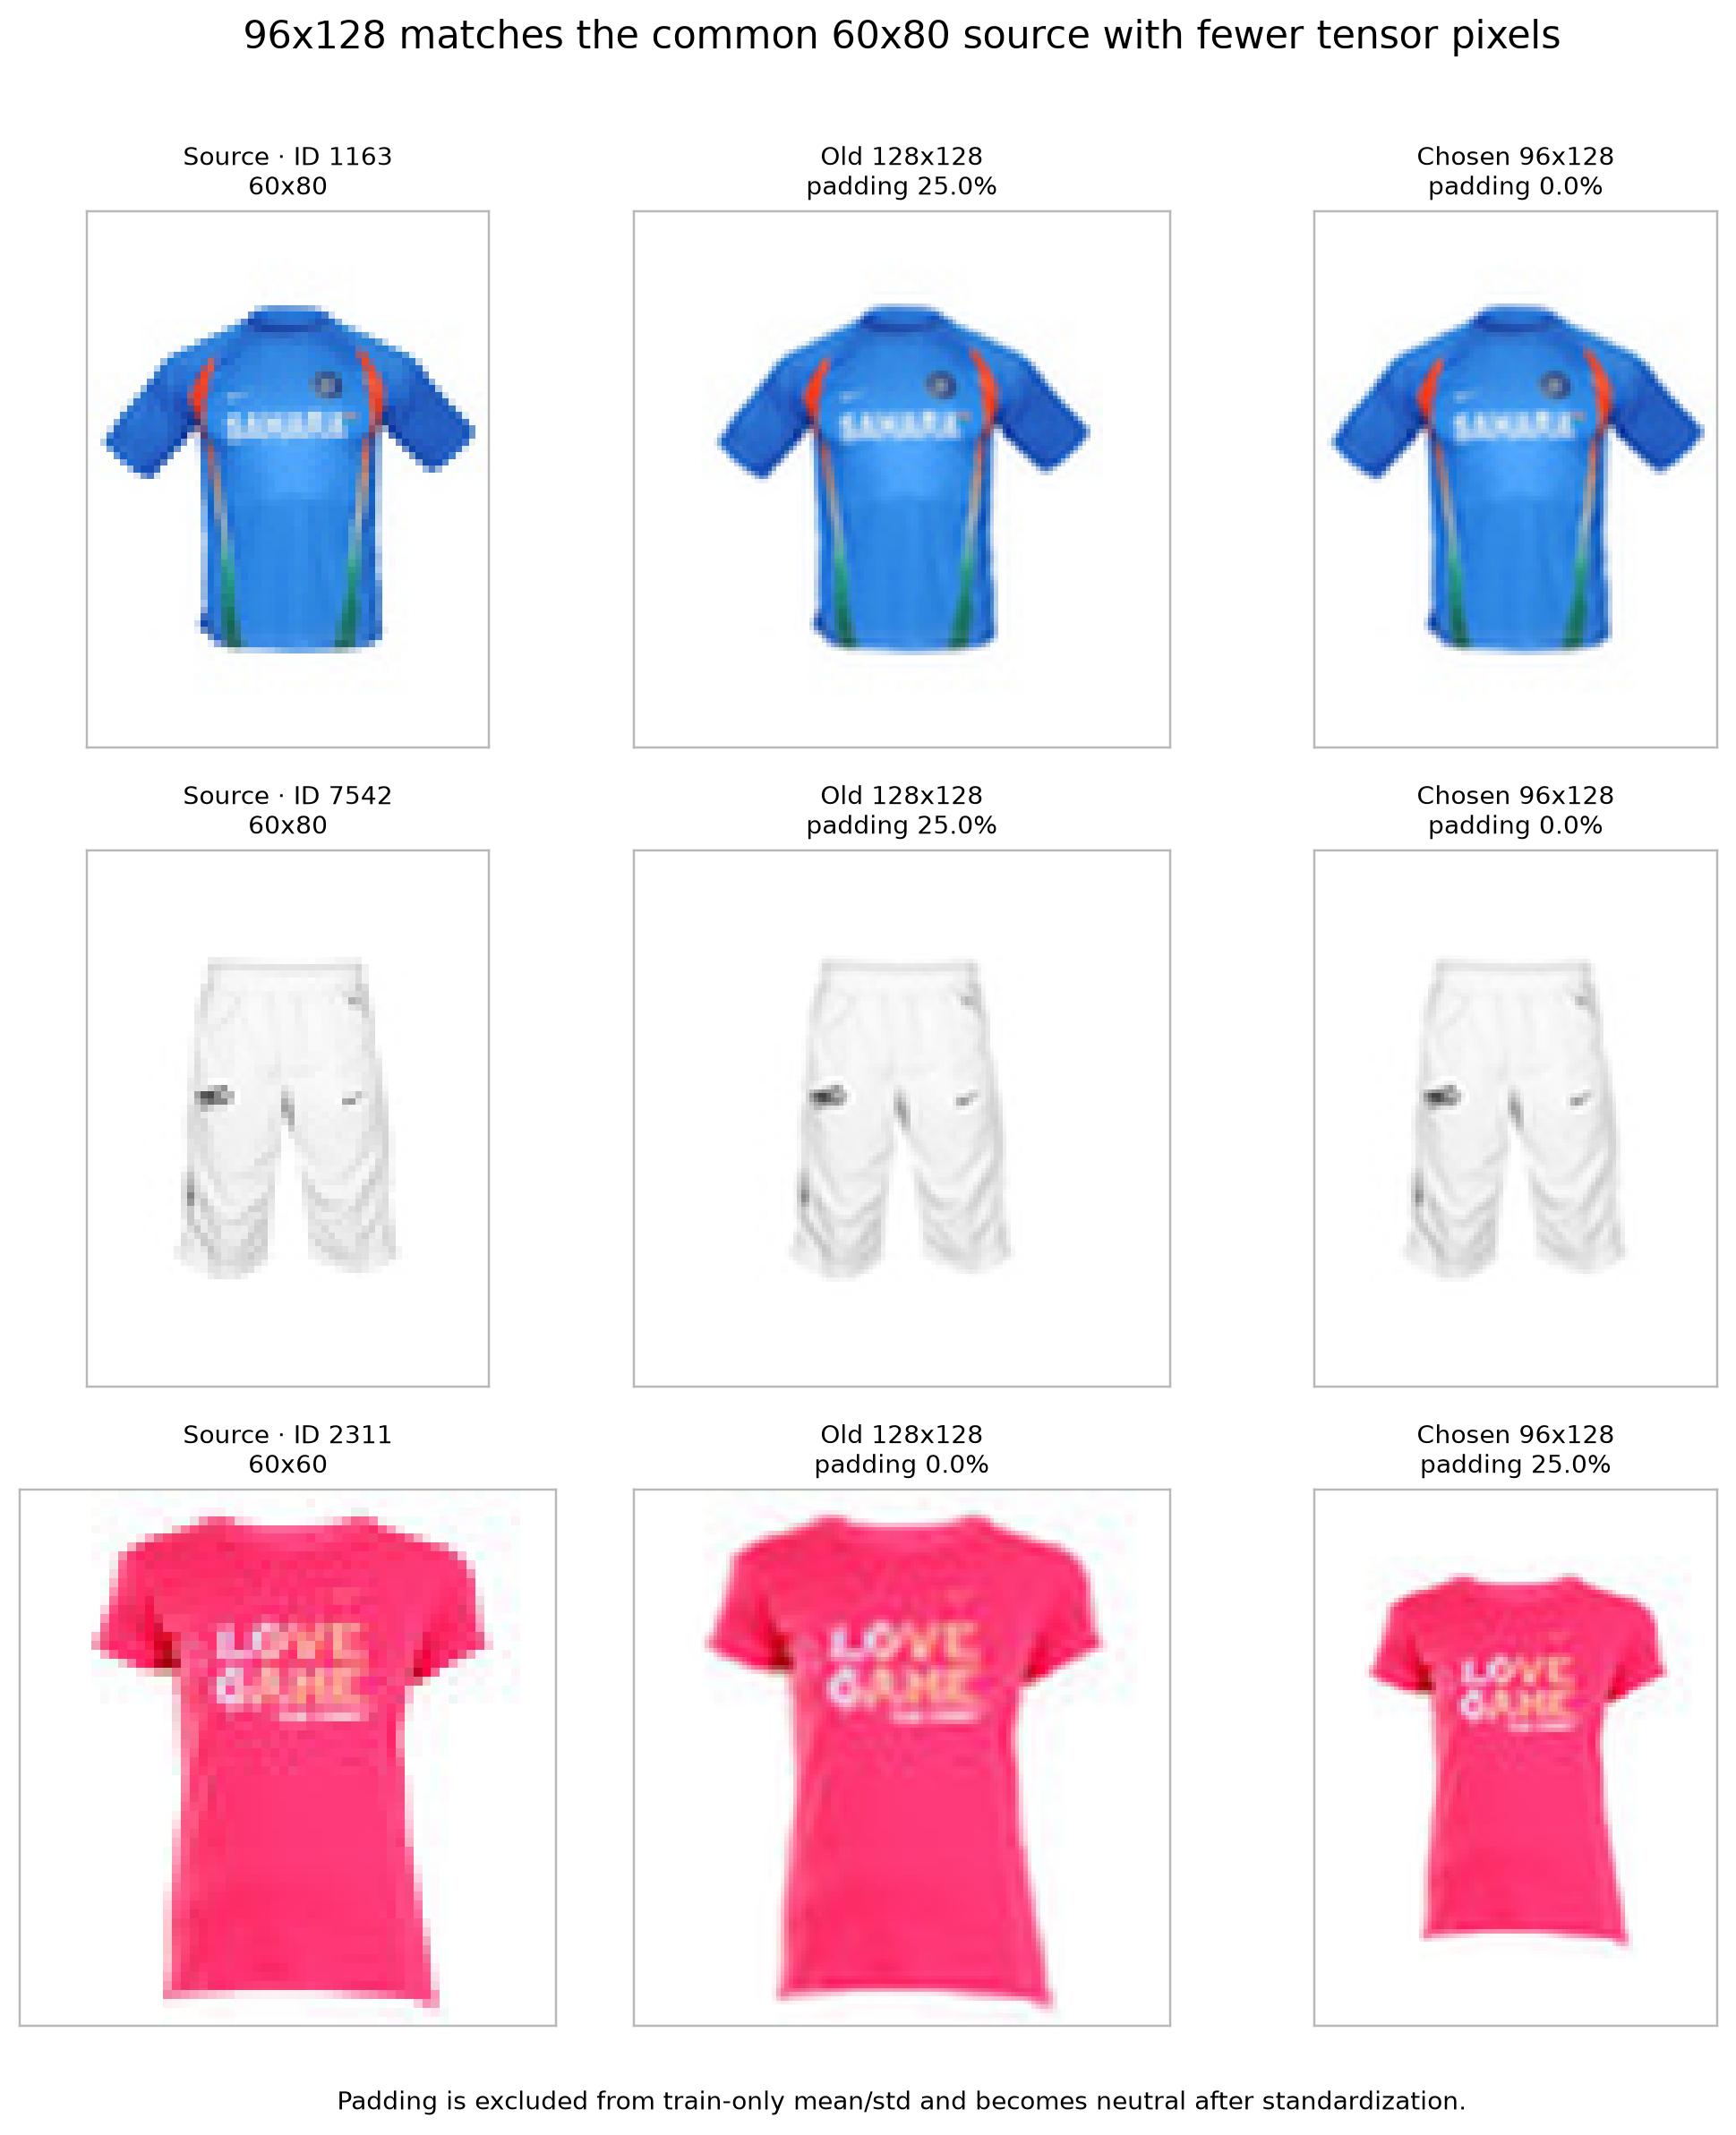

In [30]:
options = {"old_128x128": LEGACY_IMAGE_SIZE, "chosen_96x128": IMAGE_SIZE}
sample_size = min(BENCHMARK_SAMPLE_SIZE, len(train))
sample = train.sample(sample_size, random_state=SEED).sort_values("id")
benchmark_images = [open_rgb(path) for path in sample["path"]]
timings: dict[str, dict[str, Any]] = {}
for name, size in options.items():
    for source in benchmark_images[: min(8, len(benchmark_images))]:
        transform_image(source, image_size=size)
    seconds = []
    for _ in range(BENCHMARK_REPETITIONS):
        started = time.perf_counter()
        for source in benchmark_images:
            transform_image(source, image_size=size)
        seconds.append(time.perf_counter() - started)
    middle = median(seconds)
    timings[name] = {
        "seconds": [round(value, 6) for value in seconds],
        "median_seconds": round(middle, 6),
        "median_images_per_second": round(sample_size / middle, 2),
    }
transform_rows = []
for name, size in options.items():
    cost = transform_cost(size, (60, 80))
    transform_rows.append(
        {
            "alternative": name,
            "output_width_height": f"{cost['output_width']}x{cost['output_height']}",
            "padding_percent_for_60x80": cost["padding_percent"],
            "output_pixels": cost["output_pixels"],
            "float32_rgb_kib": cost["float32_rgb_kib"],
            "median_images_per_second": timings[name]["median_images_per_second"],
            "validation_macro_f1": "not available; no registered training run",
        }
    )
transform_summary = pd.DataFrame(transform_rows)
benchmark_record = {
    "scope": "deterministic original-resolution training-file sample; labels unused",
    "seed": SEED,
    "sample_size": sample_size,
    "sample_ids": sample["id"].astype(int).tolist(),
    "repetitions": BENCHMARK_REPETITIONS,
    "runtime": {
        "python": platform.python_version(),
    },
    "timings": timings,
    "limitation": "wall time depends on hardware and cache state",
    "decision": "use 96x128 for exact padding, pixel-count, and memory reasons",
}
save_csv(transform_summary, "transform_summary.csv")
save_json(benchmark_record, "transform_benchmark.json")
transform_figure = plot_transform_grid(train, train_images)
transform_display = (
    transform_summary.rename(
        columns={
            "alternative": "option",
            "output_width_height": "shape",
            "padding_percent_for_60x80": "padding_pct",
            "output_pixels": "pixels",
            "float32_rgb_kib": "rgb_kib",
            "median_images_per_second": "images_per_sec",
            "validation_macro_f1": "model_score",
        }
    )
    .drop(columns="model_score")
    .round({"padding_pct": 1, "rgb_kib": 1, "images_per_sec": 1})
)
show_table(transform_display, "Transform cost and local wall-time benchmark")
show_figure(
    transform_figure,
    (
        "Figure 16. Original-resolution training files compare the old 128 by 128 "
        "square transform with the chosen 96 by 128 aspect-preserving transform."
    ),
)

> **Finding.** A 96x128 tensor matches the common 60x80 aspect ratio and adds no padding. The
> 128x128 square adds 25% padding and uses 16,384 pixels instead of 12,288, increasing float32 RGB
> memory from 144 KiB to 192 KiB per image. Local decoding speeds are close and hardware dependent.
> Figure 16 shows that the selected transform preserves product shape with less empty space.
>
> **Modelling consequence.** RGB 96x128 is the default candidate because its geometry and memory
> cost are better justified. RGB 128x128 remains a controlled baseline, and the task owner's chosen validation metric
> determines whether the cheaper transform also preserves predictive signal.

## 7. Retrieval evaluation

Task 4 encodes both image inputs for every eligible product, then collapses the two variant scores
to one product result. The protocol separates model development from the search gallery and accounts
for incomplete relevance coverage instead of presenting Recall@5 without its attainable ceiling.

**Code step — Retrieval protocol figure.**

Defines the example figure for Task 4 relevance grades using one validation query and train-gallery examples.

In [31]:
# Task 4 evaluation illustration


def plot_task4(queries: pd.DataFrame, gallery: pd.DataFrame) -> Path:
    query = queries.sort_values("id").iloc[0]
    same_type = gallery[gallery["articleType_deployed"].eq(query["articleType_deployed"])]
    groups = [
        (
            "Proxy grade 2: type + colour",
            same_type[same_type["baseColour"].eq(query["baseColour"])],
        ),
        (
            "Proxy grade 1: type only",
            same_type[same_type["baseColour"].ne(query["baseColour"])],
        ),
        (
            "Proxy grade 0: colour only",
            gallery[
                gallery["baseColour"].eq(query["baseColour"])
                & gallery["articleType_deployed"].ne(query["articleType_deployed"])
            ],
        ),
        (
            "Proxy grade 0: unrelated",
            gallery[
                gallery["baseColour"].ne(query["baseColour"])
                & gallery["articleType_deployed"].ne(query["articleType_deployed"])
            ],
        ),
    ]
    fig, axes = plt.subplots(1, 5, figsize=(14, 3.9))
    show_image(
        axes[0],
        open_rgb(query["path"]),
        f"Validation query\n{query['articleType_deployed']} · {query['baseColour']}",
    )
    for axis, (label, group) in zip(axes[1:], groups):
        if group.empty:
            axis.axis("off")
            axis.text(0.5, 0.5, f"{label}\nnot present in this fixture", ha="center", va="center")
        else:
            row = group.sort_values("id").iloc[0]
            show_image(
                axis,
                open_rgb(row["path"]),
                f"{label}\n{row['articleType_deployed']} · {row['baseColour']}",
            )
    fig.suptitle("Task 4 metadata-proxy grades; these are not model rankings")
    fig.text(
        0.5,
        0.01,
        ("Catalogue metadata scores results after retrieval; it is an unvalidated proxy, not "
         "real-world similarity ground truth."),
        ha="center",
        fontsize=9,
    )
    fig.tight_layout(rect=(0, 0.06, 1, 0.94))
    return save_figure(fig, "task4_protocol.png")

**Code step — Retrieval isolation and coverage.**

Builds 11,536 validation-query image inputs and 53,984 train-gallery image inputs, then proves zero product, hash, and family overlap and measures product-level relevance coverage.

In [32]:
queries, gallery = build_development_retrieval_sets(splits)
query_variants, gallery_variants = build_development_retrieval_variant_sets(
    splits, variant_manifest
)
id_overlap = set(queries["id"].astype(int)) & set(gallery["id"].astype(int))
sha_overlap = set(queries["sha256"].astype(str)) & set(gallery["sha256"].astype(str))
family_overlap = set(queries["product_family_group"].astype(str)) & set(
    gallery["product_family_group"].astype(str)
)
if id_overlap or sha_overlap or family_overlap:
    raise ValueError("Task 4 query/gallery isolation failed")

total_validation_products = int(splits["partition"].eq("val").sum())
excluded_unsupported_queries = total_validation_products - len(queries)
if total_validation_products != len(queries) + excluded_unsupported_queries:
    raise ValueError("Task 4 query eligibility accounting failed")

task4_k = 5
grade2_lookup = gallery.groupby(["articleType_deployed", "baseColour"])["id"].nunique().to_dict()
grade2_positive_counts = np.array(
    [
        int(grade2_lookup.get((row.articleType_deployed, row.baseColour), 0))
        for row in queries.itertuples(index=False)
    ]
)
zero_grade2 = int((grade2_positive_counts == 0).sum())
fewer_than_k_grade2 = int((grade2_positive_counts < task4_k).sum())

task4_record = {
    "evidence_kind": "metadata_proxy",
    "human_validation_status": "unresolved_non_blocking",
    "human_validation_file": "docs/reviews/open_decisions.md",
    "query_partition": "val",
    "query_scope": "train-fitted supported articleType classes only",
    "total_validation_products": total_validation_products,
    "eligible_supported_query_products": len(queries),
    "excluded_unsupported_query_products": excluded_unsupported_queries,
    "query_exclusion_reason": "articleType is outside the train-fitted supported slice",
    "final_evaluation_unsupported_query_policy": (
        "report separately as a coverage/failure slice; never silently omit"
    ),
    "gallery_partition": "train",
    "query_products": len(queries),
    "gallery_products": len(gallery),
    "query_image_variants": len(query_variants),
    "gallery_image_variants": len(gallery_variants),
    "shared_ids": len(id_overlap),
    "shared_sha256": len(sha_overlap),
    "shared_product_families": len(family_overlap),
    "graded_relevance": {
        "2": "same official articleType and baseColour",
        "1": "same official articleType but different baseColour",
        "0": "different official articleType",
    },
    "recall_at_k": {
        "k": task4_k,
        "relevant_grades": [2],
        "numerator": "distinct grade-2 product IDs among the first K product IDs",
        "denominator": "all distinct grade-2 product IDs in the allowed train gallery",
        "caller_requirement": (
            "pass an explicit total relevant count or complete gallery relevance vector"
        ),
        "zero_positive_query_rule": "exclude from macro Recall@K and report in coverage",
        "queries_with_zero_grade2_positives": zero_grade2,
        "queries_with_fewer_than_k_grade2_positives": fewer_than_k_grade2,
        "queries_eligible_for_macro_recall": len(queries) - zero_grade2,
    },
    "metrics": ["nDCG@5 over grades 2/1/0", "grade-2 Recall@5", "latency", "coverage"],
    "variant_policy": (
        "encode both image variants; rank by the best variant score; collapse to one product ID "
        "before Top-K and product-level scoring"
    ),
    "self_match_policy": "remove every query product ID before product-level Top-K",
    "final_gallery_policy": "a larger gallery is locked until independent evaluation ends",
    "limitation": (
        "metadata grades are a proxy for catalogue relevance only; they are not real-world "
        "visual-similarity ground truth"
    ),
}
task4_summary = pd.DataFrame(
    [
        {"contract": "total validation products", "value": total_validation_products},
        {"contract": "relevance evidence kind", "value": "metadata proxy"},
        {
            "contract": "unresolved proxy validation",
            "value": "docs/reviews/open_decisions.md (non-blocking)",
        },
        {"contract": "eligible supported query products", "value": len(queries)},
        {"contract": "excluded unsupported query products", "value": excluded_unsupported_queries},
        {"contract": "exclusion reason", "value": "articleType lacks train-family support"},
        {"contract": "final unsupported-query policy", "value": "separate coverage/failure slice"},
        {"contract": "query image inputs", "value": len(query_variants)},
        {"contract": "gallery product IDs", "value": len(gallery)},
        {"contract": "gallery image inputs", "value": len(gallery_variants)},
        {"contract": "shared IDs / SHA / families", "value": "0 / 0 / 0"},
        {"contract": "Recall@5 relevant grade", "value": "grade 2 only"},
        {"contract": "zero grade-2 positives", "value": zero_grade2},
        {"contract": "fewer than five grade-2 positives", "value": fewer_than_k_grade2},
        {"contract": "zero-positive rule", "value": "exclude from mean; report coverage"},
        {"contract": "Top-K identity", "value": "one slot and score per product ID"},
    ]
)

**Code step — Retrieval evidence results.**

Saves the Task 4 contract and displays its reader-facing coverage table with Figure 17.

,contract,value
0,total validation products,"5,781"
1,relevance evidence kind,metadata proxy
2,unresolved proxy validation,docs/reviews/open_decisions.md (non-blocking)
3,eligible supported query products,"5,768"
4,excluded unsupported query products,13
7,query image inputs,"11,536"
8,gallery product IDs,"26,992"
9,gallery image inputs,"53,984"
10,shared IDs / SHA / families,0 / 0 / 0
12,zero grade-2 positives,110



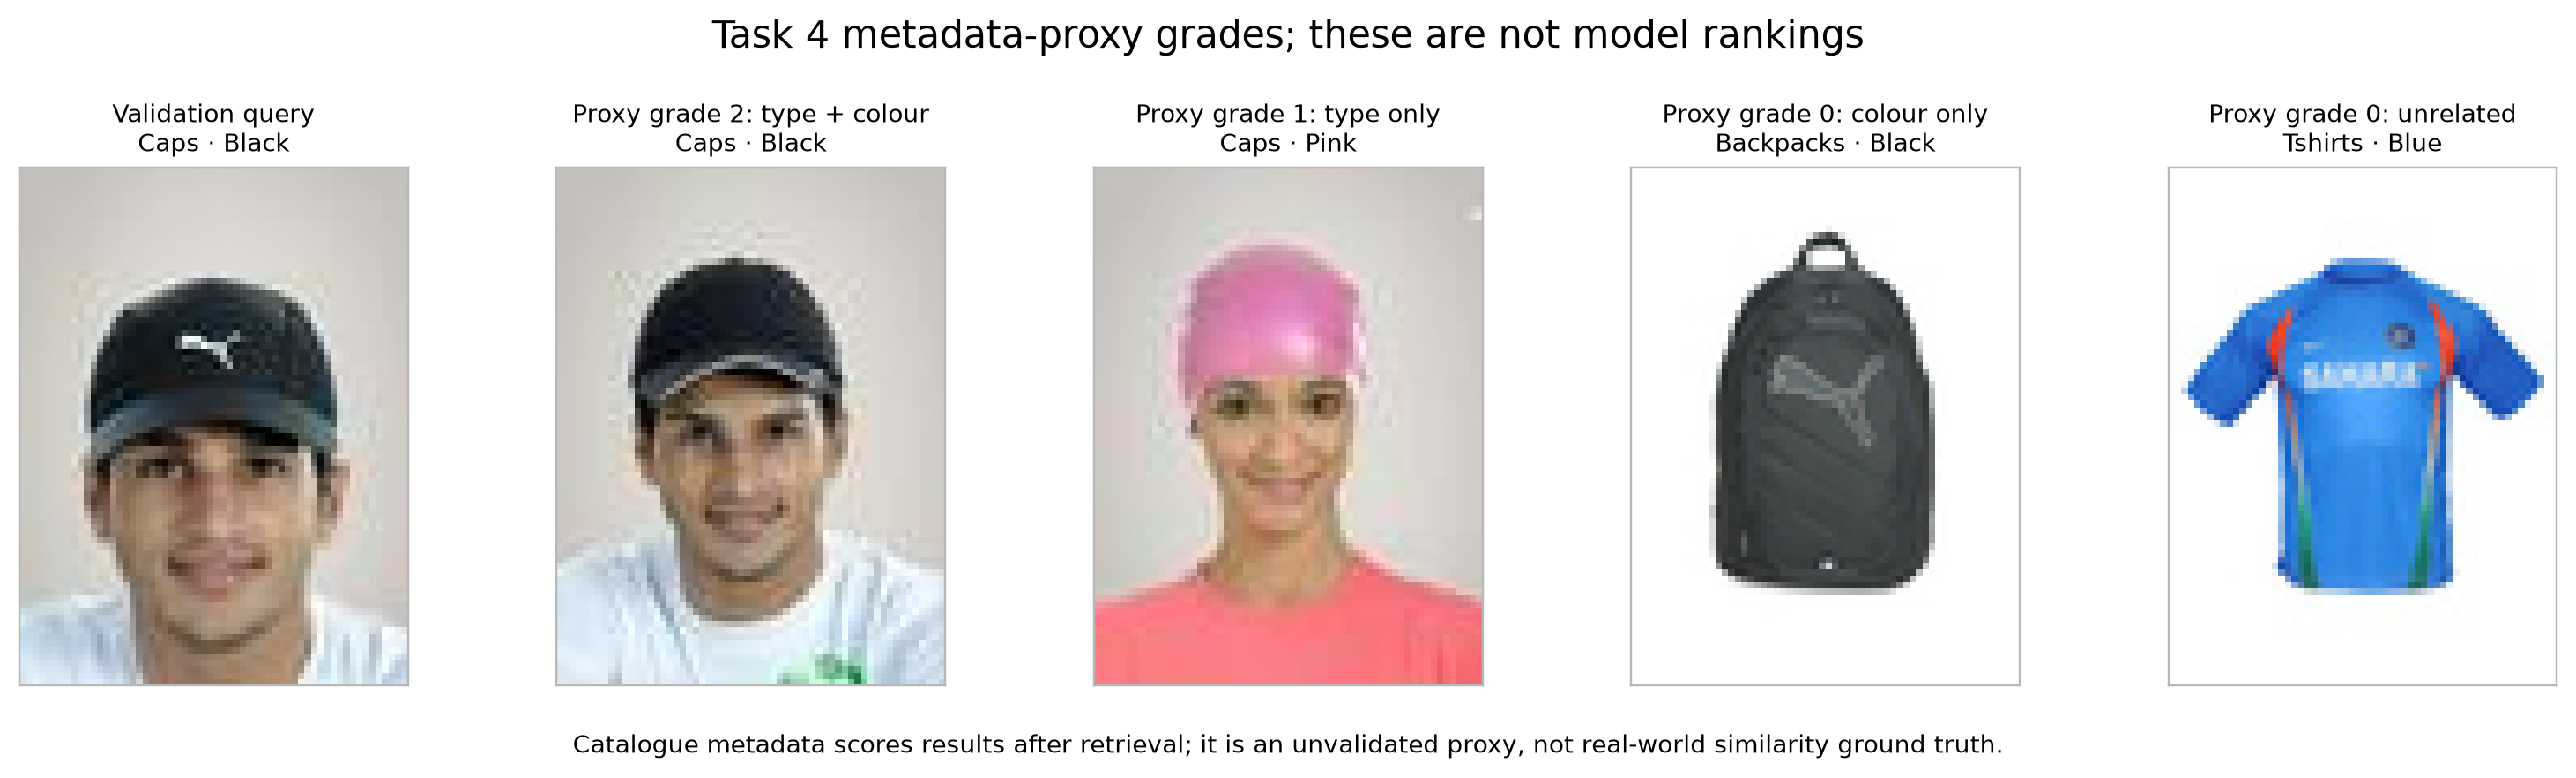

In [33]:
save_json(task4_record, "task4_protocol.json")
save_csv(task4_summary, "task4_summary.csv")
task4_figure = plot_task4(queries, gallery)
task4_reader_rows = {
    "total validation products",
    "relevance evidence kind",
    "unresolved proxy validation",
    "eligible supported query products",
    "excluded unsupported query products",
    "query image inputs",
    "gallery product IDs",
    "gallery image inputs",
    "shared IDs / SHA / families",
    "zero grade-2 positives",
    "fewer than five grade-2 positives",
    "zero-positive rule",
    "Top-K identity",
}
show_table(
    task4_summary[task4_summary["contract"].isin(task4_reader_rows)],
    "Task 4 evaluation contract and coverage limits",
)
show_figure(
    task4_figure,
    (
        "Figure 17. One validation query is compared with train-only metadata-proxy "
        "grade examples. These are not model rankings. Both image variants collapse to "
        "one product ID."
    ),
)

> **Finding.** The development protocol processes 11,536 validation-query image inputs representing
> 5,768 supported products and 53,984 train-gallery image inputs representing 26,992 products. The two
> sides have zero shared IDs, hashes, or families. Thirteen validation products fall outside the
> train-supported article-type slice and are reported separately. Coverage limits Recall@5: 110
> product queries have no grade-2 gallery positive and 412 have fewer than five. Figure 17 illustrates
> a catalogue-metadata proxy only; it is not a model ranking or real-world similarity ground truth.
>
> **Modelling consequence.** Both image inputs are encoded, but the two variant scores collapse to one
> product ID before Top-K ranking. Evaluation reports nDCG@5, grade-2 Recall@5, coverage, and latency
> over products, while compute and storage reporting uses the full doubled image-input count.

## 8. Reproducibility and limitations

The final evidence check distinguishes stable artefacts from machine-dependent measurements and
records the unresolved limits that later experiments must preserve or close.

**Code step — Modelling decision table.**

Converts the EDA findings into fixed modelling choices and later checks, then saves the decision table.

In [34]:
decision_table = pd.DataFrame(
    [
        {
            "area": "split",
            "decision": "use data/processed/splits.csv only",
            "evidence": (
                f"{int(partition_input_counts.loc['train', 'image_inputs']):,} train and "
                f"{int(partition_input_counts.loc['val', 'image_inputs']):,} validation inputs; "
                "zero crossings"
            ),
            "later_check": "never make another split",
        },
        {
            "area": "protected labels",
            "decision": "seal holdout and quarantine",
            "evidence": "shared loader returns blank protected targets",
            "later_check": "unlock only once for final evaluation",
        },
        {
            "area": "official outputs",
            "decision": "train the frozen train-observed output vocabulary",
            "evidence": "train-fitted taxonomy and label maps; no holdout influence",
            "later_check": "keep fixed prediction schema and literal NA",
        },
        {
            "area": "primary comparison",
            "decision": "rank on supported classes",
            "evidence": "at least three independent train families",
            "later_check": "also report rare official outputs",
        },
        {
            "area": "image input",
            "decision": "RGB, 96x128, aspect preserving",
            "evidence": "zero common padding and 25% fewer tensor pixels",
            "later_check": "use paired train-only mean/std by default",
        },
        {
            "area": "image variants",
            "decision": "use low and high resolution for every model product",
            "evidence": (
                f"{int(variant_proof['model_variant_count']):,} image inputs from "
                f"{int(variant_proof['model_product_count']):,} products"
            ),
            "later_check": "pair-weight training; aggregate evaluation pairs to one score",
        },
        {
            "area": "Task 1",
            "decision": "task owner selects class-aware metrics and imbalance comparison",
            "evidence": "strong articleType long tail",
            "later_check": "record the chosen metrics, baseline, option, and rare-class trade-offs",
        },
        {
            "area": "Tasks 2 and 3",
            "decision": "separate targets with bias slices",
            "evidence": "mixed season signal and catalogue shortcuts",
            "later_check": "do not treat gender as identity",
        },
        {
            "area": "Task 4",
            "decision": "metadata-proxy relevance; validation queries, train-only gallery",
            "evidence": "zero ID/SHA/family overlap; not similarity ground truth",
            "later_check": "validate proxy later; report nDCG, Recall, coverage, latency",
        },
        {
            "area": "family uncertainty",
            "decision": "report product rows and independent family units",
            "evidence": "27,009 families from 38,551 active product rows",
            "later_check": "slice classes with fewer than three validation families",
        },
    ]
)
_ = save_csv(decision_table, "decision_table.csv")

**Code step — Evidence and input provenance.**

Lists every stable output and permitted input fingerprint and records the current Git state for reproducibility.

In [35]:
stable_evidence_names = [
    "bias_summary.csv",
    "decision_table.csv",
    "duplicate_summary.csv",
    "family_basis_summary.csv",
    "family_policy_summary.csv",
    "family_size_distribution.csv",
    "hierarchy_summary.csv",
    "high_resolution_summary.csv",
    "image_quality_spearman.csv",
    "image_summary.csv",
    "imbalance_handoff.csv",
    "joint_target_nmi.csv",
    "label_image_sanity.csv",
    "normalization_summary.csv",
    "partition_summary.csv",
    "preparation_stage_order.csv",
    "raw_hashing_summary.csv",
    "image_reconciliation.csv",
    "processed_inventory.csv",
    "raw_inventory.csv",
    "season_family_basis_summary.csv",
    "support_threshold_sensitivity.csv",
    "target_summary.csv",
    "task4_protocol.json",
    "task4_summary.csv",
    "taxonomy_exclusions.csv",
    "taxonomy_summary.csv",
    "train_image_quality_sample.csv",
    "train_image_quality_summary.csv",
    "validation_family_coverage.csv",
    "validation_summary.csv",
    "variant_alignment_summary.csv",
]
figure_names = [
    "article_type_long_tail.png",
    "bias_risk.png",
    "data_quality_examples.png",
    "development_balance.png",
    "hierarchy_overlap.png",
    "image_profile.png",
    "image_quality_correlation.png",
    "joint_target_relationships.png",
    "label_image_sanity.png",
    "near_duplicate_boundary.png",
    "family_policy.png",
    "season_ambiguity.png",
    "target_distributions.png",
    "task4_protocol.png",
    "train_image_quality.png",
    "transform_comparison.png",
    "variant_alignment_examples.png",
]
deterministic_outputs = sorted(
    [
        *(FIGURES / name for name in figure_names),
        *(EVIDENCE / name for name in stable_evidence_names),
    ],
    key=lambda path: path.relative_to(PROJECT_ROOT).as_posix(),
)

input_records = [
    {
        "path": "data/raw/teacher/train/styles_train.csv",
        "read_scope": "header and ID only",
        "rows": len(raw_train_ids),
        "sha256": compute_sha256(RAW_TRAIN_CSV),
    },
    {
        "path": "data/raw/teacher/test/styles_prediction.csv",
        "read_scope": "fixed header and ID only",
        "rows": len(raw_prediction_ids),
        "sha256": compute_sha256(RAW_PREDICTION_CSV),
    },
    *[
        {
            "path": row.file,
            "read_scope": row.digest_scope,
            "rows": row.rows,
            "sha256": row.sha256,
        }
        for row in processed_inventory.itertuples(index=False)
    ],
]

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=PROJECT_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
    git_dirty = bool(
        subprocess.run(
            ["git", "status", "--porcelain"],
            cwd=PROJECT_ROOT,
            check=True,
            capture_output=True,
            text=True,
        ).stdout.strip()
    )
except (FileNotFoundError, subprocess.CalledProcessError):
    git_commit = "unavailable"
    git_dirty = None

**Code step — Portable EDA summary.**

Assembles the machine-readable EDA summary containing scope, leakage checks, image policy, evaluation rules, decisions, and open limits.

In [36]:
summary = {
    "schema_version": "12.0.0",
    "execution": {
        "preparation_mode": PREPARATION_MODE,
        "preparation_seconds": round(preparation_seconds, 3),
        "cache_validation": cache_validation,
        "default_mode": "cached",
        "full_mode_environment": "FASHION_DATA_PREPARATION_MODE=full",
    },
    "scope": {
        "modelling_partition": "train",
        "development_partition": "val",
        "protected_partitions": ["holdout", "quarantine"],
        "prediction_images_in_target_analysis": 0,
        "prediction_role": "label-free duplicate audit only",
        "raw_teacher_target_columns_read_by_data_preparation": 0,
    },
    "inventory": {
        "raw_train_rows": len(raw_train_ids),
        "official_prediction_rows": len(raw_prediction_ids),
        "image_backed_labelled_product_ids": len(splits),
        "train_product_ids": int(partition_input_counts.loc["train", "product_ids"]),
        "train_image_inputs": int(partition_input_counts.loc["train", "image_inputs"]),
        "validation_product_ids": int(partition_input_counts.loc["val", "product_ids"]),
        "validation_image_inputs": int(partition_input_counts.loc["val", "image_inputs"]),
        "holdout_product_ids": int(partition_input_counts.loc["holdout", "product_ids"]),
        "holdout_image_inputs": int(partition_input_counts.loc["holdout", "image_inputs"]),
        "quarantine_product_ids": int(partition_input_counts.loc["quarantine", "product_ids"]),
        "quarantine_image_inputs": int(partition_input_counts.loc["quarantine", "image_inputs"]),
        "target_distribution_unit": "unique product ID",
        "model_loader_unit": "image input row",
        "evaluation_metric_unit": "product ID after two-variant aggregation",
        "original_train_image_inventory_digest": image_summary.iloc[0]["ordered_inventory_sha256"],
    },
    "raw_hashing": raw_hashing_summary.to_dict("records"),
    "image_reconciliation": image_reconciliation.to_dict("records"),
    "preparation_stage_order": pipeline_stage_order.to_dict("records"),
    "label_image_sanity": {
        "source_partition": "train",
        "sample_products": len(label_image_sanity),
        "target_fields": list(TARGET_COLUMNS),
        "purpose": "visual sanity check only",
        "automatic_label_changes": 0,
    },
    "imbalance_handoff": {
        "source_partition": "train",
        "unit": "unique product ID",
        "fixed_method": False,
        "task_owner_choice_required": True,
        "validation_holdout_rebalanced": False,
        "raw_pixel_smote": False,
        "records": imbalance_handoff.to_dict("records"),
    },
    "image_variants": variant_record,
    "train_image_quality": {
        "source_partition": "train",
        "sample_products": len(train_quality_sample),
        "sample_method": "evenly spaced product IDs after sorting",
        "summary": train_quality_summary.to_dict("records"),
    },
    "image_feature_correlation": {
        "source_partition": "train",
        "method": "spearman",
        "sample_products": len(train_quality_sample),
        "features": quality_feature_columns,
        "strongest_pair": strongest_image_quality_pair,
        "causal_claim": False,
    },
    "normalization": {
        "default_policy": paired_normalization["policy"],
        "paired_sha256": compute_sha256(PAIRED_NORMALIZATION_PATH),
        "original_only_baseline_sha256": compute_sha256(ORIGINAL_ONLY_NORMALIZATION_PATH),
        "train_ids_digest": paired_normalization["train_ids_digest"],
    },
    "leakage_checks": {
        **crossing_checks,
        "accepted_visual_edges_crossing_active_partitions": len(visual_crossings),
        "protected_target_fields_visible": 0,
        "raw_teacher_target_columns_read_by_data_preparation": 0,
        "prediction_ids_in_labelled_splits": 0,
        "prediction_ids_in_variant_manifest": variant_proof["official_prediction_id_intersection"],
        "quarantine_ids_in_variant_manifest": variant_proof["quarantine_id_intersection"],
    },
    "family_policy": {
        "summary": family_policy_summary.to_dict("records"),
        "block_basis": family_basis_summary.to_dict("records"),
        "family_size_distribution": family_size_distribution.to_dict("records"),
        "support_threshold_sensitivity": (
            support_threshold_sensitivity.to_dict("records")
        ),
        "open_decisions_file": "docs/reviews/open_decisions.md",
        "open_decisions_block_execution": False,
    },
    "taxonomy": taxonomy_summary.to_dict("records"),
    "validation": validation_summary.to_dict("records"),
    "validation_family_coverage": validation_family_coverage.to_dict("records"),
    "transform_decision": {
        "shape_height_width": list(IMAGE_SIZE),
        "common_source_padding_percent": 0.0,
        "pixel_reduction_vs_old_percent": 25.0,
        "wall_time_is_volatile": True,
        "downstream_macro_f1": "not available",
    },
    "task4": task4_record,
    "decisions": decision_table.to_dict("records"),
    "limitations": [
        "The visual duplicate rule favours precision and does not prove recall.",
        "Normalized names can group different designs and reduce effective sample size.",
        "Tiny original images can hide fine product details.",
        "Season, gender, and usage are catalogue labels, not always visible facts.",
        "Task 4 grades are a metadata proxy, not human visual-similarity ground truth.",
        "Perceptual same-ID alignment is strong automatic evidence, not human proof.",
        (
            "Doubled inputs add storage and decoding cost; the planned three-way "
            "ablation is not run yet."
        ),
        "Queries with no grade-2 positives are excluded from mean Recall@5 and reported.",
        "No registered model run yet compares transform choices under a task-owned metric.",
        (
            "Cached mode checks every image path and size but content-hashes only a fixed "
            "sample; use full mode after any deliberate raw-image replacement."
        ),
        "Full forensic mode is I/O-bound and is not the normal reader path.",
    ],
    "deterministic_outputs": [file_record(path) for path in deterministic_outputs],
}
_ = save_json(summary, "summary.json")

**Code step — Provenance record.**

Writes runtime and file-level provenance, separates stable outputs from volatile timings, and displays the saved provenance boundary.

In [37]:
provenance = {
    "git": {"commit": git_commit, "dirty": git_dirty},
    "notebook": {
        "path": NOTEBOOK_PATH.relative_to(PROJECT_ROOT).as_posix(),
        "code_digest": notebook_code_digest(NOTEBOOK_PATH),
    },
    "runtime": {
        "python": platform.python_version(),
        "implementation": platform.python_implementation(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": matplotlib.__version__,
        "pillow": Image.__version__,
    },
    "inputs": input_records,
    "execution": summary["execution"],
    "image_variants": variant_record,
    "deterministic_outputs": [file_record(path) for path in deterministic_outputs],
    "volatile_outputs": [
        file_record(EVIDENCE / "transform_benchmark.json"),
        file_record(EVIDENCE / "transform_summary.csv"),
    ],
    "note": (
        "Wall-time benchmark hashes may change; report figures and other evidence are "
        "deterministic for the locked runtime."
    ),
}
save_json(provenance, "provenance.json")
provenance_summary = pd.DataFrame(
    [
        {
            "stable_output_files": len(deterministic_outputs),
            "report_figures": len(figure_names),
            "notebook_code_digest": provenance["notebook"]["code_digest"][:16] + "...",
            "wall_time_hash_stable": False,
        }
    ]
)
show_table(provenance_summary, "Saved portable provenance boundary")

,stable_output_files,report_figures,notebook_code_digest,wall_time_hash_stable
0,49,17,f7b447419fbc05cf...,False


> **Finding.** The notebook records 49 stable evidence files, including all 17 report figures,
> with project-relative paths and hashes. Raw target files are represented only by permitted ID-level
> fingerprints. Wall-time benchmarks remain outside the stable set because hardware and cache state
> change them.
>
> **Modelling consequence.** Later notebooks reuse the same split, taxonomy, normalization,
> image-variant manifest, and run registry. A deliberate raw-data replacement requires full mode
> before new results are compared with the saved evidence.

## 9. Modelling recommendations

The decision table converts EDA evidence into an experiment contract. Each row states the chosen
policy, its supporting evidence, and the result that later model work must still establish.

**Code step — Final report output.**

Displays the modelling decision table, open limitations, and the successful Run All completion record.

In [38]:
train_input_count = int(partition_input_counts.loc["train", "image_inputs"])
validation_input_count = int(partition_input_counts.loc["val", "image_inputs"])
holdout_input_count = int(partition_input_counts.loc["holdout", "image_inputs"])
train_product_count = int(partition_input_counts.loc["train", "product_ids"])
validation_product_count = int(partition_input_counts.loc["val", "product_ids"])
holdout_product_count = int(partition_input_counts.loc["holdout", "product_ids"])

show_table(decision_table, "Data-preparation decision table for all later modelling")
display(
    HTML(
        "<p><strong>Open limits:</strong> " + html.escape(" ".join(summary["limitations"])) + "</p>"
    )
)
display(
    HTML(
        f"<p><strong>Run All complete in {PREPARATION_MODE} mode.</strong> "
        f"Prepared data in {preparation_seconds:.1f} seconds and saved "
        f"{len(figure_names)} figures. Actual paired inputs: {train_input_count:,} train, "
        f"{validation_input_count:,} validation, and {holdout_input_count:,} holdout images. "
        f"These represent {train_product_count:,}, {validation_product_count:,}, and "
        f"{holdout_product_count:,} product-level reporting units. "
        "Protected target values materialised by data preparation: 0.</p>"
    )
)

,area,decision,evidence,later_check
0,split,use data/processed/splits.csv only,"53,984 train and 11,562 validation inputs; zero crossings",never make another split
1,protected labels,seal holdout and quarantine,shared loader returns blank protected targets,unlock only once for final evaluation
2,official outputs,train the frozen train-observed output vocabulary,train-fitted taxonomy and label maps; no holdout influence,keep fixed prediction schema and literal NA
3,primary comparison,rank on supported classes,at least three independent train families,also report rare official outputs
4,image input,"RGB, 96x128, aspect preserving",zero common padding and 25% fewer tensor pixels,use paired train-only mean/std by default
5,image variants,use low and high resolution for every model product,"77,102 image inputs from 38,551 products",pair-weight training; aggregate evaluation pairs to one score
6,Task 1,task owner selects class-aware metrics and imbalance comparison,strong articleType long tail,"record the chosen metrics, baseline, option, and rare-class trade-offs"
7,Tasks 2 and 3,separate targets with bias slices,mixed season signal and catalogue shortcuts,do not treat gender as identity
8,Task 4,"metadata-proxy relevance; validation queries, train-only gallery",zero ID/SHA/family overlap; not similarity ground truth,"validate proxy later; report nDCG, Recall, coverage, latency"
9,family uncertainty,report product rows and independent family units,"27,009 families from 38,551 active product rows",slice classes with fewer than three validation families


## 10. Final assessment

The dataset is ready for controlled model development, but it is not ready for a final performance
claim. The split is safe, difficult classes and shortcut risks are documented, and the image and
retrieval contracts are fixed. The next work follows this order:

1. Train the same from-scratch baseline with original-only, high-only, and paired images under one
   seed, budget, split, and metric suite.
2. For `articleType` and `usage`, compare an unmodified baseline with at least one evidence-chosen train-side option and
   explain rare-class gains and losses.
3. Compare separate prediction models with a shared-representation alternative while retaining one
   score and failure analysis for each official target.
4. For Task 4, compare a simple retrieval baseline with a learned embedding using the fixed
   validation-query and train-gallery protocol.
5. Freeze the final choices, then unlock the holdout exactly once for independent evaluation.

The final assignment report should cite data-preparation figures only when they justify a modelling choice. It
should not repeat every diagnostic plot.